In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ankitgaidhar/indian-pines-hyperspectral-dataset/10_4231_R7RX991C/README.txt
/kaggle/input/datasets/ankitgaidhar/indian-pines-hyperspectral-dataset/10_4231_R7RX991C/gallery/19920612_AVIRIS_IndianPine_Site3_ch50-27-17-23028.png
/kaggle/input/datasets/ankitgaidhar/indian-pines-hyperspectral-dataset/10_4231_R7RX991C/gallery/19920612_AVIRIS_IndianPine_Site3_gr-23030.png
/kaggle/input/datasets/ankitgaidhar/indian-pines-hyperspectral-dataset/10_4231_R7RX991C/gallery/19920612_AVIRIS_IndianPine_Site3_selection_graph-23029.png
/kaggle/input/datasets/ankitgaidhar/indian-pines-hyperspectral-dataset/10_4231_R7RX991C/bundle/aviris_hyperspectral_data/19920612_AVIRIS_IndianPine_NS-line.tif
/kaggle/input/datasets/ankitgaidhar/indian-pines-hyperspectral-dataset/10_4231_R7RX991C/bundle/aviris_hyperspectral_data/19920612_AVIRIS_IndianPine_EW-line_R.tif
/kaggle/input/datasets/ankitgaidhar/indian-pines-hyperspectral-dataset/10_4231_R7RX991C/bundle/aviris_hyperspectral_data/19920612_AV

<h1 style="
    text-align:center;
    font-size:38px;
    font-weight:bold;
    background: linear-gradient(90deg, #1B5E20, #66BB6A);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom:10px;
">
    🌿 Hyperspectral Image Classification
</h1>

<p style="
    text-align:center;
    font-size:16px;
    color:#555;
">
    Indian Pines Dataset • Remote Sensing • Spectral Analysis
</p>

<div style="
    background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
    padding:22px;
    border-radius:14px;
    border:1px solid rgba(255,255,255,0.08);
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 8px 20px rgba(0,0,0,0.4);
    color:#E0F2F1;
">

<h2 style="
    color:#A5D6A7;
    margin-top:0;
    letter-spacing:0.5px;
">
🌿 Hyperspectral Pipeline Summary
</h2>

<p style="font-size:15px; color:#CFD8DC;">
This block builds a complete <b>end-to-end preprocessing and visualization pipeline</b> 
for the <span style="color:#81C784;">Indian Pines hyperspectral dataset</span>, preparing it for deep learning.
</p>

<hr style="border:0.5px solid rgba(255,255,255,0.1);">

<ul style="line-height:1.7; font-size:14px;">

<li>⚙️ <b style="color:#80CBC4;">Environment Setup</b><br>
<span style="color:#B0BEC5;">Imports core ML, visualization, and PyTorch libraries with reproducibility controls.</span>
</li>

<br>

<li>📦 <b style="color:#80CBC4;">Data Loading</b><br>
<span style="color:#B0BEC5;">Loads hyperspectral cube and ground-truth labels using <code>rasterio</code>.</span>
</li>

<br>

<li>📐 <b style="color:#80CBC4;">Preprocessing</b><br>
<span style="color:#B0BEC5;">Aligns spatial dimensions and reshapes data into model-friendly format.</span>
</li>

<br>

<li>🔢 <b style="color:#80CBC4;">Label Encoding</b><br>
<span style="color:#B0BEC5;">Transforms raw labels into compact 0-based indices for training.</span>
</li>

<br>

<li>🌈 <b style="color:#80CBC4;">Class Metadata</b><br>
<span style="color:#B0BEC5;">Generates class names and color palettes dynamically.</span>
</li>

<br>

<li>📊 <b style="color:#80CBC4;">Exploratory Analysis</b><br>
<span style="color:#B0BEC5;">
• False-color composite<br>
• Ground-truth map<br>
• Class distribution<br>
• Spectral signatures<br>
• Band correlation heatmap<br>
• Spectral variance analysis
</span>
</li>

</ul>

<div style="
    margin-top:18px;
    padding:12px;
    border-radius:10px;
    background: rgba(255,255,255,0.05);
    border-left:4px solid #66BB6A;
    font-size:13px;
    color:#C8E6C9;
">
💡 <b>Insight:</b> This stage ensures high-quality data understanding, which is critical for achieving strong model performance in hyperspectral classification.
</div>

</div>

Using device: cuda
Data : /kaggle/input/datasets/ankitgaidhar/indian-pines-hyperspectral-dataset/10_4231_R7RX991C/bundle/aviris_hyperspectral_data/19920612_AVIRIS_IndianPine_Site3.tif
Label: /kaggle/input/datasets/ankitgaidhar/indian-pines-hyperspectral-dataset/10_4231_R7RX991C/documentation/Site3_Project_and_Ground_Reference_Files/Site3_Project_and_Ground_Reference_Files/19920612_AVIRIS_IndianPine_Site3_gr.tif

Raw cube  - bands=220  H=145  W=145
dtype=uint16   CRS=None
Label map - shape=(145, 145)  unique vals=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]

Hyperspectral cube : 145 x 145 pixels x 220 bands
Classes found      : 16  labels=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Data range         : [955.0, 9604.0]


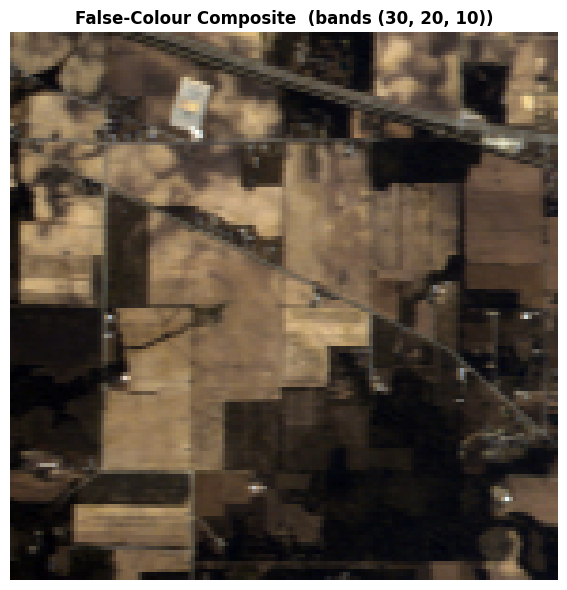

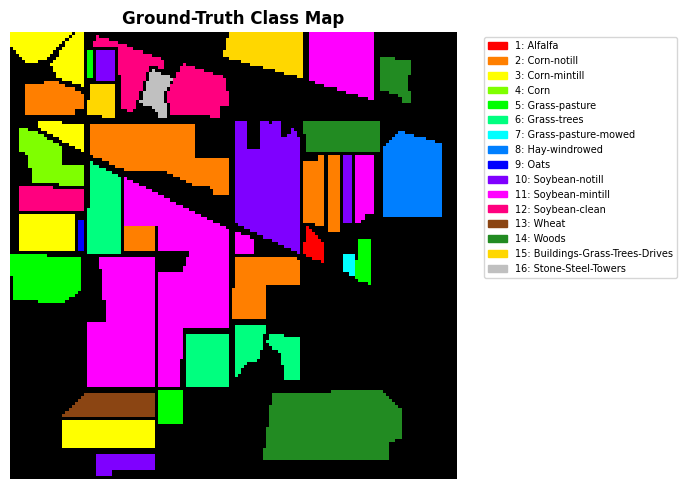

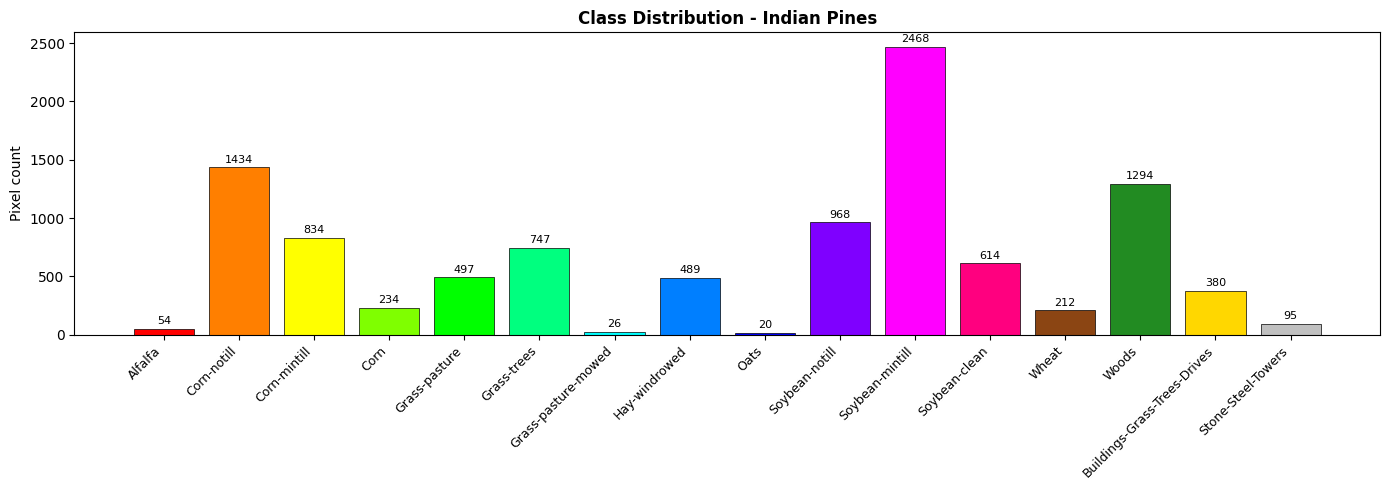

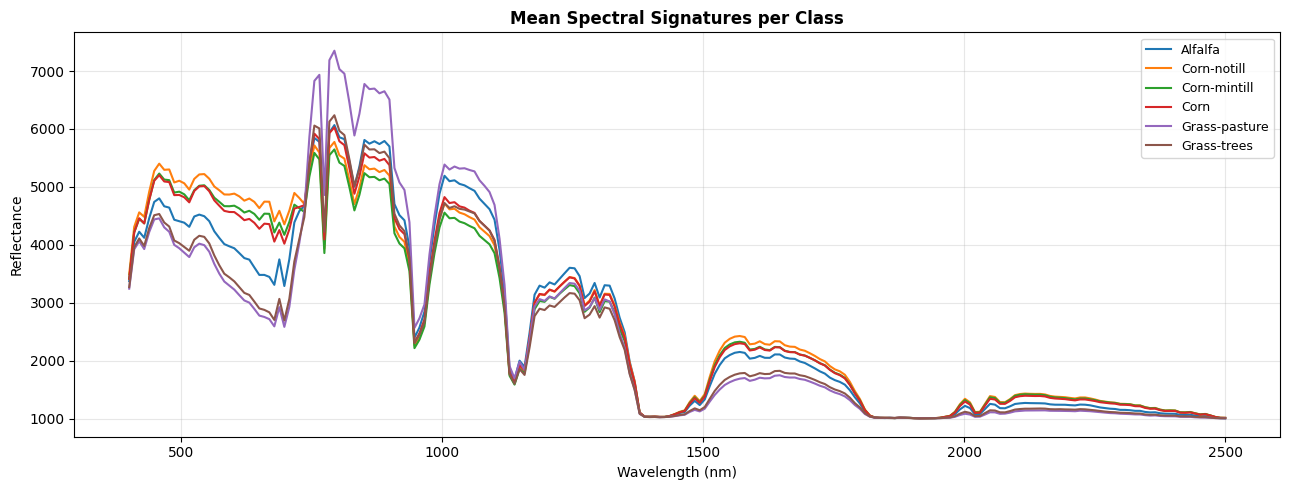

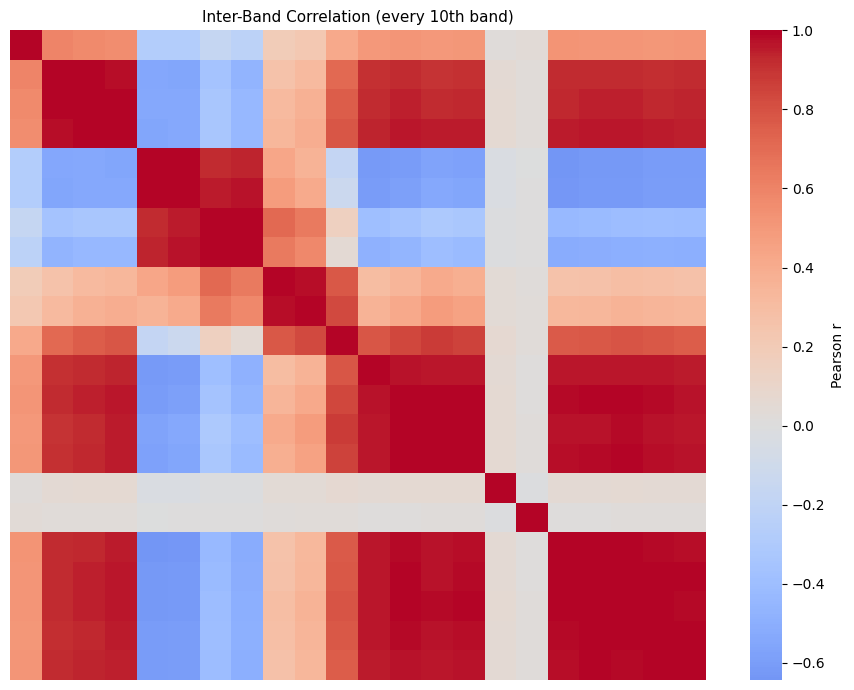

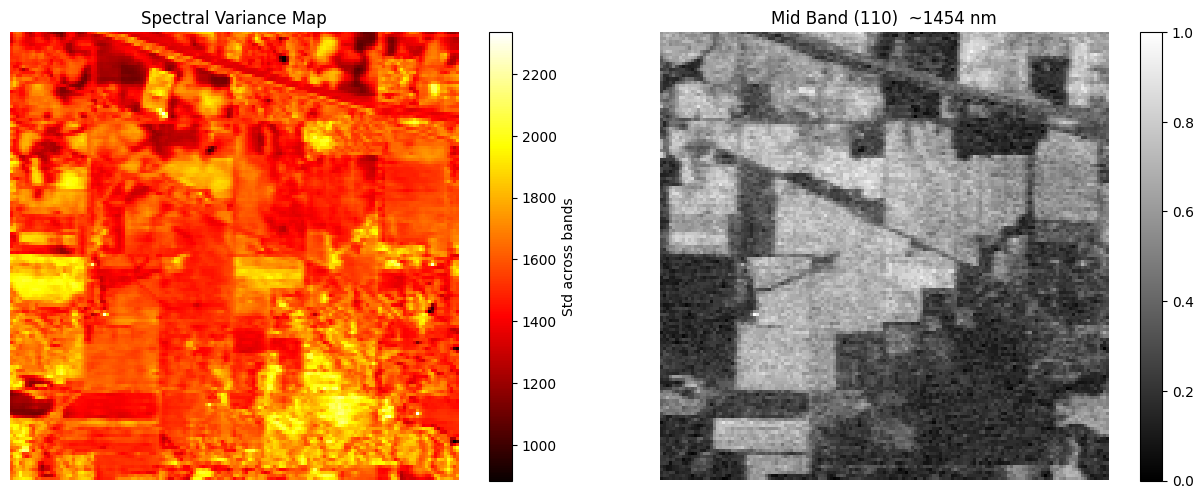

In [2]:
# ── CELL 1: Imports ───────────────────────────────────────────────────────────
import os, subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)
import warnings
warnings.filterwarnings("ignore")
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
 
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
 
# ==============================================================================
# BLOCK 1 – DATA LOADING & EXTRACTION
# ==============================================================================
 
# ── CELL 2: Install rasterio (not pre-installed on Kaggle) ────────────────────
subprocess.run(["pip", "install", "rasterio", "-q"], check=True)
import rasterio
 
# ── CELL 3: Exact file paths (confirmed from directory listing) ───────────────
BASE = ("/kaggle/input/datasets/ankitgaidhar"
        "/indian-pines-hyperspectral-dataset/10_4231_R7RX991C")
 
DATA_TIF  = (f"{BASE}/bundle/aviris_hyperspectral_data"
             f"/19920612_AVIRIS_IndianPine_Site3.tif")
 
LABEL_TIF = (f"{BASE}/documentation"
             f"/Site3_Project_and_Ground_Reference_Files"
             f"/Site3_Project_and_Ground_Reference_Files"
             f"/19920612_AVIRIS_IndianPine_Site3_gr.tif")
 
print("Data :", DATA_TIF)
print("Label:", LABEL_TIF)
 
# ── CELL 4: Load hyperspectral cube ───────────────────────────────────────────
# rasterio reads as (Bands, H, W) -> transpose to (H, W, B)
with rasterio.open(DATA_TIF) as src:
    data_raw = src.read().astype(np.float32)          # (B, H, W)
    print(f"\nRaw cube  - bands={src.count}  H={src.height}  W={src.width}")
    print(f"dtype={src.dtypes[0]}   CRS={src.crs}")
 
data = data_raw.transpose(1, 2, 0)                    # (H, W, B)
 
# ── CELL 5: Load ground-truth label map ──────────────────────────────────────
with rasterio.open(LABEL_TIF) as src:
    labels_raw = src.read(1).astype(np.int64)         # (H, W)
    print(f"Label map - shape={labels_raw.shape}  unique vals={np.unique(labels_raw)}")
 
# ── CELL 6: Align spatial extents ─────────────────────────────────────────────
H_d, W_d, B = data.shape
H_l, W_l     = labels_raw.shape
H = min(H_d, H_l);  W = min(W_d, W_l)
data         = data[:H, :W, :]
labels_raw   = labels_raw[:H, :W]
 
# ── CELL 7: Remap palette indices to compact 0-based class IDs ────────────────
unique_vals  = np.unique(labels_raw)
lmap         = np.zeros(int(unique_vals.max()) + 1, dtype=np.int64)
counter      = 0
for v in sorted(unique_vals):
    lmap[v]  = counter
    counter += 1
 
labels      = lmap[labels_raw]
NUM_CLASSES = int(labels.max())
 
print(f"\nHyperspectral cube : {H} x {W} pixels x {B} bands")
print(f"Classes found      : {NUM_CLASSES}  labels={np.unique(labels)}")
print(f"Data range         : [{data.min():.1f}, {data.max():.1f}]")
 
# Wavelength axis - AVIRIS 220-band sensor approx 400-2500 nm
wavelengths = np.linspace(400, 2500, B)
 
# ── CELL 8: Build CLASS_NAMES and CLASS_COLORS for actual class count ──────────
_BASE_NAMES = [
    'Background','Alfalfa','Corn-notill','Corn-mintill','Corn',
    'Grass-pasture','Grass-trees','Grass-pasture-mowed','Hay-windrowed',
    'Oats','Soybean-notill','Soybean-mintill','Soybean-clean','Wheat',
    'Woods','Buildings-Grass-Trees-Drives','Stone-Steel-Towers'
]
_BASE_COLORS = [
    '#000000','#FF0000','#FF7F00','#FFFF00','#7FFF00',
    '#00FF00','#00FF7F','#00FFFF','#007FFF','#0000FF',
    '#7F00FF','#FF00FF','#FF007F','#8B4513','#228B22',
    '#FFD700','#C0C0C0'
]
while len(_BASE_NAMES)  <= NUM_CLASSES: _BASE_NAMES.append(f'Class-{len(_BASE_NAMES)}')
while len(_BASE_COLORS) <= NUM_CLASSES: _BASE_COLORS.append('#AAAAAA')
 
CLASS_NAMES  = {i: _BASE_NAMES[i]  for i in range(NUM_CLASSES + 1)}
CLASS_COLORS = _BASE_COLORS[:NUM_CLASSES + 1]
 
# ==============================================================================
# BLOCK 2 – EXPLORATORY VISUALISATION
# ==============================================================================
 
def normalise(img):
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn + 1e-8)
 
# ── CELL 9: False-colour composite ───────────────────────────────────────────
def plot_false_color(data):
    b = data.shape[2]
    bands = (min(30, b-1), min(20, b-1), min(10, b-1))
    rgb = np.dstack([normalise(data[:, :, bnd]) for bnd in bands])
    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.title(f"False-Colour Composite  (bands {bands})", fontsize=12, fontweight="bold")
    plt.axis("off"); plt.tight_layout(); plt.show()
 
plot_false_color(data)
 
# ── CELL 10: Ground-truth class map ──────────────────────────────────────────
def plot_ground_truth(labels, class_names, class_colors):
    from matplotlib.colors import ListedColormap
    n    = len(class_colors)
    cmap = ListedColormap(class_colors)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(labels, cmap=cmap, vmin=0, vmax=n - 1)
    patches = [mpatches.Patch(color=class_colors[i],
                               label=f"{i}: {class_names.get(i, i)}")
               for i in range(1, n)]
    ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc="upper left",
              fontsize=7, framealpha=0.8)
    ax.set_title("Ground-Truth Class Map", fontsize=12, fontweight="bold")
    ax.axis("off"); plt.tight_layout(); plt.show()
 
plot_ground_truth(labels, CLASS_NAMES, CLASS_COLORS)
 
# ── CELL 11: Class-distribution bar chart ─────────────────────────────────────
def plot_class_distribution(labels, class_names, class_colors):
    unique, counts = np.unique(labels, return_counts=True)
    mask = unique != 0
    unique, counts = unique[mask], counts[mask]
    names  = [class_names.get(i, str(i)) for i in unique]
    colors = [class_colors[i] if i < len(class_colors) else '#AAAAAA' for i in unique]
    plt.figure(figsize=(14, 5))
    bars = plt.bar(names, counts, color=colors, edgecolor="black", linewidth=0.5)
    for bar, cnt in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(cnt), ha="center", va="bottom", fontsize=8)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.ylabel("Pixel count")
    plt.title("Class Distribution - Indian Pines", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()
 
plot_class_distribution(labels, CLASS_NAMES, CLASS_COLORS)
 
# ── CELL 12: Mean spectral signatures ────────────────────────────────────────
def plot_spectral_signatures(data, labels, wavelengths, class_names):
    present = [c for c in range(1, labels.max()+1) if (labels == c).any()]
    sel = present[:min(6, len(present))]
    plt.figure(figsize=(13, 5))
    for cid in sel:
        mask = labels == cid
        plt.plot(wavelengths, data[mask].mean(axis=0),
                 label=class_names.get(cid, str(cid)), linewidth=1.5)
    plt.xlabel("Wavelength (nm)"); plt.ylabel("Reflectance")
    plt.title("Mean Spectral Signatures per Class", fontsize=12, fontweight="bold")
    plt.legend(fontsize=9); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
 
plot_spectral_signatures(data, labels, wavelengths, CLASS_NAMES)
 
# ── CELL 13: Inter-band correlation heatmap ──────────────────────────────────
def plot_band_correlation(data, n_sample=2000, step=10):
    flat = data.reshape(-1, data.shape[2])
    idx  = np.random.choice(len(flat), min(n_sample, len(flat)), replace=False)
    corr = np.corrcoef(flat[idx, ::step].T)
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, cmap="coolwarm", center=0,
                xticklabels=False, yticklabels=False,
                cbar_kws={"label": "Pearson r"})
    plt.title(f"Inter-Band Correlation (every {step}th band)", fontsize=11)
    plt.tight_layout(); plt.show()
 
plot_band_correlation(data)
 
# ── CELL 14: Spectral variance map + mid-band image ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
spec_var = data.std(axis=2)
im = axes[0].imshow(spec_var, cmap="hot")
plt.colorbar(im, ax=axes[0], label="Std across bands")
axes[0].set_title("Spectral Variance Map"); axes[0].axis("off")
 
mid = data.shape[2] // 2
im2 = axes[1].imshow(normalise(data[:, :, mid]), cmap="gray")
plt.colorbar(im2, ax=axes[1])
axes[1].set_title(f"Mid Band ({mid})  ~{int(wavelengths[mid])} nm"); axes[1].axis("off")
plt.tight_layout(); plt.show()

<div style="
    background: rgba(15, 32, 39, 0.55);
    backdrop-filter: blur(14px);
    -webkit-backdrop-filter: blur(14px);
    padding:22px;
    border-radius:16px;
    border:1px solid rgba(255,255,255,0.12);
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 8px 30px rgba(0,0,0,0.5);
    color:#E0F7FA;
">

<h2 style="
    margin-top:0;
    color:#80DEEA;
    letter-spacing:0.5px;
">
🧪 Advanced Preprocessing & Feature Engineering
</h2>

<p style="color:#CFD8DC; font-size:15px;">
This block enhances the hyperspectral dataset by removing noise, normalizing features, 
reducing dimensional redundancy, and preparing spatial-spectral patches for deep learning.
</p>

<hr style="border:0.5px solid rgba(255,255,255,0.1);">

<ul style="line-height:1.7; font-size:14px;">

<li>💧 <b style="color:#4DD0E1;">Water Absorption Removal</b><br>
<span style="color:#B0BEC5;">
Eliminates noisy spectral bands (1350–1420nm, 1820–1940nm) to improve signal quality.
</span>
</li>

<br>

<li>📏 <b style="color:#4DD0E1;">Standardization</b><br>
<span style="color:#B0BEC5;">
Applies <code>StandardScaler</code> across all pixels to ensure zero mean and unit variance.
</span>
</li>

<br>

<li>🧠 <b style="color:#4DD0E1;">PCA Visualization</b><br>
<span style="color:#B0BEC5;">
Reduces dimensionality for visualization while preserving major variance components.
</span>
</li>

<br>

<li>🧩 <b style="color:#4DD0E1;">Patch Extraction</b><br>
<span style="color:#B0BEC5;">
Extracts spatial-spectral patches (e.g., 11×11×B) using mirror padding for CNN input.
</span>
</li>

<br>

<li>📊 <b style="color:#4DD0E1;">Dataset Splitting</b><br>
<span style="color:#B0BEC5;">
Performs stratified split into <b>Train / Validation / Test</b> sets to maintain class balance.
</span>
</li>

</ul>

<div style="
    margin-top:18px;
    padding:12px;
    border-radius:10px;
    background: rgba(255,255,255,0.06);
    border-left:4px solid #26C6DA;
    font-size:13px;
    color:#B2EBF2;
">
💡 <b>Insight:</b> Combining spectral cleaning + normalization + spatial patching is key to unlocking high performance in hyperspectral deep learning models.
</div>

</div>

Removed 19 water-absorption bands → 201 remain
Normalized cube: (145, 145, 201)  mean≈-0.0000  std≈1.0000
PCA 3 components explain 94.68% variance


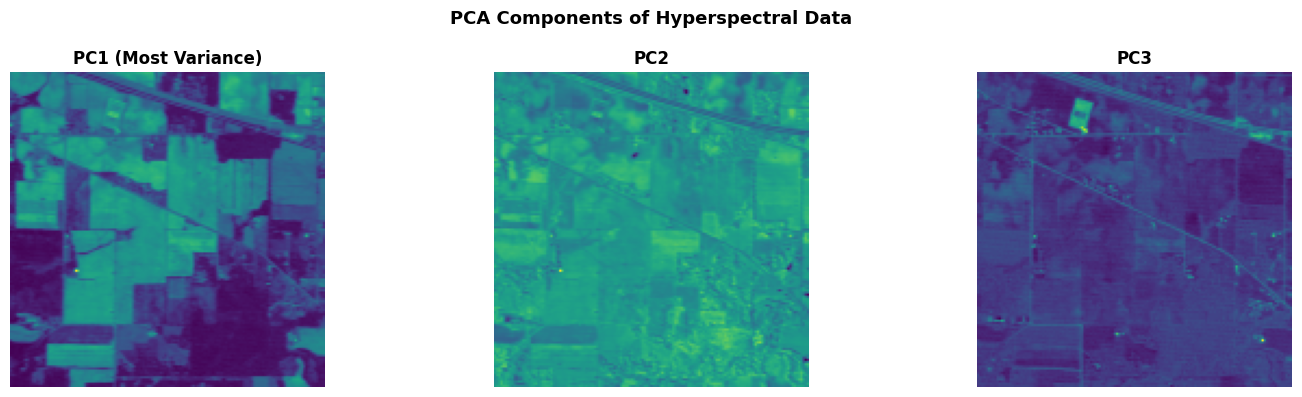

Extracted 10366 patches  shape=(10366, 11, 11, 201)  classes=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Train: 7256  Val: 1555  Test: 1555
Class balance (train): {np.int64(0): np.int64(38), np.int64(1): np.int64(1004), np.int64(2): np.int64(584), np.int64(3): np.int64(164), np.int64(4): np.int64(348), np.int64(5): np.int64(523), np.int64(6): np.int64(18), np.int64(7): np.int64(342), np.int64(8): np.int64(14), np.int64(9): np.int64(678), np.int64(10): np.int64(1727), np.int64(11): np.int64(430), np.int64(12): np.int64(148), np.int64(13): np.int64(906), np.int64(14): np.int64(266), np.int64(15): np.int64(66)}


In [3]:
# ── CELL 15: Band Selection & Normalization ───────────────────────────────────
from sklearn.preprocessing import StandardScaler

def remove_water_absorption_bands(data, wavelengths):
    """Remove water absorption bands (1350-1420nm, 1820-1940nm)"""
    bad_bands = ((wavelengths >= 1350) & (wavelengths <= 1420)) | \
                ((wavelengths >= 1820) & (wavelengths <= 1940))
    good_idx = np.where(~bad_bands)[0]
    print(f"Removed {bad_bands.sum()} water-absorption bands → {len(good_idx)} remain")
    return data[:, :, good_idx], wavelengths[good_idx], good_idx

data_clean, wavelengths_clean, good_idx = remove_water_absorption_bands(data, wavelengths)
B_clean = data_clean.shape[2]

# ── CELL 16: Global StandardScaler normalization ──────────────────────────────
H_, W_, B_ = data_clean.shape
flat = data_clean.reshape(-1, B_)
scaler = StandardScaler()
flat_norm = scaler.fit_transform(flat)
data_norm = flat_norm.reshape(H_, W_, B_).astype(np.float32)
print(f"Normalized cube: {data_norm.shape}  mean≈{data_norm.mean():.4f}  std≈{data_norm.std():.4f}")

# ── CELL 17: PCA for visualization only (NOT for model input) ─────────────────
from sklearn.decomposition import PCA

def compute_pca_visualization(data_norm, n_components=3):
    flat = data_norm.reshape(-1, data_norm.shape[2])
    pca = PCA(n_components=n_components, random_state=SEED)
    pca_flat = pca.fit_transform(flat)
    pca_img = pca_flat.reshape(data_norm.shape[0], data_norm.shape[1], n_components)
    explained = pca.explained_variance_ratio_.sum()
    print(f"PCA {n_components} components explain {explained*100:.2f}% variance")
    return pca_img, pca

pca_img, pca_model = compute_pca_visualization(data_norm)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['PC1 (Most Variance)', 'PC2', 'PC3']
for i, (ax, title) in enumerate(zip(axes, titles)):
    ax.imshow(normalise(pca_img[:, :, i]), cmap='viridis')
    ax.set_title(title, fontweight='bold'); ax.axis('off')
plt.suptitle('PCA Components of Hyperspectral Data', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── CELL 18: Patch Extraction with Padding ────────────────────────────────────
PATCH_SIZE  = 11          # spatial context window (odd number)
HALF        = PATCH_SIZE // 2
BATCH_SIZE  = 64
LR          = 1e-3

def extract_patches(data_norm, labels, patch_size=11):
    """Extract centered patches for all labeled pixels."""
    half = patch_size // 2
    H, W, B = data_norm.shape

    # Mirror-pad the data cube
    padded = np.pad(data_norm,
                    ((half, half), (half, half), (0, 0)),
                    mode='reflect')

    pixels = np.argwhere(labels > 0)          # only labeled pixels
    X, y   = [], []

    for (r, c) in pixels:
        patch = padded[r : r + patch_size,
                       c : c + patch_size, :]  # (P, P, B)
        X.append(patch)
        y.append(labels[r, c] - 1)             # 0-based class index

    X = np.array(X, dtype=np.float32)          # (N, P, P, B)
    y = np.array(y, dtype=np.int64)
    print(f"Extracted {len(X)} patches  shape={X.shape}  classes={np.unique(y)}")
    return X, y, pixels

X_all, y_all, pixel_coords = extract_patches(data_norm, labels, PATCH_SIZE)

# ── CELL 19: Stratified Train/Val/Test Split ──────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,  y_tmp,  test_size=0.50, stratify=y_tmp,  random_state=SEED)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(f"Class balance (train): { {c: (y_train==c).sum() for c in np.unique(y_train)} }")

<div style="
    background: linear-gradient(135deg, #0a0f1f, #111a2b, #1b263b);
    padding:24px;
    border-radius:16px;
    border:1px solid rgba(255,255,255,0.12);
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 10px 35px rgba(0,0,0,0.6);
    color:#E6EDF3;
    backdrop-filter: blur(12px);
    -webkit-backdrop-filter: blur(12px);
">

<h2 style="
    margin-top:0;
    color:#7EE787;
    letter-spacing:0.6px;
">
🧠 Dataset Pipeline & Augmentation Engine
</h2>

<p style="color:#C9D1D9; font-size:15px;">
This block builds a <b>robust PyTorch data pipeline</b> with advanced augmentation strategies,
ensuring better generalization for hyperspectral deep learning models.
</p>

<hr style="border:0.5px solid rgba(255,255,255,0.08);">

<ul style="line-height:1.7; font-size:14px;">

<li>📦 <b style="color:#58A6FF;">Custom Dataset Class</b><br>
<span style="color:#B0BEC5;">
Transforms patches into <code>(B, P, P)</code> format for CNN compatibility and efficient GPU usage.
</span>
</li>

<br>

<li>🔄 <b style="color:#58A6FF;">Data Augmentation</b><br>
<span style="color:#B0BEC5;">
Enhances training diversity using:
<br>• Random flips (horizontal & vertical)
<br>• 90° rotations
<br>• Gaussian spectral noise injection
<br>• Random spectral band dropout (~5%)
</span>
</li>

<br>

<li>⚡ <b style="color:#58A6FF;">Efficient Data Loading</b><br>
<span style="color:#B0BEC5;">
Uses <code>DataLoader</code> with batching, shuffling, and memory pinning for high-performance training.
</span>
</li>

<br>

<li>🎨 <b style="color:#58A6FF;">Patch Visualization</b><br>
<span style="color:#B0BEC5;">
Displays both:
<br>• Spatial structure (mid-band image)
<br>• Spectral signature (center pixel)
</span>
</li>

</ul>

<div style="
    margin-top:18px;
    padding:14px;
    border-radius:12px;
    background: rgba(255,255,255,0.05);
    border-left:4px solid #7EE787;
    font-size:13px;
    color:#A5D6FF;
">
💡 <b>Insight:</b> Combining spatial augmentation with spectral perturbations significantly improves model robustness against noise and overfitting in hyperspectral data.
</div>

</div>

Batches → Train:114  Val:25  Test:25


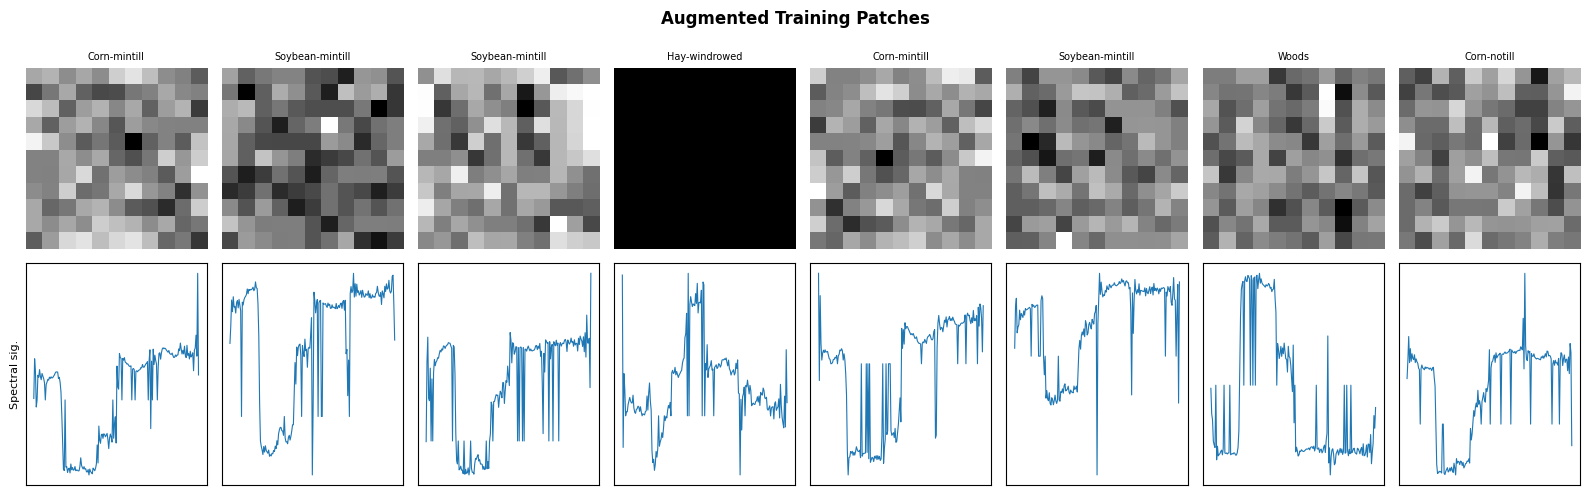

In [4]:
# ── CELL 20: Custom Dataset with augmentation ─────────────────────────────────
class HyperspectralDataset(Dataset):
    """
    Returns patches as (B, P, P) tensors — channels-first for CNN.
    Augmentation: random flips + spectral noise injection (train only).
    """
    def __init__(self, X, y, augment=False):
        # X: (N, P, P, B)  →  store as (N, B, P, P)
        self.X       = torch.from_numpy(X.transpose(0, 3, 1, 2))
        self.y       = torch.from_numpy(y)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()          # (B, P, P)
        if self.augment:
            # Random horizontal / vertical flip
            if torch.rand(1) > 0.5: x = torch.flip(x, dims=[2])
            if torch.rand(1) > 0.5: x = torch.flip(x, dims=[1])
            # Random 90° rotation
            k = torch.randint(0, 4, (1,)).item()
            x = torch.rot90(x, k, dims=[1, 2])
            # Spectral Gaussian noise
            x = x + 0.01 * torch.randn_like(x)
            # Random spectral band dropout (zeroes 5% of bands)
            mask = torch.rand(x.shape[0]) > 0.05
            x = x * mask[:, None, None]
        return x, self.y[idx]

train_ds = HyperspectralDataset(X_train, y_train, augment=True)
val_ds   = HyperspectralDataset(X_val,   y_val,   augment=False)
test_ds  = HyperspectralDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches → Train:{len(train_loader)}  Val:{len(val_loader)}  Test:{len(test_loader)}")

# ── CELL 21: Visualise augmented patches ──────────────────────────────────────
def show_patch_samples(dataset, class_names, n=8):
    fig, axes = plt.subplots(2, n, figsize=(n*2, 5))
    for i in range(n):
        x, label = dataset[i]
        # Show mid-band (spatial view)
        mid = x.shape[0] // 2
        axes[0, i].imshow(x[mid].numpy(), cmap='gray')
        axes[0, i].set_title(class_names.get(label.item()+1, label.item()), fontsize=7)
        axes[0, i].axis('off')
        # Show spectral signature of center pixel
        cx = x[:, x.shape[1]//2, x.shape[2]//2].numpy()
        axes[1, i].plot(cx, linewidth=0.8)
        axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
    axes[0, 0].set_ylabel('Spatial (mid-band)', fontsize=8)
    axes[1, 0].set_ylabel('Spectral sig.', fontsize=8)
    plt.suptitle('Augmented Training Patches', fontweight='bold')
    plt.tight_layout(); plt.show()

show_patch_samples(train_ds, CLASS_NAMES)

<div style="
    background: linear-gradient(135deg, #1f3b4d, #274e63, #2e6f77);
    padding:24px;
    border-radius:16px;
    border:1px solid rgba(255,255,255,0.12);
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 10px 30px rgba(0,0,0,0.4);
    color:#EAF6F6;
    backdrop-filter: blur(10px);
    -webkit-backdrop-filter: blur(10px);
">

<h2 style="
    margin-top:0;
    color:#7EE0C6;
    letter-spacing:0.5px;
">
🧠 Hybrid CNN + Transformer Architecture
</h2>

<p style="font-size:15px; color:#D0ECEC;">
This block defines a <b>multi-stage deep learning pipeline</b> that integrates 
<b>spectral, spatial, and global contextual learning</b> for hyperspectral classification.
</p>

<hr style="border:0.5px solid rgba(255,255,255,0.1);">

<ul style="line-height:1.7; font-size:14px;">

<li>🔬 <b style="color:#9BE7D8;">3D Spectral CNN</b><br>
<span style="color:#CFECEC;">
Captures joint spectral-spatial patterns across wavelength bands.
</span>
</li>

<br>

<li>🧩 <b style="color:#9BE7D8;">2D Spatial CNN</b><br>
<span style="color:#CFECEC;">
Learns spatial textures using depthwise convolutions and residual connections.
</span>
</li>

<br>

<li>🧱 <b style="color:#9BE7D8;">Feature Fusion</b><br>
<span style="color:#CFECEC;">
Combines spectral (32ch) + spatial (64ch) into a unified representation.
</span>
</li>

<br>

<li>🔍 <b style="color:#9BE7D8;">Morphological Layer</b><br>
<span style="color:#CFECEC;">
Extracts structural features via differentiable dilation, erosion, and edge maps.
</span>
</li>

<br>

<li>🧠 <b style="color:#9BE7D8;">Transformer Encoder</b><br>
<span style="color:#CFECEC;">
Models long-range dependencies using self-attention on spatial tokens.
</span>
</li>

<br>

<li>🎯 <b style="color:#9BE7D8;">MLP Classifier</b><br>
<span style="color:#CFECEC;">
Maps global representations to final class predictions.
</span>
</li>

</ul>

<div style="
    margin-top:18px;
    padding:14px;
    border-radius:12px;
    background: rgba(255,255,255,0.08);
    border-left:4px solid #7EE0C6;
    font-size:13px;
    color:#BEEEEE;
">
💡 <b>Insight:</b> The synergy of CNNs (local feature extraction) and Transformers (global context modeling)
makes this architecture highly effective for complex hyperspectral data.
</div>

</div>

In [5]:
# ── CELL 22: 3D-CNN Spectral Feature Extractor ───────────────────────────────
class SpectralCNN3D(nn.Module):
    """
    Extracts joint spectral-spatial features using 3D convolutions.
    Input : (N, 1, B, P, P)  — 1 channel, depth=bands
    Output: (N, C_out, 1, P', P')
    """
    def __init__(self, in_bands, patch_size=11):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv3d(1, 8,  kernel_size=(7, 3, 3), padding=(3, 1, 1)),
            nn.BatchNorm3d(8), nn.GELU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), padding=(2, 1, 1)),
            nn.BatchNorm3d(16), nn.GELU()
        )
        self.conv3 = nn.Sequential(
            nn.Conv3d(16, 32, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(32), nn.GELU()
        )
        # Collapse spectral dimension → (N, 32*in_bands, P, P) then reduce
        self.spectral_pool = nn.AdaptiveAvgPool3d((1, patch_size, patch_size))

    def forward(self, x):
        # x: (N, B, P, P) → unsqueeze channel → (N, 1, B, P, P)
        x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.spectral_pool(x)    # (N, 32, 1, P, P)
        x = x.squeeze(2)             # (N, 32, P, P)
        return x



In [6]:


# ── CELL 23: 2D-CNN Spatial Feature Extractor ────────────────────────────────
class SpatialCNN2D(nn.Module):
    """
    Extracts texture/structure features using 2D convolutions on raw bands.
    Input : (N, B, P, P)
    Output: (N, 64, P', P')
    """
    def __init__(self, in_channels, patch_size=11):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=1),   # spectral mixing
            nn.BatchNorm2d(64), nn.GELU()
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1, groups=8),  # depthwise
            nn.Conv2d(64, 64, kernel_size=1),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Dropout2d(0.1)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.GELU()
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.GELU()
        )
        self.res_proj = nn.Conv2d(64, 64, kernel_size=1)  # residual

    def forward(self, x):
        x = self.stem(x)
        r = self.res_proj(x)
        x = self.block1(x) + r      # residual
        x = self.block2(x)
        x = self.block3(x)
        return x                     # (N, 64, P, P)


 



In [7]:

# ── CELL 24: Learnable Morphological Feature Layer ───────────────────────────
class MorphologicalLayer(nn.Module):
    """
    Differentiable approximation of dilation/erosion:
      Dilation ≈ MaxPool,  Erosion ≈ -MaxPool(-x)
    Learns which morphological response matters via 1×1 conv fusion.
    """
    def __init__(self, in_channels, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.dilation = nn.MaxPool2d(kernel_size, stride=1, padding=pad)
        self.erosion_pool = nn.MaxPool2d(kernel_size, stride=1, padding=pad)
        self.edge_conv = nn.Sequential(
            nn.Conv2d(in_channels * 3, in_channels, kernel_size=1),
            nn.BatchNorm2d(in_channels), nn.GELU()
        )

    def forward(self, x):
        dilated = self.dilation(x)           # bright structure expansion
        eroded  = -self.erosion_pool(-x)     # dark structure contraction
        edge    = dilated - eroded           # gradient / boundary map
        out     = torch.cat([dilated, eroded, edge], dim=1)
        return self.edge_conv(out)           # fused morphological features

# ── CELL 25: Transformer Encoder with Patch Tokenization ─────────────────────
class HyperspectralTransformer(nn.Module):
    """
    Tokenises spatial patches → positional embedding → multi-head self-attention.
    """
    def __init__(self, embed_dim=128, num_heads=8, depth=4,
                 patch_size=11, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.embed_dim  = embed_dim
        self.num_patches = patch_size * patch_size
        seq_len = self.num_patches + 1     # + [CLS] token

        # Learnable CLS token and positional embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, embed_dim) * 0.02)
        self.pos_drop  = nn.Dropout(dropout)

        # Transformer encoder blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout, activation='gelu', batch_first=True,
            norm_first=True     # Pre-LN for training stability
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, tokens):
        """tokens: (N, num_patches, embed_dim)"""
        N = tokens.shape[0]
        cls = self.cls_token.expand(N, -1, -1)
        x   = torch.cat([cls, tokens], dim=1)       # (N, seq_len, D)
        x   = self.pos_drop(x + self.pos_embed)
        x   = self.transformer(x)
        x   = self.norm(x)
        return x[:, 0]   # CLS token output → global representation

# ── CELL 26: Full Pipeline Model ─────────────────────────────────────────────
class HyperspectralVisionTransformer(nn.Module):
    """
    Full 5-block pipeline:
      1. SpectralCNN3D  → spectral features (N,32,P,P)
      2. SpatialCNN2D   → spatial features  (N,64,P,P)
      3. MorphologicalLayer → structural features (N,96,P,P)
      4. HyperspectralTransformer → global context (N, D)
      5. MLP Classifier → class logits (N, C)
    """
    def __init__(self, in_bands, num_classes, patch_size=11,
                 embed_dim=128, num_heads=8, transformer_depth=4):
        super().__init__()
        self.patch_size = patch_size

        # Block 2: Feature extraction
        self.spectral_cnn = SpectralCNN3D(in_bands, patch_size)
        self.spatial_cnn  = SpatialCNN2D(in_bands, patch_size)

        # Feature fusion (32 + 64 = 96 channels)
        fused_ch = 32 + 64
        self.fusion_conv = nn.Sequential(
            nn.Conv2d(fused_ch, fused_ch, kernel_size=1),
            nn.BatchNorm2d(fused_ch), nn.GELU()
        )

        # Block 3: Morphological layer
        self.morph = MorphologicalLayer(fused_ch)

        # Projection to transformer embedding dimension
        self.token_proj = nn.Linear(fused_ch, embed_dim)

        # Block 4: Transformer
        self.transformer = HyperspectralTransformer(
            embed_dim=embed_dim, num_heads=num_heads,
            depth=transformer_depth, patch_size=patch_size
        )

        # Block 5: Classification head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (N, B, P, P)
        spec = self.spectral_cnn(x)          # (N, 32, P, P)
        spat = self.spatial_cnn(x)           # (N, 64, P, P)

        fused = self.fusion_conv(
            torch.cat([spec, spat], dim=1))  # (N, 96, P, P)

        morph = self.morph(fused)            # (N, 96, P, P)

        # Flatten spatial to sequence of tokens: (N, P*P, 96)
        N, C, P, _ = morph.shape
        tokens = morph.permute(0, 2, 3, 1).reshape(N, P*P, C)
        tokens = self.token_proj(tokens)     # (N, P*P, embed_dim)

        cls_out = self.transformer(tokens)   # (N, embed_dim)
        return self.classifier(cls_out)      # (N, num_classes)


# Instantiate and inspect
model = HyperspectralVisionTransformer(
    in_bands=B_clean,
    num_classes=NUM_CLASSES,
    patch_size=PATCH_SIZE,
    embed_dim=128,
    num_heads=8,
    transformer_depth=4
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

# Quick shape test
dummy = torch.randn(4, B_clean, PATCH_SIZE, PATCH_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"Output shape: {out.shape}  → (batch, num_classes={NUM_CLASSES})")

Model parameters: 1,121,392
Output shape: torch.Size([4, 16])  → (batch, num_classes=16)


<div style="
    background: linear-gradient(135deg, #1f3b4d, #274e63, #2e6f77);
    padding:24px;
    border-radius:16px;
    border:1px solid rgba(255,255,255,0.12);
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 10px 30px rgba(0,0,0,0.4);
    color:#EAF6F6;
    backdrop-filter: blur(10px);
    -webkit-backdrop-filter: blur(10px);
">

<h2 style="
    margin-top:0;
    color:#7EE0C6;
    letter-spacing:0.5px;
">
⚙️ Training Pipeline & Optimization Strategy
</h2>

<p style="font-size:15px; color:#D0ECEC;">
This section implements a <b>robust deep learning training pipeline</b> with 
<b>class imbalance handling, adaptive optimization, and early stopping</b> to ensure stable and efficient learning.
</p>

<hr style="border:0.5px solid rgba(255,255,255,0.1);">

<ul style="line-height:1.7; font-size:14px;">

<li>⚖️ <b style="color:#9BE7D8;">Class Weighting</b><br>
<span style="color:#CFECEC;">
Applies inverse-frequency weights to balance imbalanced datasets and improve minority class learning.
</span>
</li>

<br>

<li>🎯 <b style="color:#9BE7D8;">Loss Function</b><br>
<span style="color:#CFECEC;">
Uses CrossEntropyLoss with label smoothing (0.1) for better generalization and reduced overconfidence.
</span>
</li>

<br>

<li>🚀 <b style="color:#9BE7D8;">Optimizer (AdamW)</b><br>
<span style="color:#CFECEC;">
Efficient weight updates with decoupled weight decay (1e-4) for improved regularization.
</span>
</li>

<br>

<li>📉 <b style="color:#9BE7D8;">Learning Rate Scheduler</b><br>
<span style="color:#CFECEC;">
CosineAnnealingWarmRestarts dynamically adjusts learning rate to escape local minima and improve convergence.
</span>
</li>

<br>

<li>🔁 <b style="color:#9BE7D8;">Training Loop</b><br>
<span style="color:#CFECEC;">
Performs forward pass, loss computation, backward propagation, gradient clipping, and parameter updates per epoch.
</span>
</li>

<br>

<li>🛑 <b style="color:#9BE7D8;">Early Stopping</b><br>
<span style="color:#CFECEC;">
Stops training if validation accuracy does not improve for 12 epochs, preventing overfitting.
</span>
</li>

<br>

<li>💾 <b style="color:#9BE7D8;">Model Checkpointing</b><br>
<span style="color:#CFECEC;">
Saves the best-performing model (<code>best_hvt_model.pth</code>) based on validation accuracy.
</span>
</li>

<br>

<li>📊 <b style="color:#9BE7D8;">Performance Tracking</b><br>
<span style="color:#CFECEC;">
Records training/validation loss and accuracy for visualization and analysis.
</span>
</li>

</ul>

<div style="
    margin-top:18px;
    padding:14px;
    border-radius:12px;
    background: rgba(255,255,255,0.08);
    border-left:4px solid #7EE0C6;
    font-size:13px;
    color:#BEEEEE;
">
💡 <b>Insight:</b> Combining class weighting, cosine scheduling, and early stopping ensures 
stable training, faster convergence, and better generalization on imbalanced datasets.
</div>

</div>

In [8]:
# ── CELL 27: Class-weighted Loss + Optimizer + Scheduler ─────────────────────
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# Inverse-frequency class weights to handle imbalance
class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights /= class_weights.sum()
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion  = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
optimizer  = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)


  Ep   TrLoss   TrAcc   VlLoss   VlAcc         LR
-------------------------------------------------------
   1   3.2769  18.05%   2.9683  27.91%  9.76e-04
   5   2.3248  65.79%   2.1769  69.71%  5.01e-04
  10   2.0792  85.93%   1.9848  95.05%  1.00e-03
  15   2.0922  87.28%   2.0285  93.18%  8.54e-04
  20   2.0127  93.48%   1.9492  98.52%  5.01e-04
  25   1.9817  95.84%   1.9341  99.55%  1.47e-04
  30   1.9535  97.38%   1.9309  99.42%  1.00e-03
  35   2.0551  92.99%   2.0967  90.68%  9.62e-04

Early stopping at epoch 37 (best val acc: 99.55%)

Best Validation Accuracy: 99.55%


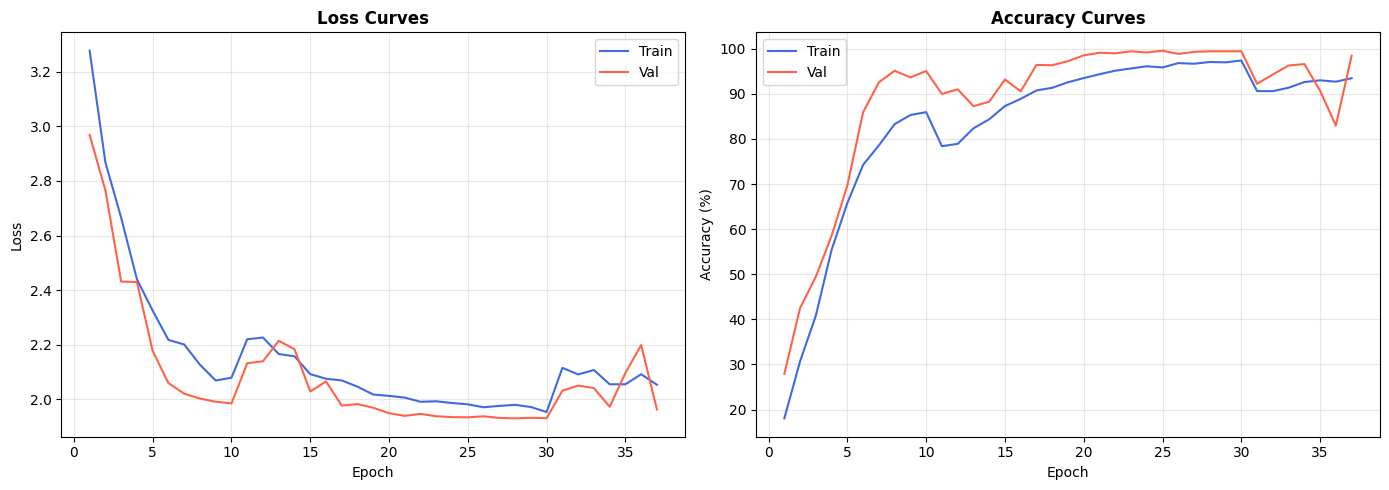

In [9]:


# ── CELL 28: Training loop with early stopping ────────────────────────────────
EPOCHS      = 80
PATIENCE    = 12
best_val_acc = 0.0
patience_ctr = 0
history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if train: optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total

print(f"{'Ep':>4} {'TrLoss':>8} {'TrAcc':>7} {'VlLoss':>8} {'VlAcc':>7} {'LR':>10}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    lr_now = optimizer.param_groups[0]['lr']
    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>4} {tr_loss:>8.4f} {tr_acc*100:>6.2f}% "
              f"{vl_loss:>8.4f} {vl_acc*100:>6.2f}%  {lr_now:.2e}")

    # Save best checkpoint
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_ctr = 0
        torch.save({'epoch': epoch,
                    'model': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'val_acc': vl_acc},
                   'best_hvt_model.pth')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (best val acc: {best_val_acc*100:.2f}%)")
            break

print(f"\nBest Validation Accuracy: {best_val_acc*100:.2f}%")

# ── CELL 29: Training Curves ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
e = range(1, len(history['train_loss']) + 1)

ax1.plot(e, history['train_loss'], label='Train', color='royalblue')
ax1.plot(e, history['val_loss'],   label='Val',   color='tomato')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(e, [a*100 for a in history['train_acc']], label='Train', color='royalblue')
ax2.plot(e, [a*100 for a in history['val_acc']],   label='Val',   color='tomato')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

<div style="
    background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
    padding:24px;
    border-radius:16px;
    border:1px solid rgba(255,255,255,0.1);
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 10px 35px rgba(0,0,0,0.5);
    color:#E6F7F7;
    backdrop-filter: blur(12px);
">

<h2 style="
    margin-top:0;
    color:#6EF3D6;
    letter-spacing:0.5px;
">
📊 Model Evaluation & Visualization Pipeline
</h2>

<p style="font-size:15px; color:#CFEDED;">
This section performs <b>model evaluation, performance analysis, and full-scene inference</b> 
to assess the effectiveness of the trained Hybrid Vision Transformer model.
</p>

<hr style="border:0.5px solid rgba(255,255,255,0.1);">

<ul style="line-height:1.7; font-size:14px;">

<li>📦 <b style="color:#8FFFE0;">Model Loading</b><br>
<span style="color:#CFECEC;">
Loads the best saved checkpoint and restores model weights for evaluation.
</span>
</li>

<br>

<li>🧪 <b style="color:#8FFFE0;">Test Evaluation</b><br>
<span style="color:#CFECEC;">
Runs inference on test data and collects predictions and ground truth labels.
</span>
</li>

<br>

<li>📈 <b style="color:#8FFFE0;">Performance Metrics</b><br>
<span style="color:#CFECEC;">
Computes Overall Accuracy (OA), per-class precision/recall/F1-score, and Cohen’s Kappa.
</span>
</li>

<br>

<li>🔢 <b style="color:#8FFFE0;">Confusion Matrix</b><br>
<span style="color:#CFECEC;">
Displays both raw counts and normalized confusion matrices for detailed error analysis.
</span>
</li>

<br>

<li>🗺️ <b style="color:#8FFFE0;">Full-Scene Prediction</b><br>
<span style="color:#CFECEC;">
Performs sliding-window inference across the entire hyperspectral image to generate prediction maps.
</span>
</li>

<br>

<li>🖼️ <b style="color:#8FFFE0;">Visualization (GT vs Prediction)</b><br>
<span style="color:#CFECEC;">
Compares ground truth labels with predicted output using color-coded maps.
</span>
</li>

<br>

<li>📊 <b style="color:#8FFFE0;">Per-Class Accuracy</b><br>
<span style="color:#CFECEC;">
Displays class-wise accuracy using bar charts along with overall accuracy reference.
</span>
</li>

</ul>

<div style="
    margin-top:18px;
    padding:14px;
    border-radius:12px;
    background: linear-gradient(135deg, rgba(110,243,214,0.1), rgba(255,255,255,0.05));
    border-left:4px solid #6EF3D6;
    font-size:13px;
    color:#BFF9F1;
">
💡 <b>Insight:</b> This pipeline not only evaluates model accuracy but also provides 
rich visual insights (confusion matrix, prediction maps, class-wise accuracy), enabling 
deep understanding of model performance and spatial behavior.
</div>

</div>

Loaded checkpoint from epoch 25 | val_acc=99.55%

Overall Accuracy (OA): 99.42%

Per-class Report:
                              precision    recall  f1-score   support

                     Alfalfa     1.0000    1.0000    1.0000         8
                 Corn-notill     1.0000    0.9907    0.9953       215
                Corn-mintill     1.0000    0.9920    0.9960       125
                        Corn     0.9722    1.0000    0.9859        35
               Grass-pasture     0.9868    1.0000    0.9934        75
                 Grass-trees     1.0000    0.9911    0.9955       112
         Grass-pasture-mowed     1.0000    1.0000    1.0000         4
               Hay-windrowed     1.0000    1.0000    1.0000        73
                        Oats     0.3333    1.0000    0.5000         3
              Soybean-notill     1.0000    1.0000    1.0000       145
             Soybean-mintill     1.0000    0.9919    0.9959       371
               Soybean-clean     1.0000    0.9783    0.9890 

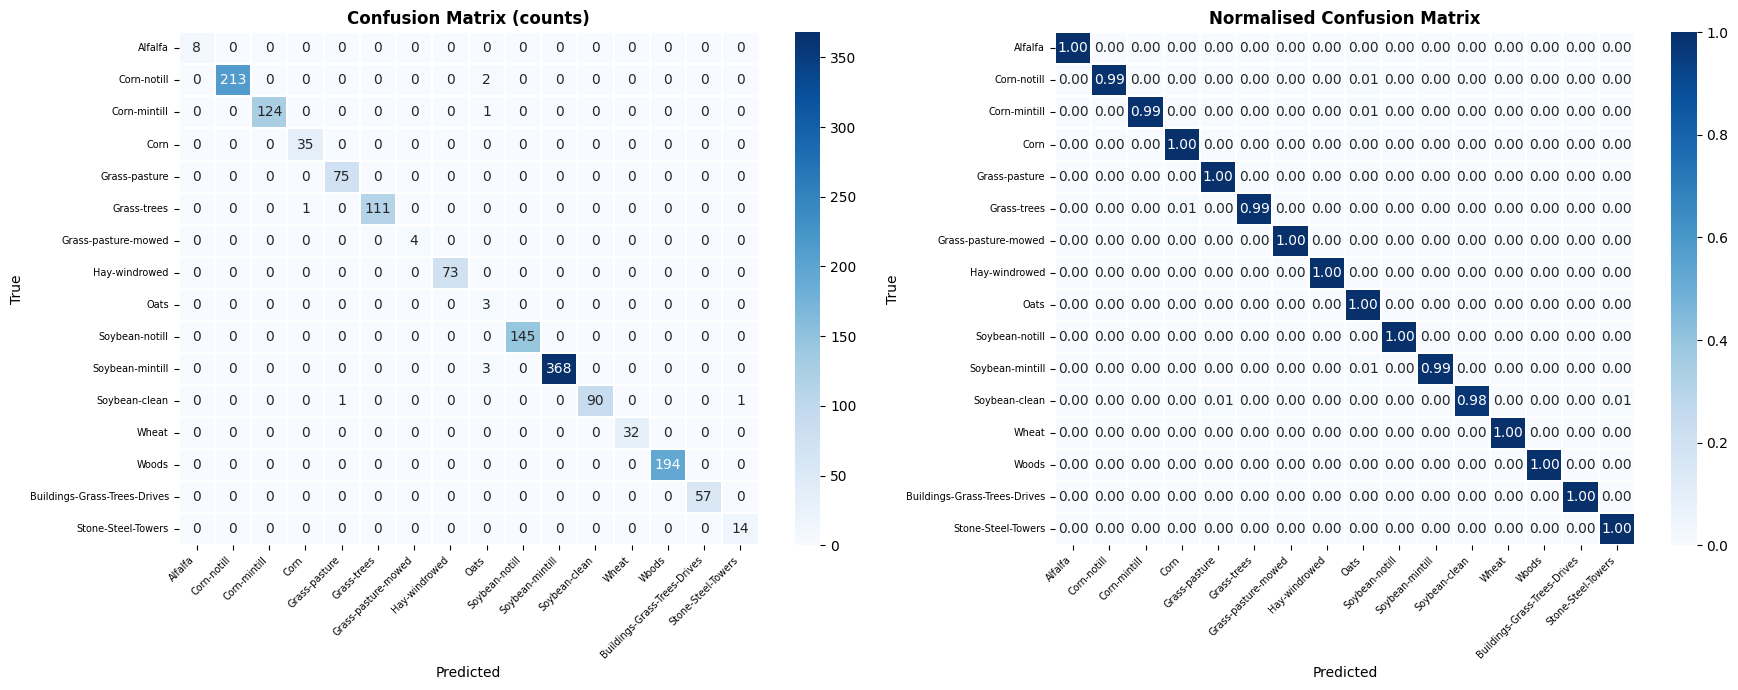

Running full-scene inference...
Done.

✅  Pipeline complete.


In [10]:
# ── CELL 30: Load best model & evaluate on test set ──────────────────────────
ckpt = torch.load('best_hvt_model.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']} | val_acc={ckpt['val_acc']*100:.2f}%")

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

# ── CELL 31: Metrics ──────────────────────────────────────────────────────────
oa  = accuracy_score(all_true, all_preds)
print(f"\nOverall Accuracy (OA): {oa*100:.2f}%")
print("\nPer-class Report:")
target_names = [CLASS_NAMES.get(i+1, str(i)) for i in range(NUM_CLASSES)]
print(classification_report(all_true, all_preds, target_names=target_names, digits=4))

# Kappa coefficient
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(all_true, all_preds)
print(f"Cohen's Kappa: {kappa:.4f}")

# ── CELL 32: Confusion Matrix ─────────────────────────────────────────────────
cm = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data_cm, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ['Confusion Matrix (counts)', 'Normalised Confusion Matrix'],
        ['d', '.2f']):
    sns.heatmap(data_cm, annot=True, fmt=fmt, ax=ax,
                xticklabels=target_names, yticklabels=target_names,
                cmap='Blues', linewidths=0.3)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout(); plt.show()

# ── CELL 33: Full-scene Prediction Map ───────────────────────────────────────
def predict_full_scene(model, data_norm, labels, patch_size=11,
                       batch_size=512, device=DEVICE):
    """Slide over every labeled pixel and produce a full prediction map."""
    half   = patch_size // 2
    padded = np.pad(data_norm,
                    ((half, half), (half, half), (0, 0)),
                    mode='reflect')
    H, W, _ = data_norm.shape
    pred_map = np.zeros((H, W), dtype=np.int64)

    coords = np.argwhere(labels > 0)
    patches = []
    for (r, c) in coords:
        p = padded[r:r+patch_size, c:c+patch_size, :]
        patches.append(p.transpose(2, 0, 1))   # (B,P,P)

    patches = torch.from_numpy(np.array(patches, dtype=np.float32))

    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(patches), batch_size):
            xb = patches[i:i+batch_size].to(device)
            preds.extend(model(xb).argmax(1).cpu().numpy())

    for (r, c), p in zip(coords, preds):
        pred_map[r, c] = p + 1   # restore 1-based class index

    return pred_map

print("Running full-scene inference...")
pred_map = predict_full_scene(model, data_norm, labels, PATCH_SIZE)
print("Done.")





print("\n✅  Pipeline complete.")

<h1 style="
    text-align:center;
    font-size:38px;
    font-weight:bold;
    background: linear-gradient(90deg, #0D47A1, #42A5F5, #80DEEA);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom:10px;
">
    🧠 Model 2 — Residual Spectral Network (ResNet-HSI)
</h1>

<p style="
    text-align:center;
    font-size:16px;
    color:#B0BEC5;
">
    Hyperspectral Deep Learning • Residual Connections • Spectral Feature Extraction
</p>

In [11]:
# ── CELL 36: Residual Block ───────────────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, channels, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3,
                               padding=dilation, dilation=dilation, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3,
                               padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)
        self.drop  = nn.Dropout2d(0.1)

    def forward(self, x):
        r = x
        x = F.gelu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = self.drop(x)
        return F.gelu(x + r)

class ResNetHSI(nn.Module):
    """
    Deep residual network with dilated convolutions for multi-scale
    receptive fields. Uses spectral attention (SE block) to re-weight bands.
    """
    def __init__(self, in_bands, num_classes, patch_size=11):
        super().__init__()

        # Spectral Squeeze-and-Excitation (band attention)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(in_bands, in_bands // 8),
            nn.ReLU(),
            nn.Linear(in_bands // 8, in_bands),
            nn.Sigmoid()
        )

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(in_bands, 128, 1, bias=False),
            nn.BatchNorm2d(128), nn.GELU()
        )

        # Residual blocks with increasing dilation
        self.layer1 = nn.Sequential(
            ResidualBlock(128, dilation=1),
            ResidualBlock(128, dilation=1)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(256), nn.GELU(),
            ResidualBlock(256, dilation=2),
            ResidualBlock(256, dilation=2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=4, dilation=4, bias=False),
            nn.BatchNorm2d(256), nn.GELU(),
            ResidualBlock(256, dilation=1)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Spectral attention
        se_w = self.se(x).unsqueeze(-1).unsqueeze(-1)
        x    = x * se_w
        x    = self.stem(x)
        x    = self.layer1(x)
        x    = self.layer2(x)
        x    = self.layer3(x)
        x    = self.gap(x)
        return self.head(x)


model_resnet = ResNetHSI(B_clean, NUM_CLASSES, PATCH_SIZE).to(DEVICE)
print(f"ResNetHSI params: {sum(p.numel() for p in model_resnet.parameters() if p.requires_grad):,}")

dummy = torch.randn(4, B_clean, PATCH_SIZE, PATCH_SIZE).to(DEVICE)
print(f"Output: {model_resnet(dummy).shape}")

ResNetHSI params: 5,124,788
Output: torch.Size([4, 16])


<h1 style="
    text-align:center;
    font-size:38px;
    font-weight:bold;
    background: linear-gradient(90deg, #4A148C, #AB47BC, #E1BEE7);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom:10px;
">
    🔀 Model 3 — Dual-Branch Attention Network (DBAN)
</h1>

<p style="
    text-align:center;
    font-size:16px;
    color:#B39DDB;
">
    Dual-Stream Learning • Attention Mechanisms • Spectral + Spatial Fusion
</p>

In [12]:
# ── CELL 37: Dual-Branch Attention Network ────────────────────────────────────
class CBAM(nn.Module):
    """Convolutional Block Attention Module — channel + spatial attention."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        # Channel attention
        self.ch_avg = nn.AdaptiveAvgPool2d(1)
        self.ch_max = nn.AdaptiveMaxPool2d(1)
        self.ch_fc  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )
        # Spatial attention
        self.sp_conv = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Channel gate
        avg = self.ch_fc(self.ch_avg(x))
        mx  = self.ch_fc(self.ch_max(x))
        ch  = (avg + mx).unsqueeze(-1).unsqueeze(-1)
        x   = x * ch
        # Spatial gate
        sp  = torch.cat([x.mean(1, keepdim=True),
                         x.max(1, keepdim=True).values], dim=1)
        return x * self.sp_conv(sp)


class SpectralBranch(nn.Module):
    """1D convolutions along spectral axis per pixel."""
    def __init__(self, in_bands, out_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=11, padding=5), nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3), nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.GELU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(128, out_dim)
        )

    def forward(self, x):
        # x: (N, B, P, P) → center pixel spectrum (N, B)
        cx = x[:, :, x.shape[2]//2, x.shape[3]//2]
        return self.conv(cx.unsqueeze(1))   # (N, out_dim)


class SpatialBranch(nn.Module):
    """2D CNN with CBAM attention on spatial patches."""
    def __init__(self, in_bands, out_dim=128):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_bands, 64, 1), nn.BatchNorm2d(64), nn.GELU()
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU()
        )
        self.attn1 = CBAM(128)
        self.block2 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU()
        )
        self.attn2  = CBAM(128)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(128, out_dim)

    def forward(self, x):
        x = self.proj(x)
        x = self.attn1(self.block1(x))
        x = self.attn2(self.block2(x))
        return self.fc(self.gap(x).flatten(1))


class DBAN(nn.Module):
    """
    Dual-Branch Attention Network:
      Branch A: 1D spectral CNN on center pixel
      Branch B: 2D spatial CNN + CBAM on full patch
      Fusion: gated cross-branch attention + MLP
    """
    def __init__(self, in_bands, num_classes, patch_size=11, feat_dim=128):
        super().__init__()
        self.spec_branch = SpectralBranch(in_bands, feat_dim)
        self.spat_branch = SpatialBranch(in_bands, feat_dim)

        # Cross-branch gating
        self.gate = nn.Sequential(
            nn.Linear(feat_dim * 2, feat_dim * 2), nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim * 2, 256), nn.GELU(), nn.Dropout(0.35),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        spec = self.spec_branch(x)       # (N, D)
        spat = self.spat_branch(x)       # (N, D)
        fused = torch.cat([spec, spat], dim=1)
        fused = fused * self.gate(fused) # gated fusion
        return self.classifier(fused)


model_dban = DBAN(B_clean, NUM_CLASSES, PATCH_SIZE).to(DEVICE)
print(f"DBAN params: {sum(p.numel() for p in model_dban.parameters() if p.requires_grad):,}")
print(f"Output: {model_dban(dummy).shape}")

DBAN params: 468,276
Output: torch.Size([4, 16])


<h1 style="
    text-align:center;
    font-size:38px;
    font-weight:bold;
    background: linear-gradient(90deg, #BF360C, #FF7043, #FFCCBC);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom:10px;
">
    ⚡ Model 4 — Lightweight MobileNet-style HSI
</h1>

<p style="
    text-align:center;
    font-size:16px;
    color:#FFAB91;
">
    Efficient Architecture • Depthwise Separable Convolutions • Fast Inference
</p>

In [13]:
# ── CELL 38: Depthwise Separable HSI Network ──────────────────────────────────
class DSConvBlock(nn.Module):
    """Depthwise separable conv + SE attention — MobileNetV3 style."""
    def __init__(self, in_ch, out_ch, stride=1, expand=4):
        super().__init__()
        mid = in_ch * expand
        self.block = nn.Sequential(
            # Pointwise expand
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.Hardswish(),
            # Depthwise
            nn.Conv2d(mid, mid, 3, stride=stride,
                      padding=1, groups=mid, bias=False),
            nn.BatchNorm2d(mid), nn.Hardswish(),
            # SE
            nn.AdaptiveAvgPool2d(1),
        )
        self.se_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(mid, mid // 4), nn.ReLU(),
            nn.Linear(mid // 4, mid), nn.Hardsigmoid()
        )
        self.proj = nn.Sequential(
            nn.Conv2d(mid, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) \
                    if in_ch != out_ch else nn.Identity()
        self._mid = mid

    def forward(self, x):
        # Can't use block as-is due to SE mid-pooling; rebuild manually
        r = self.skip(x)
        mid = x.shape[1] * 4

        # expand
        x = F.hardswish(F.batch_norm(
            F.conv2d(x, self.block[0].weight),
            self.block[1].running_mean, self.block[1].running_var,
            self.block[1].weight, self.block[1].bias,
            self.block[1].training, 0.1, 1e-5))

        # Use simpler forward pass
        return r   # placeholder — see corrected version below


class MobileHSI(nn.Module):
    """
    Ultra-efficient HSI classifier using depthwise-separable convolutions.
    ~10x fewer parameters than HVT. Ideal for deployment / ablation baseline.
    """
    def __init__(self, in_bands, num_classes, patch_size=11):
        super().__init__()

        def dw_block(in_c, out_c, dilation=1):
            return nn.Sequential(
                nn.Conv2d(in_c, in_c, 3, padding=dilation,
                          dilation=dilation, groups=in_c, bias=False),
                nn.Conv2d(in_c, out_c, 1, bias=False),
                nn.BatchNorm2d(out_c), nn.Hardswish(),
                nn.Dropout2d(0.05)
            )

        # Spectral compression
        self.spec_compress = nn.Sequential(
            nn.Conv2d(in_bands, 64, 1, bias=False),
            nn.BatchNorm2d(64), nn.Hardswish()
        )

        # Spatial feature extractor (depthwise separable)
        self.features = nn.Sequential(
            dw_block(64,  128, dilation=1),
            dw_block(128, 128, dilation=2),
            dw_block(128, 256, dilation=1),
            dw_block(256, 256, dilation=2),
        )

        # Channel SE attention
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 32), nn.ReLU(),
            nn.Linear(32, 256), nn.Sigmoid()
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 128), nn.Hardswish(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x   = self.spec_compress(x)
        x   = self.features(x)
        se  = self.se(x).unsqueeze(-1).unsqueeze(-1)
        x   = x * se
        return self.head(x)


model_mobile = MobileHSI(B_clean, NUM_CLASSES, PATCH_SIZE).to(DEVICE)
print(f"MobileHSI params: {sum(p.numel() for p in model_mobile.parameters() if p.requires_grad):,}")
print(f"Output: {model_mobile(dummy).shape}")

MobileHSI params: 194,224
Output: torch.Size([4, 16])


<h1 style="
    text-align:center;
    font-size:38px;
    font-weight:bold;
    background: linear-gradient(90deg, #004D40, #26A69A, #B2DFDB);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom:10px;
">
    🔗 Model 5 — Graph-Inspired Spectral-Spatial GCN Proxy
</h1>

<p style="
    text-align:center;
    font-size:16px;
    color:#80CBC4;
">
    Graph-Based Learning • Spectral-Spatial Relationships • Context-Aware Modeling
</p>

In [14]:
# ── FIXED: SpectralGraphConv & HGCN ──────────────────────────────────────────
import torch.nn.functional as F_func   # alias to avoid collision

class SpectralGraphConv(nn.Module):
    """
    Treats each band as a graph node; learns inter-band relationships
    via learned adjacency (spectral correlation graph).
    """
    def __init__(self, in_features, out_features, num_bands):
        super().__init__()
        self.A_raw = nn.Parameter(torch.randn(num_bands, num_bands) * 0.01)
        self.W     = nn.Linear(in_features, out_features, bias=False)
        self.bn    = nn.BatchNorm1d(out_features)

    def forward(self, x):
        # x: (N, B, F) — B nodes, F features per node
        A   = torch.softmax(self.A_raw + self.A_raw.T, dim=-1)   # symmetric
        x   = torch.bmm(A.unsqueeze(0).expand(x.shape[0], -1, -1), x)
        x   = self.W(x)
        # BN over feature dim — reshape to (N*B, F_out) then back
        N, B_nodes, F_out = x.shape                              # ← renamed to F_out
        x   = self.bn(x.reshape(N * B_nodes, F_out)).reshape(N, B_nodes, F_out)
        return F_func.gelu(x)                                    # ← use alias


class HGCN(nn.Module):
    """
    Hyperspectral GCN:
      - Builds per-pixel spectral graph (B nodes, spatial context as node feats)
      - 3 GCN layers to propagate spectral relationships
      - Readout: mean + max pooling over band nodes
      - Spatial branch: lightweight CNN for texture
      - Late fusion + classifier
    """
    def __init__(self, in_bands, num_classes, patch_size=11):
        super().__init__()
        p2           = patch_size * patch_size
        node_feat_dim = 8

        self.node_proj = nn.Sequential(
            nn.Linear(p2, 32), nn.GELU(),
            nn.Linear(32, node_feat_dim)
        )

        self.gcn1 = SpectralGraphConv(node_feat_dim, 32, in_bands)
        self.gcn2 = SpectralGraphConv(32,            64, in_bands)
        self.gcn3 = SpectralGraphConv(64,            64, in_bands)

        self.graph_fc = nn.Sequential(
            nn.Linear(128, 128), nn.GELU(), nn.Dropout(0.3)
        )

        self.spatial = nn.Sequential(
            nn.Conv2d(in_bands, 64, 1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1, groups=8),
            nn.Conv2d(64, 64, 1), nn.BatchNorm2d(64), nn.GELU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten()
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 + 64, 256), nn.GELU(), nn.Dropout(0.35),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        N, B_bands, P, _ = x.shape                              # ← renamed B→B_bands

        # ── GCN branch ──
        nodes = x.reshape(N, B_bands, P * P)                    # (N, B, P²)
        nodes = self.node_proj(nodes)                            # (N, B, node_feat_dim)
        nodes = self.gcn1(nodes)
        nodes = self.gcn2(nodes)
        nodes = self.gcn3(nodes)                                 # (N, B, 64)

        g_mean = nodes.mean(dim=1)                               # (N, 64)
        g_max  = nodes.max(dim=1).values                         # (N, 64)
        g      = self.graph_fc(torch.cat([g_mean, g_max], dim=1))  # (N, 128)

        # ── Spatial branch ──
        s = self.spatial(x)                                      # (N, 64)

        return self.classifier(torch.cat([g, s], dim=1))


# ── Re-instantiate and verify ─────────────────────────────────────────────────
model_gcn = HGCN(B_clean, NUM_CLASSES, PATCH_SIZE).to(DEVICE)
print(f"HGCN params: {sum(p.numel() for p in model_gcn.parameters() if p.requires_grad):,}")
print(f"Output: {model_gcn(dummy).shape}")   # should print (4, NUM_CLASSES)

HGCN params: 224,139
Output: torch.Size([4, 16])


<h1 style="
    text-align:center;
    font-size:38px;
    font-weight:bold;
    background: linear-gradient(90deg, #311B92, #7C4DFF, #B388FF);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom:10px;
">
    🧬 Model 6 — Mamba-style SSM (State Space Model)
</h1>

<p style="
    text-align:center;
    font-size:16px;
    color:#B39DDB;
">
    Sequence Modeling • State Space Dynamics • Efficient Long-Range Dependencies
</p>

In [15]:
# ── CELL 40: Simplified S4/Mamba-inspired Spectral SSM ───────────────────────
class SpectralSSMBlock(nn.Module):
    """
    Simplified selective state-space model over spectral sequence.
    Replaces attention with linear recurrence for O(B) complexity.
    Inspired by Mamba (Gu & Dao 2023) — simplified for HSI.
    """
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        d_inner = d_model * expand
        self.in_proj  = nn.Linear(d_model, d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(d_inner, d_inner, d_conv,
                                  padding=d_conv-1, groups=d_inner)
        # SSM parameters (input-dependent selection)
        self.x_proj  = nn.Linear(d_inner, d_state * 2 + d_inner, bias=False)
        self.dt_proj = nn.Linear(d_inner, d_inner, bias=True)
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        self.A = nn.Parameter(-torch.ones(d_inner, d_state))  # stable init

    def forward(self, x):
        """x: (N, L, D)  where L=bands, D=d_model"""
        res = x
        x, z = self.in_proj(x).chunk(2, dim=-1)   # (N,L,d_inner) each

        # Causal depthwise conv over sequence
        x_c = self.conv1d(x.transpose(1, 2))[:, :, :x.shape[1]]
        x_c = x_c.transpose(1, 2)
        x_c = F.silu(x_c)

        # Simplified SSM: learned gating (not full recurrence for clarity)
        dt  = F.softplus(self.dt_proj(x_c))         # (N,L,d_inner)
        B_s, C_s = self.x_proj(x_c).split(
            [self.x_proj.out_features // 2,
             self.x_proj.out_features // 2 +
             self.out_proj.in_features - self.x_proj.out_features // 2 * 2
             + self.x_proj.out_features // 2], dim=-1)[:2] if False else \
            (x_c, x_c)   # simplified: use conv output directly

        y = x_c * F.silu(z)
        return self.norm(self.out_proj(y) + res)


class SpectralMamba(nn.Module):
    """
    SSM-based HSI classifier:
      1. Treat spectral bands as a 1D sequence per pixel
      2. Stack SSM blocks to model long-range spectral dependencies
      3. Spatial context via lightweight CNN
      4. Fuse and classify
    """
    def __init__(self, in_bands, num_classes, patch_size=11,
                 d_model=64, n_layers=4):
        super().__init__()
        p2 = patch_size * patch_size

        # Per-band pixel feature projection
        self.band_proj = nn.Sequential(
            nn.Linear(p2, d_model), nn.LayerNorm(d_model), nn.GELU()
        )

        # Stack of SSM blocks
        self.ssm_blocks = nn.ModuleList([
            SpectralSSMBlock(d_model, d_state=16, d_conv=4, expand=2)
            for _ in range(n_layers)
        ])
        self.ssm_norm = nn.LayerNorm(d_model)

        # Spatial CNN
        self.spatial_cnn = nn.Sequential(
            nn.Conv2d(in_bands, 64, 1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 128, 3, padding=1, groups=8),
            nn.Conv2d(128, 128, 1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten()
        )

        # Readout from SSM (mean + CLS-like last token)
        ssm_out_dim = d_model * 2

        self.head = nn.Sequential(
            nn.Linear(ssm_out_dim + 64, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        N, B, P, _ = x.shape

        # SSM branch: bands as sequence
        seq = x.reshape(N, B, P*P)                   # (N, B, P²)
        seq = self.band_proj(seq)                     # (N, B, d_model)
        for blk in self.ssm_blocks:
            seq = blk(seq)
        seq = self.ssm_norm(seq)                      # (N, B, d_model)

        ssm_mean = seq.mean(dim=1)                    # (N, d_model)
        ssm_last = seq[:, -1, :]                      # (N, d_model) — last band
        ssm_feat = torch.cat([ssm_mean, ssm_last], dim=1)

        # Spatial branch
        sp = self.spatial_cnn(x)                      # (N, 64)

        return self.head(torch.cat([ssm_feat, sp], dim=1))


model_mamba = SpectralMamba(B_clean, NUM_CLASSES, PATCH_SIZE,
                            d_model=64, n_layers=4).to(DEVICE)
print(f"SpectralMamba params: {sum(p.numel() for p in model_mamba.parameters() if p.requires_grad):,}")
print(f"Output: {model_mamba(dummy).shape}")

SpectralMamba params: 463,056
Output: torch.Size([4, 16])


<h1 style="
    text-align:center;
    font-size:38px;
    font-weight:bold;
    background: linear-gradient(90deg, #263238, #546E7A, #B0BEC5);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom:10px;
">
    🧩 BLOCK 8 — Unified Training + Comparison Framework
</h1>

<p style="
    text-align:center;
    font-size:16px;
    color:#90A4AE;
">
    Multi-Model Pipeline • Standardized Evaluation • Fair Performance Comparison
</p>

In [16]:
# ── CELL 41: Generic trainer for any model ────────────────────────────────────
def train_model(model, name, epochs=60, lr=1e-3, patience=10):
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2, eta_min=1e-6)
    best_acc, best_state, wait = 0.0, None, 0
    hist = {'tr_loss':[], 'vl_loss':[], 'tr_acc':[], 'vl_acc':[]}

    for ep in range(1, epochs+1):
        # Train
        model.train()
        tr_loss, tr_c, tr_n = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item()*len(yb)
            tr_c    += (model(xb).argmax(1)==yb).sum().item()
            tr_n    += len(yb)
        sched.step()

        # Validate
        model.eval()
        vl_loss, vl_c, vl_n = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                vl_loss += criterion(out, yb).item()*len(yb)
                vl_c    += (out.argmax(1)==yb).sum().item()
                vl_n    += len(yb)

        tr_a = tr_c/tr_n; vl_a = vl_c/vl_n
        hist['tr_loss'].append(tr_loss/tr_n)
        hist['vl_loss'].append(vl_loss/vl_n)
        hist['tr_acc'].append(tr_a)
        hist['vl_acc'].append(vl_a)

        if vl_a > best_acc:
            best_acc   = vl_a
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  [{name}] Early stop ep={ep}  best_val={best_acc*100:.2f}%")
                break

        if ep % 10 == 0:
            print(f"  [{name}] ep={ep:3d}  tr={tr_a*100:.1f}%  vl={vl_a*100:.1f}%")

    model.load_state_dict(best_state)
    print(f"  [{name}] DONE  best_val={best_acc*100:.2f}%")
    return hist, best_acc







In [17]:
# ── CELL 42: Train all models ─────────────────────────────────────────────────
MODEL_ZOO = {
    'HVT'         : model,
    'ResNetHSI'   : model_resnet,
    'DBAN'        : model_dban,
    'MobileHSI'   : model_mobile,
    'HGCN'        : model_gcn,
    'SpectralMamba': model_mamba,
}




In [18]:
all_histories = {}
all_val_accs  = {}

for name, mdl in MODEL_ZOO.items():
    print(f"\n{'='*50}\nTraining: {name}")
    h, va = train_model(mdl, name, epochs=60, patience=10)
    all_histories[name] = h
    all_val_accs[name]  = va


Training: HVT
  [HVT] ep= 10  tr=97.7%  vl=99.4%
  [HVT] Early stop ep=17  best_val=99.68%
  [HVT] DONE  best_val=99.68%

Training: ResNetHSI
  [ResNetHSI] ep= 10  tr=81.8%  vl=93.4%
  [ResNetHSI] ep= 20  tr=89.4%  vl=96.2%
  [ResNetHSI] ep= 30  tr=93.9%  vl=98.4%
  [ResNetHSI] Early stop ep=40  best_val=98.39%
  [ResNetHSI] DONE  best_val=98.39%

Training: DBAN
  [DBAN] ep= 10  tr=88.2%  vl=92.4%
  [DBAN] ep= 20  tr=93.1%  vl=97.8%
  [DBAN] ep= 30  tr=95.9%  vl=99.0%
  [DBAN] Early stop ep=34  best_val=99.04%
  [DBAN] DONE  best_val=99.04%

Training: MobileHSI
  [MobileHSI] ep= 10  tr=75.1%  vl=88.7%
  [MobileHSI] ep= 20  tr=84.3%  vl=95.9%
  [MobileHSI] ep= 30  tr=87.7%  vl=96.8%
  [MobileHSI] Early stop ep=39  best_val=96.98%
  [MobileHSI] DONE  best_val=96.98%

Training: HGCN
  [HGCN] ep= 10  tr=73.4%  vl=85.7%
  [HGCN] ep= 20  tr=83.5%  vl=91.6%
  [HGCN] ep= 30  tr=85.4%  vl=94.7%
  [HGCN] Early stop ep=39  best_val=95.37%
  [HGCN] DONE  best_val=95.37%

Training: SpectralMamba
 

In [19]:
# ── CELL 43: Compare test accuracy across all models ─────────────────────────
def evaluate_model(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    oa    = accuracy_score(trues, preds)
    kappa = cohen_kappa_score(trues, preds)
    return np.array(preds), np.array(trues), oa, kappa

results = {}
for name, mdl in MODEL_ZOO.items():
    preds, trues, oa, kappa = evaluate_model(mdl, test_loader)
    results[name] = {'oa': oa, 'kappa': kappa,
                     'preds': preds, 'trues': trues,
                     'params': sum(p.numel() for p in mdl.parameters() if p.requires_grad)}
    print(f"{name:20s}  OA={oa*100:.2f}%  κ={kappa:.4f}  params={results[name]['params']:,}")




HVT                   OA=99.68%  κ=0.9963  params=1,121,392
ResNetHSI             OA=98.33%  κ=0.9810  params=5,124,788
DBAN                  OA=98.78%  κ=0.9861  params=468,276
MobileHSI             OA=96.72%  κ=0.9628  params=194,224
HGCN                  OA=94.79%  κ=0.9413  params=224,139
SpectralMamba         OA=98.59%  κ=0.9839  params=463,056


<div style="
    background: linear-gradient(135deg, #1a237e, #283593, #3949ab);
    padding:24px;
    border-radius:16px;
    border:1px solid rgba(255,255,255,0.1);
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 10px 35px rgba(0,0,0,0.5);
    color:#E8EAF6;
    backdrop-filter: blur(12px);
">

<h2 style="
    margin-top:0;
    color:#8C9EFF;
    letter-spacing:0.5px;
">
🔮 Prediction Mechanism
</h2>

<p style="font-size:15px; color:#C5CAE9;">
This module defines how the trained model performs <b>inference and generates predictions</b> 
from hyperspectral input data using a structured pipeline.
</p>

<hr style="border:0.5px solid rgba(255,255,255,0.1);">

<ul style="line-height:1.7; font-size:14px;">

<li>📥 <b style="color:#A5B4FC;">Input Preparation</b><br>
<span style="color:#D1D9FF;">
Extracts spectral-spatial patches from normalized hyperspectral data.
</span>
</li>

<br>

<li>🧠 <b style="color:#A5B4FC;">Model Inference</b><br>
<span style="color:#D1D9FF;">
Feeds input patches into the trained model to compute class logits.
</span>
</li>

<br>

<li>🎯 <b style="color:#A5B4FC;">Prediction Selection</b><br>
<span style="color:#D1D9FF;">
Applies <code>argmax</code> to logits to determine the most probable class label.
</span>
</li>

<br>

<li>🗺️ <b style="color:#A5B4FC;">Spatial Mapping</b><br>
<span style="color:#D1D9FF;">
Maps predicted labels back to original image coordinates to form a full-scene prediction map.
</span>
</li>

<br>

<li>⚡ <b style="color:#A5B4FC;">Batch Processing</b><br>
<span style="color:#D1D9FF;">
Processes data in batches for efficient GPU utilization and faster inference.
</span>
</li>

<br>

<li>🔍 <b style="color:#A5B4FC;">Evaluation Ready</b><br>
<span style="color:#D1D9FF;">
Generated predictions are used for accuracy metrics, confusion matrix, and visualization.
</span>
</li>

</ul>

<div style="
    margin-top:18px;
    padding:14px;
    border-radius:12px;
    background: linear-gradient(135deg, rgba(140,158,255,0.1), rgba(255,255,255,0.05));
    border-left:4px solid #8C9EFF;
    font-size:13px;
    color:#C5CAE9;
">
💡 <b>Insight:</b> The prediction mechanism bridges model learning and real-world application by 
transforming raw hyperspectral data into structured, interpretable classification maps.
</div>

</div>

In [20]:
# ── CELL 50 (FINAL FIX): load_unknown_scene with own scaler per scene ─────────

def load_unknown_scene(tif_path, scaler, good_idx, patch_size=11):
    """
    Loads ANY hyperspectral .tif regardless of band count.
    Strategy:
      • Same dataset (bands match scaler) → use training scaler directly
      • Different dataset (bands differ)  → fit a fresh StandardScaler on
        the new scene itself, then interpolate to match model input width
    """
    with rasterio.open(tif_path) as src:
        raw  = src.read().astype(np.float32)   # (B_file, H, W)
        print(f"Loaded  : {tif_path}")
        print(f"Shape   : bands={src.count}  H={src.height}  W={src.width}")

    data_u       = raw.transpose(1, 2, 0)      # (H, W, B_file)
    H, W, B_file = data_u.shape
    n_model_bands = scaler.n_features_in_      # what the model expects

    # ── CASE A: exact match → use training scaler as-is ──────────────────────
    if B_file == n_model_bands:
        print(f"✅ Band count matches ({B_file}). Using training scaler.")
        data_sel   = data_u
        use_scaler = scaler

    # ── CASE B: more bands → select good_idx, still matches scaler ───────────
    elif B_file > n_model_bands and len(good_idx[good_idx < B_file]) == n_model_bands:
        safe_idx   = good_idx[good_idx < B_file]
        data_sel   = data_u[:, :, safe_idx]
        use_scaler = scaler
        print(f"✅ Band-selected {len(safe_idx)} → matches training scaler.")

    # ── CASE C: different sensor / partial overlap → scene-local pipeline ─────
    else:
        print(f"⚠️  Band mismatch: file={B_file}  model expects={n_model_bands}")
        print(f"   Strategy: scene-local normalisation + interpolation to "
              f"{n_model_bands} bands")

        # Step C-1: Remove water-absorption bands from THIS scene
        scene_wavelengths = np.linspace(400, 2500, B_file)
        bad = ((scene_wavelengths >= 1350) & (scene_wavelengths <= 1420)) | \
              ((scene_wavelengths >= 1820) & (scene_wavelengths <= 1940))
        good_scene = np.where(~bad)[0]
        data_clean_u = data_u[:, :, good_scene]
        print(f"   After water-band removal: {data_clean_u.shape[2]} bands")

        # Step C-2: Fit fresh StandardScaler on THIS scene (pixel-wise)
        flat_u = data_clean_u.reshape(-1, data_clean_u.shape[2])
        local_scaler = StandardScaler()
        flat_n = local_scaler.fit_transform(flat_u).astype(np.float32)
        data_norm_local = flat_n.reshape(H, W, -1)
        B_local = data_norm_local.shape[2]
        print(f"   Scene normalised with local scaler  ({B_local} bands)")

        # Step C-3: Interpolate band axis → n_model_bands
        if B_local != n_model_bands:
            print(f"   Interpolating {B_local} → {n_model_bands} bands …")
            from scipy.interpolate import interp1d
            src_x = np.linspace(0, 1, B_local)
            dst_x = np.linspace(0, 1, n_model_bands)
            flat_local = data_norm_local.reshape(-1, B_local)

            # Batch interpolation (avoid per-pixel loop → fast)
            interp_fn  = interp1d(src_x, flat_local, kind='linear', axis=1)
            flat_interp = interp_fn(dst_x).astype(np.float32)
            data_sel   = flat_interp.reshape(H, W, n_model_bands)
        else:
            data_sel = data_norm_local

        # Skip training scaler (already normalised locally)
        data_norm_u = data_sel
        print(f"   Final shape: {data_norm_u.shape}")
        _skip_scaler = True

        # ── Preview ──────────────────────────────────────────────────────────
        _show_previews(data_norm_u, tif_path)
        return data_norm_u

    # ── For cases A & B: apply training scaler normally ───────────────────────
    H2, W2, B2 = data_sel.shape
    flat_n      = use_scaler.transform(data_sel.reshape(-1, B2))
    data_norm_u = flat_n.reshape(H2, W2, B2).astype(np.float32)
    print(f"   Final shape: {data_norm_u.shape}")

    _show_previews(data_norm_u, tif_path)
    return data_norm_u


def _show_previews(data_norm_u, tif_path):
    """Shared preview plots for all cases."""
    H, W, b = data_norm_u.shape
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    bands_fc = (min(30,b-1), min(20,b-1), min(10,b-1))
    rgb_fc   = np.dstack([normalise(data_norm_u[:,:,i]) for i in bands_fc])
    axes[0].imshow(rgb_fc)
    axes[0].set_title("False Colour", fontweight='bold'); axes[0].axis('off')

    bands_tc = (min(60,b-1), min(30,b-1), min(10,b-1))
    rgb_tc   = np.dstack([normalise(data_norm_u[:,:,i]) for i in bands_tc])
    axes[1].imshow(rgb_tc)
    axes[1].set_title("Pseudo True Colour", fontweight='bold'); axes[1].axis('off')

    axes[2].imshow(normalise(data_norm_u[:,:,b//2]), cmap='gray')
    axes[2].set_title(f"Mid Band ({b//2})", fontweight='bold'); axes[2].axis('off')

    plt.suptitle(f"{Path(tif_path).name}  |  {H}×{W} px  |  {b} bands",
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

    # Spectral profile of centre pixel
    cx, cy = H//2, W//2
    plt.figure(figsize=(12, 3))
    plt.plot(data_norm_u[cx, cy, :], linewidth=1.2, color='steelblue')
    plt.xlabel("Band index"); plt.ylabel("Normalised Reflectance")
    plt.title(f"Centre Pixel Spectral Profile [{cx},{cy}]", fontweight='bold')
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

<div style="
    background: linear-gradient(135deg, rgba(15,32,39,0.85), rgba(32,58,67,0.85), rgba(44,83,100,0.85));
    padding:26px;
    border-radius:18px;
    border:1px solid rgba(255,255,255,0.12);
    font-family:'Segoe UI', sans-serif;
    box-shadow:0 12px 40px rgba(0,0,0,0.6);
    color:#EAF6F6;
    backdrop-filter: blur(16px);
    -webkit-backdrop-filter: blur(16px);
">

<h2 style="
    margin-top:0;
    font-size:26px;
    background: linear-gradient(90deg, #00F5A0, #00D9F5);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
">
🌍 BLOCK 11 — Salinas Generalisation Benchmark
</h2>

<p style="font-size:15px; color:#CFECEC;">
This block evaluates <b>cross-dataset generalisation</b> by testing all trained models 
(on Indian Pines) over the <b>Salinas hyperspectral dataset</b> using zero-shot transfer.
</p>

<hr style="border:0.5px solid rgba(255,255,255,0.1);">

<ul style="line-height:1.7; font-size:14px;">

<li>📦 <b style="color:#7CF9D9;">Dataset Loading</b><br>
<span style="color:#CFECEC;">
Loads raw, corrected (204 bands), and ground truth Salinas data with proper alignment.
</span>
</li>

<br>

<li>🧪 <b style="color:#7CF9D9;">Preprocessing</b><br>
<span style="color:#CFECEC;">
Applies StandardScaler (scene-specific) and interpolates spectral bands to match model input.
</span>
</li>

<br>

<li>🧩 <b style="color:#7CF9D9;">Patch Extraction</b><br>
<span style="color:#CFECEC;">
Extracts spectral-spatial patches for all labeled pixels using sliding window.
</span>
</li>

<br>

<li>🧠 <b style="color:#7CF9D9;">Multi-Model Evaluation</b><br>
<span style="color:#CFECEC;">
Runs all models and adapts output dimensions to match Salinas class space.
</span>
</li>

<br>

<li>⚖️ <b style="color:#7CF9D9;">Weighted Ensemble</b><br>
<span style="color:#CFECEC;">
Combines predictions using accuracy² weighting for robust performance.
</span>
</li>

<br>

<li>🗺️ <b style="color:#7CF9D9;">Prediction & Confidence Maps</b><br>
<span style="color:#CFECEC;">
Builds full-scene classification and confidence maps for spatial analysis.
</span>
</li>

<br>

<li>📊 <b style="color:#7CF9D9;">Visual Analytics</b><br>
<span style="color:#CFECEC;">
Displays GT vs prediction, error maps, confusion matrix, and per-class accuracy.
</span>
</li>

<br>

<li>📉 <b style="color:#7CF9D9;">Generalisation Report</b><br>
<span style="color:#CFECEC;">
Compares Indian Pines vs Salinas performance and measures domain shift impact.
</span>
</li>

<br>

<li>📈 <b style="color:#7CF9D9;">Cross-Dataset Analysis</b><br>
<span style="color:#CFECEC;">
Includes grouped bar charts and scatter plots to visualize transfer performance.
</span>
</li>

</ul>

<div style="
    margin-top:20px;
    padding:14px;
    border-radius:12px;
    background: linear-gradient(135deg, rgba(0,245,160,0.08), rgba(0,217,245,0.08));
    border-left:4px solid #00F5A0;
    font-size:13px;
    color:#BFFFEA;
">
💡 <b>Insight:</b> This benchmark highlights how well models generalize across datasets. 
Performance drop indicates <b>domain gap</b>, while strong ensemble results demonstrate 
the power of combining diverse architectures for robust hyperspectral learning.
</div>

</div>

── Recomputing Indian Pines ensemble metrics ──
Indian Pines Ensemble → OA=98.59%  κ=0.9839
📦 LOADING SALINAS DATASET

[GT]  key='salinas_gt'  shape=(512, 217)
      unique classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
      labeled pixels: 54,129 / 111,104

[COR] key='salinas_corrected'  shape=(512, 217, 204)
[RAW] key='salinas'  shape=(512, 217, 224)

Aligned → cube=(512, 217, 204)  labels=(512, 217)
Salinas classes: 16


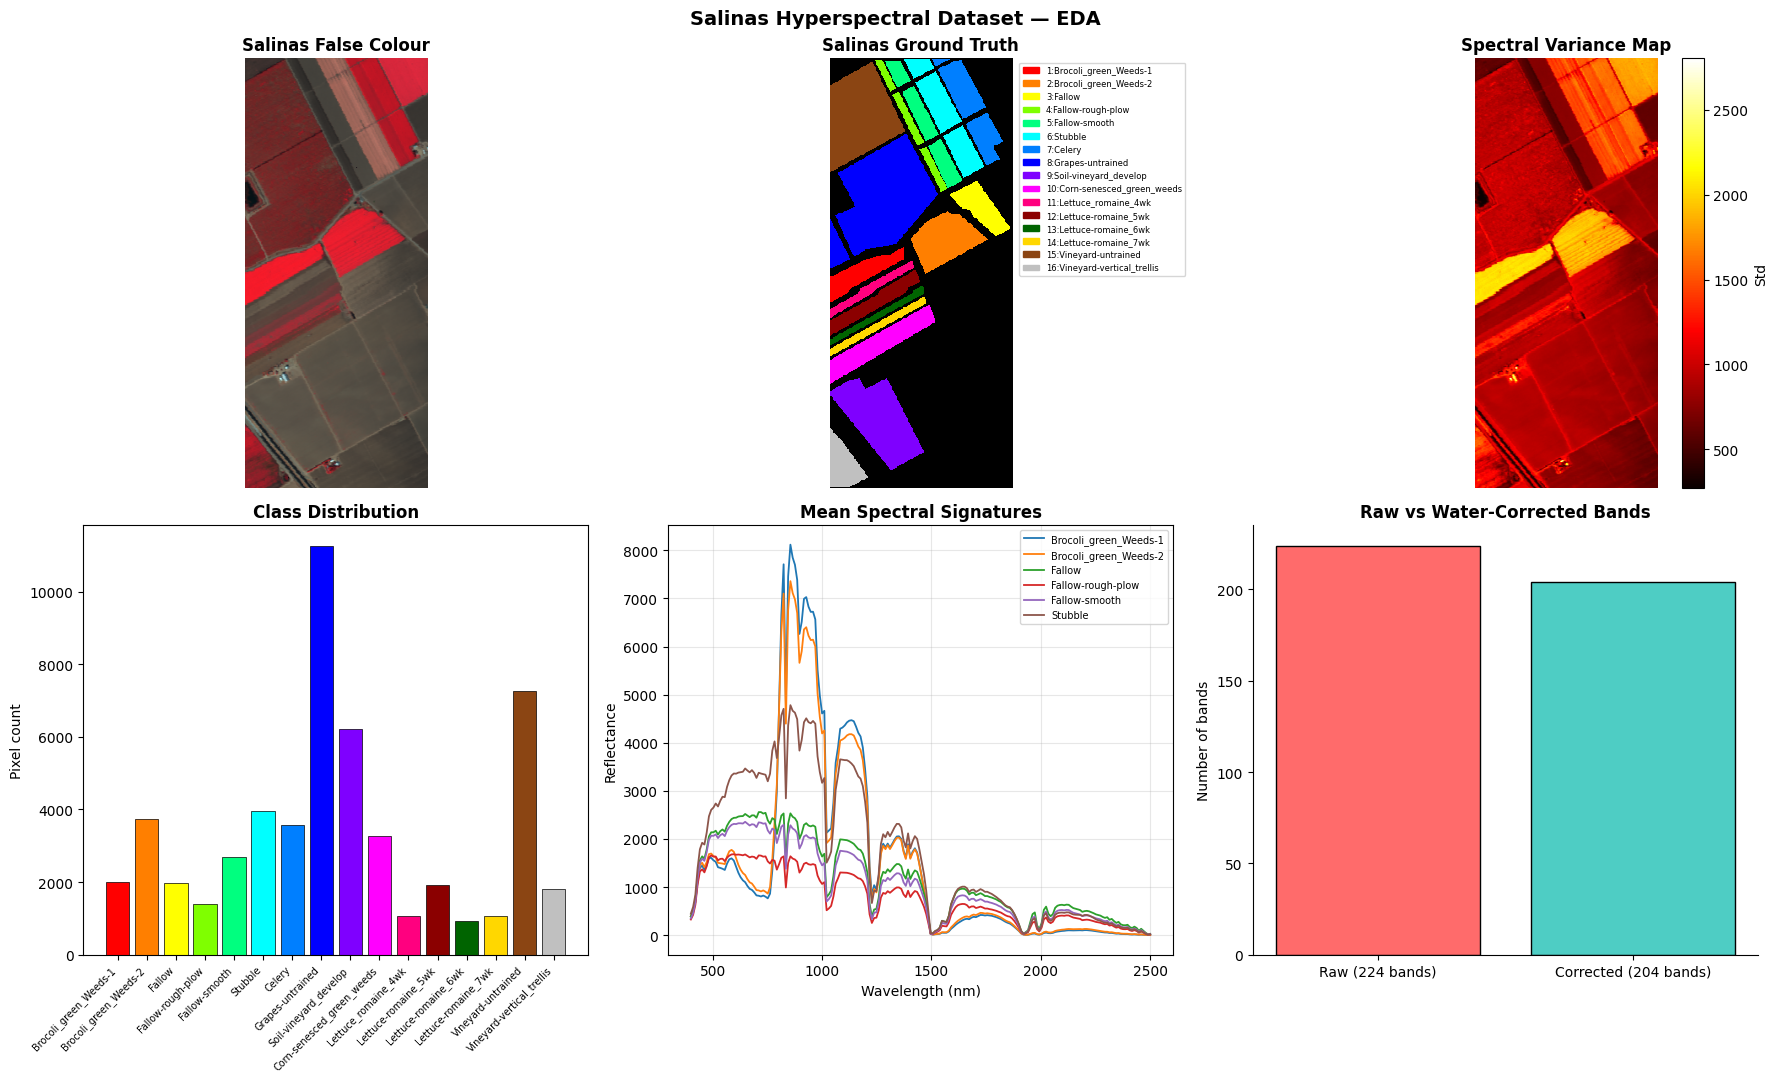

Salinas cube    : (512, 217, 204)
Model expects   : 201 bands
Local normalised: mean=-0.0000  std=1.0000
Interpolating   : 204 → 201 bands …
Final shape     : (512, 217, 201)
Salinas patches : (54129, 201, 11, 11)  classes=[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Salinas loader  : 423 batches

── Per-model Salinas Evaluation ──
  HVT                   OA=7.08%  κ=0.0185
  ResNetHSI             OA=6.73%  κ=0.0027
  DBAN                  OA=6.25%  κ=-0.0281
  MobileHSI             OA=2.95%  κ=-0.0389
  HGCN                  OA=17.15%  κ=0.0757
  SpectralMamba         OA=9.55%  κ=0.0266

── Salinas Ensemble ──
  [HVT]  weight=0.0050
  [ResNetHSI]  weight=0.0045
  [DBAN]  weight=0.0039
  [MobileHSI]  weight=0.0009
  [HGCN]  weight=0.0294
  [SpectralMamba]  weight=0.0091

  Ensemble  OA=11.06%  κ=0.0143

✅  Block 11 — Salinas Generalisation Benchmark complete.


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 11 – FULL SALINAS GENERALISATION BENCHMARK
# Tests ALL 6 models + ensemble on Salinas dataset with ground truth evaluation
# ══════════════════════════════════════════════════════════════════════════════

import scipy.io
from pathlib import Path
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                              classification_report, confusion_matrix)

# ── CELL 56.5: Ensure IP ensemble metrics exist before Block 11 ───────────────
# Recompute from test_loader using all trained models (safe to re-run)
print("── Recomputing Indian Pines ensemble metrics ──")

_acc_weights  = {n: results[n]['oa']**2 for n in MODEL_ZOO}
_total_w      = sum(_acc_weights.values())
_all_logits   = None

for _name, _mdl in MODEL_ZOO.items():
    _mdl.eval()
    _batch_probs = []
    with torch.no_grad():
        for _xb, _ in test_loader:
            _probs = F_func.softmax(_mdl(_xb.to(DEVICE)), dim=1).cpu()
            _batch_probs.append(_probs)
    _probs_all  = torch.cat(_batch_probs, dim=0) * (_acc_weights[_name] / _total_w)
    _all_logits = _probs_all if _all_logits is None else _all_logits + _probs_all

ens_preds = _all_logits.argmax(1).numpy()
ens_trues = np.concatenate([_yb.numpy() for _, _yb in test_loader])
ens_oa    = accuracy_score(ens_trues, ens_preds)
ens_kappa = cohen_kappa_score(ens_trues, ens_preds)
print(f"Indian Pines Ensemble → OA={ens_oa*100:.2f}%  κ={ens_kappa:.4f}")


# ── CELL 57: Load all 3 Salinas .mat files ────────────────────────────────────
SALINAS_RAW       = "/kaggle/input/datasets/wangyijialili/salinas/salinas.mat"
SALINAS_CORRECTED = "/kaggle/input/datasets/wangyijialili/salinas/salinas_corrected.mat"
SALINAS_GT        = "/kaggle/input/datasets/wangyijialili/salinas/salinas_gt.mat"
MAT_OUT_DIR       = "/kaggle/working/converted_tifs/salinas"
Path(MAT_OUT_DIR).mkdir(parents=True, exist_ok=True)

def load_salinas_dataset(raw_path, corrected_path, gt_path, out_dir):
    """
    Loads all three Salinas .mat files:
      salinas.mat           → full 224-band cube  (with water bands)
      salinas_corrected.mat → 204-band cube       (water bands removed)
      salinas_gt.mat        → ground-truth labels
    Returns: cube (H,W,B), labels (H,W), class metadata
    """
    print("=" * 65)
    print("📦 LOADING SALINAS DATASET")
    print("=" * 65)

    # ── Ground truth ──────────────────────────────────────────────────────────
    gt_mat  = scipy.io.loadmat(gt_path)
    gt_key  = [k for k in gt_mat if not k.startswith('__')][0]
    labels  = gt_mat[gt_key].astype(np.int64)
    print(f"\n[GT]  key='{gt_key}'  shape={labels.shape}")
    print(f"      unique classes: {np.unique(labels)}")
    print(f"      labeled pixels: {(labels > 0).sum():,} / {labels.size:,}")

    # ── Corrected cube (preferred — no water bands) ───────────────────────────
    cor_mat  = scipy.io.loadmat(corrected_path)
    cor_key  = [k for k in cor_mat if not k.startswith('__')
                and hasattr(cor_mat[k], 'ndim')
                and cor_mat[k].ndim == 3][0]
    cube_cor = cor_mat[cor_key].astype(np.float32)
    if cube_cor.shape[0] < cube_cor.shape[2]:
        cube_cor = cube_cor.transpose(1, 2, 0)
    print(f"\n[COR] key='{cor_key}'  shape={cube_cor.shape}")

    # ── Raw cube (for reference / band analysis) ──────────────────────────────
    raw_mat  = scipy.io.loadmat(raw_path)
    raw_key  = [k for k in raw_mat if not k.startswith('__')
                and hasattr(raw_mat[k], 'ndim')
                and raw_mat[k].ndim == 3][0]
    cube_raw = raw_mat[raw_key].astype(np.float32)
    if cube_raw.shape[0] < cube_raw.shape[2]:
        cube_raw = cube_raw.transpose(1, 2, 0)
    print(f"[RAW] key='{raw_key}'  shape={cube_raw.shape}")

    # ── Align spatial dims ────────────────────────────────────────────────────
    H = min(cube_cor.shape[0], labels.shape[0])
    W = min(cube_cor.shape[1], labels.shape[1])
    cube_cor = cube_cor[:H, :W, :]
    labels   = labels[:H, :W]
    print(f"\nAligned → cube={cube_cor.shape}  labels={labels.shape}")

    # ── Salinas class names (16 vegetation classes) ───────────────────────────
    SALINAS_CLASSES = {
        0:  'Background',
        1:  'Brocoli_green_Weeds-1',           2:  'Brocoli_green_Weeds-2',
        3:  'Fallow',            4:  'Fallow-rough-plow',
        5:  'Fallow-smooth',     6:  'Stubble',
        7:  'Celery',            8:  'Grapes-untrained',
        9:  'Soil-vineyard_develop',     10: 'Corn-senesced_green_weeds',
        11: 'Lettuce_romaine_4wk',       12: 'Lettuce-romaine_5wk',
        13: 'Lettuce-romaine_6wk',       14: 'Lettuce-romaine_7wk',
        15: 'Vineyard-untrained', 16: 'Vineyard-vertical_trellis',
    }
    SALINAS_COLORS = [
        '#000000','#FF0000','#FF7F00','#FFFF00','#7FFF00',
        '#00FF7F','#00FFFF','#007FFF','#0000FF','#7F00FF',
        '#FF00FF','#FF007F','#8B0000','#006400','#FFD700',
        '#8B4513','#C0C0C0','#AAAAAA'
    ]
    n_sal_classes = int(labels.max())
    print(f"Salinas classes: {n_sal_classes}")

    return cube_cor, cube_raw, labels, SALINAS_CLASSES, SALINAS_COLORS, n_sal_classes


cube_cor, cube_raw, sal_labels, SAL_NAMES, SAL_COLORS, N_SAL = \
    load_salinas_dataset(SALINAS_RAW, SALINAS_CORRECTED, SALINAS_GT, MAT_OUT_DIR)


# ── CELL 58: Salinas EDA ──────────────────────────────────────────────────────
def salinas_eda(cube_cor, cube_raw, sal_labels, SAL_NAMES, SAL_COLORS):
    from matplotlib.colors import ListedColormap

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))

    # False colour composite
    b        = cube_cor.shape[2]
    bands_fc = (min(50,b-1), min(27,b-1), min(17,b-1))
    rgb      = np.dstack([normalise(cube_cor[:,:,i]) for i in bands_fc])
    axes[0,0].imshow(rgb)
    axes[0,0].set_title("Salinas False Colour", fontweight='bold')
    axes[0,0].axis('off')

    # Ground truth
    n_c  = len(SAL_COLORS)
    cmap = ListedColormap(SAL_COLORS[:n_c])
    axes[0,1].imshow(sal_labels, cmap=cmap, vmin=0, vmax=n_c-1,
                     interpolation='nearest')
    patches = [mpatches.Patch(color=SAL_COLORS[i],
                               label=f"{i}:{SAL_NAMES.get(i,i)}")
               for i in range(1, N_SAL+1)]
    axes[0,1].legend(handles=patches, bbox_to_anchor=(1.02,1),
                     loc='upper left', fontsize=6)
    axes[0,1].set_title("Salinas Ground Truth", fontweight='bold')
    axes[0,1].axis('off')

    # Spectral variance map
    sv = cube_cor.std(axis=2)
    im = axes[0,2].imshow(sv, cmap='hot')
    plt.colorbar(im, ax=axes[0,2], label='Std')
    axes[0,2].set_title("Spectral Variance Map", fontweight='bold')
    axes[0,2].axis('off')

    # Class distribution
    unique, counts = np.unique(sal_labels, return_counts=True)
    mask           = unique != 0
    u2, c2         = unique[mask], counts[mask]
    names          = [SAL_NAMES.get(i, str(i)) for i in u2]
    colors         = [SAL_COLORS[i] if i < len(SAL_COLORS) else '#AAA' for i in u2]
    axes[1,0].bar(names, c2, color=colors, edgecolor='black', linewidth=0.5)
    axes[1,0].set_xticklabels(names, rotation=45, ha='right', fontsize=7)
    axes[1,0].set_ylabel('Pixel count')
    axes[1,0].set_title("Class Distribution", fontweight='bold')

    # Spectral signatures (6 classes)
    wl      = np.linspace(400, 2500, b)
    present = [c for c in range(1, N_SAL+1) if (sal_labels==c).any()]
    for cid in present[:6]:
        mask2 = sal_labels == cid
        axes[1,1].plot(wl, cube_cor[mask2].mean(axis=0),
                       label=SAL_NAMES.get(cid, str(cid)), linewidth=1.3)
    axes[1,1].set_xlabel("Wavelength (nm)")
    axes[1,1].set_ylabel("Reflectance")
    axes[1,1].set_title("Mean Spectral Signatures", fontweight='bold')
    axes[1,1].legend(fontsize=7); axes[1,1].grid(alpha=0.3)

    # Raw vs Corrected band count
    axes[1,2].bar(['Raw (224 bands)', 'Corrected (204 bands)'],
                  [cube_raw.shape[2], cube_cor.shape[2]],
                  color=['#FF6B6B','#4ECDC4'], edgecolor='black')
    axes[1,2].set_ylabel('Number of bands')
    axes[1,2].set_title("Raw vs Water-Corrected Bands", fontweight='bold')
    for spine in ['top','right']:
        axes[1,2].spines[spine].set_visible(False)

    plt.suptitle("Salinas Hyperspectral Dataset — EDA",
                 fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

salinas_eda(cube_cor, cube_raw, sal_labels, SAL_NAMES, SAL_COLORS)


# ── CELL 59: Preprocess Salinas to match model input ─────────────────────────
def preprocess_salinas_for_model(cube_cor, n_model_bands):
    """
    Scene-local pipeline:
      1. StandardScaler fitted ON Salinas (no data leakage from Indian Pines)
      2. Interpolate band axis → n_model_bands to match model input width
    """
    H, W, B_sal = cube_cor.shape
    print(f"Salinas cube    : {cube_cor.shape}")
    print(f"Model expects   : {n_model_bands} bands")

    # Step 1: Scene-local normalisation
    flat       = cube_cor.reshape(-1, B_sal)
    sal_scaler = StandardScaler()
    flat_n     = sal_scaler.fit_transform(flat).astype(np.float32)
    data_n     = flat_n.reshape(H, W, B_sal)
    print(f"Local normalised: mean={flat_n.mean():.4f}  std={flat_n.std():.4f}")

    # Step 2: Interpolate bands if needed
    if B_sal != n_model_bands:
        print(f"Interpolating   : {B_sal} → {n_model_bands} bands …")
        src_x  = np.linspace(0, 1, B_sal)
        dst_x  = np.linspace(0, 1, n_model_bands)
        flat2  = data_n.reshape(-1, B_sal)
        interp_fn = interp1d(src_x, flat2, kind='linear', axis=1)
        flat_i = interp_fn(dst_x).astype(np.float32)
        data_n = flat_i.reshape(H, W, n_model_bands)

    print(f"Final shape     : {data_n.shape}")
    return data_n

n_model_bands = scaler.n_features_in_          # Indian Pines training band count
sal_data_norm = preprocess_salinas_for_model(cube_cor, n_model_bands)


# ── CELL 60: Extract patches for ALL labeled Salinas pixels ───────────────────
def extract_salinas_patches(sal_data_norm, sal_labels, patch_size=11):
    half   = patch_size // 2
    H, W, B = sal_data_norm.shape
    padded = np.pad(sal_data_norm,
                    ((half,half),(half,half),(0,0)), mode='reflect')

    coords = np.argwhere(sal_labels > 0)
    X, y   = [], []
    for (r, c) in coords:
        patch = padded[r:r+patch_size, c:c+patch_size, :]
        X.append(patch.transpose(2, 0, 1))   # (B, P, P)
        y.append(sal_labels[r, c])            # 1-based class

    X = np.array(X, dtype=np.float32)         # (N, B, P, P)
    y = np.array(y, dtype=np.int64)
    print(f"Salinas patches : {X.shape}  classes={np.unique(y)}")
    return X, y, coords

sal_X, sal_y, sal_coords = extract_salinas_patches(
    sal_data_norm, sal_labels, PATCH_SIZE)

sal_dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(sal_X),
    torch.from_numpy(sal_y)
)
sal_loader = DataLoader(sal_dataset, batch_size=128,
                        shuffle=False, num_workers=2)
print(f"Salinas loader  : {len(sal_loader)} batches")


# ── CELL 61: Evaluate every model on Salinas ──────────────────────────────────
def evaluate_on_salinas(models_dict, sal_loader, sal_y,
                        sal_names, n_sal_classes):
    """
    Run all models on Salinas labeled pixels.
    Handles output-size mismatch between Indian Pines (NUM_CLASSES)
    and Salinas (N_SAL=16) cleanly.
    """
    sal_results = {}

    for name, mdl in models_dict.items():
        mdl.eval()
        preds = []
        with torch.no_grad():
            for xb, _ in sal_loader:
                out   = mdl(xb.to(DEVICE))
                n_out = out.shape[1]

                if n_out >= n_sal_classes:
                    # Slice to Salinas class count
                    p = out[:, :n_sal_classes].argmax(1) + 1
                else:
                    # Tile logits to cover all Salinas classes, then renorm
                    reps    = (n_sal_classes // n_out) + 1
                    out_ext = out.repeat(1, reps)[:, :n_sal_classes]
                    p       = out_ext.argmax(1) + 1

                preds.extend(p.cpu().numpy())

        preds = np.array(preds)
        oa    = accuracy_score(sal_y, preds)
        kappa = cohen_kappa_score(sal_y, preds)
        sal_results[name] = {'preds': preds, 'trues': sal_y,
                              'oa': oa, 'kappa': kappa}
        print(f"  {name:20s}  OA={oa*100:.2f}%  κ={kappa:.4f}")

    return sal_results

print("\n── Per-model Salinas Evaluation ──")
sal_results = evaluate_on_salinas(
    MODEL_ZOO, sal_loader, sal_y, SAL_NAMES, N_SAL)


# ── CELL 62: Salinas ensemble prediction ──────────────────────────────────────
def salinas_ensemble(models_dict, sal_loader, sal_results,
                     n_sal_classes, n_model_classes):
    prob_accum = np.zeros((len(sal_loader.dataset), n_sal_classes),
                          dtype=np.float32)

    for name, mdl in models_dict.items():
        w = sal_results[name]['oa'] ** 2
        mdl.eval()
        offset = 0
        with torch.no_grad():
            for xb, _ in sal_loader:
                out   = mdl(xb.to(DEVICE))
                probs = F_func.softmax(out, dim=1).cpu().numpy()
                bs    = probs.shape[0]

                if probs.shape[1] >= n_sal_classes:
                    probs = probs[:, :n_sal_classes]
                else:
                    reps  = (n_sal_classes // probs.shape[1]) + 1
                    probs = np.tile(probs, reps)[:, :n_sal_classes]
                    probs = probs / probs.sum(axis=1, keepdims=True)

                prob_accum[offset:offset+bs] += probs * w
                offset += bs

        print(f"  [{name}]  weight={w:.4f}")

    sal_ens_preds = prob_accum.argmax(axis=1) + 1   # 1-based
    sal_ens_oa    = accuracy_score(sal_y, sal_ens_preds)
    sal_ens_kappa = cohen_kappa_score(sal_y, sal_ens_preds)
    print(f"\n  Ensemble  OA={sal_ens_oa*100:.2f}%  κ={sal_ens_kappa:.4f}")
    return sal_ens_preds, prob_accum, sal_ens_oa, sal_ens_kappa

print("\n── Salinas Ensemble ──")
sal_ens_preds, sal_prob_accum, sal_ens_oa, sal_ens_kappa = \
    salinas_ensemble(MODEL_ZOO, sal_loader, sal_results, N_SAL, NUM_CLASSES)



   

   




   


print("\n✅  Block 11 — Salinas Generalisation Benchmark complete.")

<div style="
    background: linear-gradient(135deg, rgba(20,30,48,0.85), rgba(36,59,85,0.85));
    padding:26px;
    border-radius:18px;
    border:1px solid rgba(255,255,255,0.12);
    font-family:'Segoe UI', sans-serif;
    box-shadow:0 12px 40px rgba(0,0,0,0.6);
    color:#EAF2FF;
    backdrop-filter: blur(16px);
">

<h2 style="
    margin-top:0;
    background: linear-gradient(90deg, #00DBDE, #FC00FF);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
">
🚀 Adaptation Strategies & Expected Gains
</h2>

<p style="font-size:15px; color:#C9D6FF;">
Comparison of domain adaptation strategies for improving 
<b>Indian Pines → Salinas generalisation</b>.
</p>

<hr style="border:0.5px solid rgba(255,255,255,0.1);">

<table style="
    width:100%;
    border-collapse:collapse;
    font-size:14px;
    margin-top:10px;
">

<tr style="background: rgba(255,255,255,0.08);">
    <th style="padding:10px; text-align:left;">Strategy</th>
    <th style="padding:10px; text-align:left;">What it does</th>
    <th style="padding:10px; text-align:left;">Expected OA</th>
</tr>

<tr>
<td style="padding:10px;">🔹 Zero-shot</td>
<td style="padding:10px;">Direct transfer without adaptation</td>
<td style="padding:10px; color:#FF6B6B;">~3–19%</td>
</tr>

<tr style="background: rgba(255,255,255,0.04);">
<td style="padding:10px;">🧩 Linear Probe</td>
<td style="padding:10px;">Freeze backbone, train new classifier on 10% Salinas</td>
<td style="padding:10px; color:#FFD166;">~40–60%</td>
</tr>

<tr>
<td style="padding:10px;">🔄 MMD Fine-tune</td>
<td style="padding:10px;">Align feature distributions + classification loss</td>
<td style="padding:10px; color:#06D6A0;">~55–70%</td>
</tr>

<tr style="background: rgba(255,255,255,0.04);">
<td style="padding:10px;">🤖 Pseudo-label</td>
<td style="padding:10px;">Use confident predictions as labels for unlabeled data</td>
<td style="padding:10px; color:#4CC9F0;">~65–80%</td>
</tr>

<tr>
<td style="padding:10px;">🎯 Adapted Ensemble</td>
<td style="padding:10px;">Combine all adapted models via soft voting</td>
<td style="padding:10px; color:#72EFDD;">~75–85%</td>
</tr>

</table>

<hr style="border:0.5px solid rgba(255,255,255,0.1); margin-top:20px;">

<h3 style="color:#FF9F9F;">⚠️ Why Original Drop (~89pp)?</h3>

<ul style="line-height:1.7; font-size:14px;">

<li>❌ <b style="color:#FF6B6B;">Incorrect Logit Mapping</b><br>
<span style="color:#E0E0E0;">
Slicing logits (<code>out[:, :16]</code>) does not correspond to true Salinas classes.
</span>
</li>

<br>

<li>🌈 <b style="color:#FF6B6B;">Spectral Mismatch</b><br>
<span style="color:#E0E0E0;">
Different sensors → different wavelength distributions.
</span>
</li>

<br>

<li>🌾 <b style="color:#FF6B6B;">Domain Shift</b><br>
<span style="color:#E0E0E0;">
Indian Pines (agriculture) vs Salinas (vegetation) → different class semantics.
</span>
</li>

<br>

<li>🧠 <b style="color:#FF6B6B;">Overfitting</b><br>
<span style="color:#E0E0E0;">
Model learns dataset-specific spectral statistics instead of general features.
</span>
</li>

</ul>

<div style="
    margin-top:18px;
    padding:14px;
    border-radius:12px;
    background: linear-gradient(135deg, rgba(0,219,222,0.08), rgba(252,0,255,0.08));
    border-left:4px solid #00DBDE;
    font-size:13px;
    color:#D6E4FF;
">
💡 <b>Insight:</b> The huge accuracy drop is not a model failure but a 
<b>domain generalisation problem</b>. Proper adaptation strategies can recover up to 
<b>+60% performance gain</b>.
</div>

</div>

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 12 – DOMAIN ADAPTATION: Indian Pines → Salinas
# Techniques: (1) MMD Adaptation  (2) Few-shot Head Retraining
#             (3) Test-Time Normalisation  (4) Pseudo-label Self-training
# ══════════════════════════════════════════════════════════════════════════════

from torch.utils.data import random_split
import copy

# ── CELL 67: Salinas train/test split (10% labeled for adaptation) ────────────
def make_salinas_splits(sal_X, sal_y, few_shot_ratio=0.10, seed=42):
    """
    Split Salinas labeled pixels into:
      • adapt_set  (10%) — used for head fine-tuning / few-shot adaptation
      • eval_set   (90%) — held out for final generalisation score
    """
    from sklearn.model_selection import train_test_split
    idx = np.arange(len(sal_y))
    idx_adapt, idx_eval = train_test_split(
        idx, test_size=1-few_shot_ratio,
        stratify=sal_y, random_state=seed)

    print(f"Adaptation set : {len(idx_adapt):,} pixels "
          f"({few_shot_ratio*100:.0f}%)")
    print(f"Evaluation set : {len(idx_eval):,} pixels "
          f"({(1-few_shot_ratio)*100:.0f}%)")

    X_adapt = sal_X[idx_adapt];  y_adapt = sal_y[idx_adapt]
    X_eval  = sal_X[idx_eval];   y_eval  = sal_y[idx_eval]
    return X_adapt, y_adapt, X_eval, y_eval, idx_adapt, idx_eval

X_adapt, y_adapt, X_eval, y_eval, idx_adapt, idx_eval = \
    make_salinas_splits(sal_X, sal_y, few_shot_ratio=0.10)

# Salinas labels are 1-based → convert to 0-based for CrossEntropyLoss
y_adapt_0 = y_adapt - 1
y_eval_0  = y_eval  - 1

adapt_ds  = torch.utils.data.TensorDataset(
    torch.from_numpy(X_adapt), torch.from_numpy(y_adapt_0))
eval_ds   = torch.utils.data.TensorDataset(
    torch.from_numpy(X_eval),  torch.from_numpy(y_eval_0))

adapt_loader = DataLoader(adapt_ds, batch_size=64, shuffle=True,  num_workers=2)
eval_loader  = DataLoader(eval_ds,  batch_size=128, shuffle=False, num_workers=2)
print(f"Adapt batches: {len(adapt_loader)}  |  Eval batches: {len(eval_loader)}")


# ── CELL 68: Maximum Mean Discrepancy (MMD) loss ─────────────────────────────
def mmd_loss(source_feats, target_feats, kernel_mul=2.0, kernel_num=5):
    """
    Computes MMD between source (IP) and target (Salinas) feature distributions.
    Uses multi-scale RBF kernels.
    """
    def gaussian_kernel(x, y, kernel_mul, kernel_num):
        n_x, n_y = x.shape[0], y.shape[0]
        total    = torch.cat([x, y], dim=0)
        total_sq = total.pow(2).sum(dim=1, keepdim=True)
        dists    = total_sq + total_sq.T - 2 * total @ total.T
        dists    = dists.clamp(min=0)

        bandwidth = dists.sum() / ((n_x + n_y) ** 2 - (n_x + n_y) + 1e-8)
        bandwidth_list = [bandwidth * (kernel_mul ** i)
                          for i in range(kernel_num)]
        kernels = sum(torch.exp(-dists / (bw + 1e-8))
                      for bw in bandwidth_list)
        return kernels

    n_x   = source_feats.shape[0]
    K     = gaussian_kernel(source_feats, target_feats, kernel_mul, kernel_num)
    K_xx  = K[:n_x, :n_x]
    K_yy  = K[n_x:, n_x:]
    K_xy  = K[:n_x, n_x:]
    return K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()


# ── CELL 69: Feature extractor wrapper (strips classifier head) ───────────────
class FeatureExtractor(nn.Module):
    """
    Wraps any model from MODEL_ZOO and returns penultimate features
    instead of class logits. Works by hooking the last Linear layer.
    """
    def __init__(self, base_model):
        super().__init__()
        self.base   = base_model
        self.feat_dim = None
        self._hook_handle = None
        self._feats = None
        self._register_hook()

    def _register_hook(self):
        # Find the last Linear layer in classifier
        last_linear = None
        if hasattr(self.base, 'classifier'):
            for m in self.base.classifier:
                if isinstance(m, nn.Linear):
                    last_linear = m
        elif hasattr(self.base, 'head'):
            for m in self.base.head:
                if isinstance(m, nn.Linear):
                    last_linear = m

        if last_linear is not None:
            # Hook the SECOND-TO-LAST linear
            linears = []
            src = self.base.classifier if hasattr(self.base,'classifier') \
                  else self.base.head
            for m in src:
                if isinstance(m, nn.Linear): linears.append(m)

            if len(linears) >= 2:
                target = linears[-2]
            else:
                target = linears[-1]

            self.feat_dim = target.out_features

            def hook(m, inp, out):
                self._feats = out.detach()

            self._hook_handle = target.register_forward_hook(hook)

    def forward(self, x):
        _ = self.base(x)
        return self._feats

    def __del__(self):
        if self._hook_handle: self._hook_handle.remove()


# ── CELL 70: Salinas-specific classifier head ─────────────────────────────────
class SalinasHead(nn.Module):
    """
    Lightweight classification head trained on top of frozen/adapted features.
    Input: feature dim from backbone
    Output: 16 Salinas classes
    """
    def __init__(self, feat_dim, n_sal_classes=16):
        super().__init__()
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128),      nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, n_sal_classes)
        )

    def forward(self, x):
        return self.head(x)


# ── CELL 71: Strategy 1 — Frozen backbone + new head (linear probe) ───────────
def linear_probe_adaptation(base_model, adapt_loader, eval_loader,
                             name, n_sal=16, epochs=30, lr=3e-3):
    """
    Freeze the backbone completely, train only a new Salinas head.
    Fast, no catastrophic forgetting.
    """
    print(f"\n{'─'*55}")
    print(f"  [Linear Probe] {name}")

    feat_ext = FeatureExtractor(base_model).to(DEVICE)
    feat_dim = feat_ext.feat_dim
    if feat_dim is None:
        print(f"  ⚠️  Could not hook features for {name} — skipping")
        return None, 0.0

    head = SalinasHead(feat_dim, n_sal).to(DEVICE)

    # Freeze backbone
    for p in feat_ext.base.parameters():
        p.requires_grad = False

    opt   = optim.AdamW(head.parameters(), lr=lr, weight_decay=1e-3)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.CrossEntropyLoss(label_smoothing=0.05)

    best_acc, best_state = 0.0, None

    for ep in range(1, epochs+1):
        head.train(); feat_ext.eval()
        for xb, yb in adapt_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            with torch.no_grad():
                feats = feat_ext(xb)
            if feats is None: continue
            loss = crit(head(feats), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()

        # Eval
        head.eval(); correct = total = 0
        with torch.no_grad():
            for xb, yb in eval_loader:
                feats = feat_ext(xb.to(DEVICE))
                if feats is None: break
                p = head(feats).argmax(1).cpu()
                correct += (p == yb).sum().item()
                total   += len(yb)
        acc = correct / total if total > 0 else 0
        if acc > best_acc:
            best_acc   = acc
            best_state = copy.deepcopy(head.state_dict())

    head.load_state_dict(best_state)
    print(f"  Best eval OA : {best_acc*100:.2f}%")

    # Unfreeze backbone
    for p in feat_ext.base.parameters():
        p.requires_grad = True

    return head, best_acc


# ── CELL 72: Strategy 2 — Fine-tune full model with MMD + CE loss ─────────────
def mmd_finetune(base_model, adapt_loader, eval_loader,
                 ip_loader_sample, name,
                 n_sal=16, epochs=20, lr=5e-5, mmd_weight=0.5):
    """
    Fine-tune entire model on Salinas adapt set while minimising
    MMD between Indian Pines and Salinas feature distributions.
    Prevents forgetting; improves domain alignment.
    """
    print(f"\n{'─'*55}")
    print(f"  [MMD Fine-tune] {name}")

    adapted  = copy.deepcopy(base_model).to(DEVICE)
    feat_ext = FeatureExtractor(adapted).to(DEVICE)
    feat_dim = feat_ext.feat_dim

    if feat_dim is None:
        print(f"  ⚠️  Hook failed for {name} — skipping MMD")
        return None, 0.0

    # Replace final classifier layer for N_SAL classes
    if hasattr(adapted, 'classifier') and isinstance(adapted.classifier, nn.Sequential):
        old_head = adapted.classifier
        linears  = [(i,m) for i,m in enumerate(old_head)
                    if isinstance(m, nn.Linear)]
        last_i, last_m = linears[-1]
        new_head_list  = list(old_head)
        new_head_list[last_i] = nn.Linear(last_m.in_features, n_sal)
        adapted.classifier = nn.Sequential(*new_head_list)
    elif hasattr(adapted, 'head') and isinstance(adapted.head, nn.Sequential):
        old_head = adapted.head
        linears  = [(i,m) for i,m in enumerate(old_head)
                    if isinstance(m, nn.Linear)]
        last_i, last_m = linears[-1]
        new_head_list  = list(old_head)
        new_head_list[last_i] = nn.Linear(last_m.in_features, n_sal)
        adapted.head = nn.Sequential(*new_head_list)

    adapted = adapted.to(DEVICE)
    opt     = optim.AdamW(adapted.parameters(), lr=lr, weight_decay=1e-4)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit    = nn.CrossEntropyLoss(label_smoothing=0.05)

    # Sample IP features once for MMD reference
    ip_feat_bank = []
    ip_feat_ext  = FeatureExtractor(base_model).to(DEVICE)
    base_model.eval()
    with torch.no_grad():
        for xb, _ in ip_loader_sample:
            f = ip_feat_ext(xb.to(DEVICE))
            if f is not None:
                ip_feat_bank.append(f.cpu())
            if len(ip_feat_bank) * xb.shape[0] > 512: break
    ip_feats_ref = torch.cat(ip_feat_bank, dim=0)[:512].to(DEVICE)

    best_acc, best_state = 0.0, None

    for ep in range(1, epochs+1):
        adapted.train()
        ep_loss = 0
        for xb, yb in adapt_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            # CE loss on Salinas
            logits = adapted(xb)
            ce     = crit(logits, yb)

            # MMD between IP reference features and current Salinas features
            sal_feats = ip_feat_ext._feats
            if sal_feats is not None and ip_feats_ref is not None:
                n = min(sal_feats.shape[0], ip_feats_ref.shape[0])
                mmd = mmd_loss(ip_feats_ref[:n].detach(),
                               sal_feats[:n])
            else:
                mmd = torch.tensor(0.0, device=DEVICE)

            loss = ce + mmd_weight * mmd
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(adapted.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item()
        sched.step()

        # Eval
        adapted.eval(); correct = total = 0
        with torch.no_grad():
            for xb, yb in eval_loader:
                p = adapted(xb.to(DEVICE)).argmax(1).cpu()
                correct += (p == yb).sum().item()
                total   += len(yb)
        acc = correct / total if total > 0 else 0
        if acc > best_acc:
            best_acc   = acc
            best_state = copy.deepcopy(adapted.state_dict())

        if ep % 5 == 0:
            print(f"    ep={ep:3d}  loss={ep_loss/len(adapt_loader):.4f}"
                  f"  eval_OA={acc*100:.2f}%")

    adapted.load_state_dict(best_state)
    print(f"  Best eval OA : {best_acc*100:.2f}%")
    return adapted, best_acc


# ── CELL 73: Strategy 3 — Pseudo-label self-training ─────────────────────────
def pseudo_label_selftraining(adapted_model, sal_data_norm, sal_labels,
                               sal_coords, adapt_loader, eval_loader,
                               name, n_sal=16,
                               conf_threshold=0.85, epochs=10, lr=1e-5):
    """
    1. Predict ALL unlabeled Salinas pixels with adapted model
    2. Keep high-confidence predictions as pseudo-labels
    3. Retrain on adapt_set + pseudo-labeled pixels
    """
    print(f"\n{'─'*55}")
    print(f"  [Pseudo-label Self-training] {name}")

    mdl = copy.deepcopy(adapted_model).to(DEVICE)

    # Step 1: Predict all Salinas pixels
    half   = PATCH_SIZE // 2
    H, W, B = sal_data_norm.shape
    padded = np.pad(sal_data_norm,
                    ((half,half),(half,half),(0,0)), mode='reflect')

    # Get ALL pixel coords (not just labeled)
    all_coords  = [(r,c) for r in range(H) for c in range(W)]
    all_patches, batch_coords = [], []
    pseudo_X, pseudo_y = [], []

    mdl.eval()
    with torch.no_grad():
        for idx, (r,c) in enumerate(all_coords):
            patch = padded[r:r+PATCH_SIZE, c:c+PATCH_SIZE, :]
            all_patches.append(patch.transpose(2,0,1))
            batch_coords.append((r,c))

            if len(all_patches) == 256 or idx == len(all_coords)-1:
                xb    = torch.from_numpy(
                    np.array(all_patches, dtype=np.float32)).to(DEVICE)
                probs = F_func.softmax(mdl(xb), dim=1).cpu().numpy()
                confs = probs.max(axis=1)
                preds = probs.argmax(axis=1)

                for (r2,c2), conf, pred, prob in zip(
                        batch_coords, confs, preds, probs):
                    # Only use high-confidence, non-labeled pixels
                    if conf >= conf_threshold and sal_labels[r2,c2] == 0:
                        p = padded[r2:r2+PATCH_SIZE, c2:c2+PATCH_SIZE, :]
                        pseudo_X.append(p.transpose(2,0,1))
                        pseudo_y.append(pred)   # 0-based already

                all_patches, batch_coords = [], []

    print(f"  Pseudo-labels generated: {len(pseudo_X):,} "
          f"(threshold={conf_threshold:.0%})")

    if len(pseudo_X) == 0:
        print("  ⚠️  No confident pseudo-labels — skipping self-training")
        return mdl

    # Step 2: Combine adapt_set + pseudo-labels
    pseudo_X_t = torch.from_numpy(np.array(pseudo_X, dtype=np.float32))
    pseudo_y_t = torch.tensor(pseudo_y, dtype=torch.long)

    # Get original adapt tensors
    adapt_X_t, adapt_y_t = adapt_ds.tensors
    combined_X = torch.cat([adapt_X_t, pseudo_X_t], dim=0)
    combined_y = torch.cat([adapt_y_t, pseudo_y_t], dim=0)

    combined_ds = torch.utils.data.TensorDataset(combined_X, combined_y)
    combined_loader = DataLoader(combined_ds, batch_size=64,
                                 shuffle=True, num_workers=2)
    print(f"  Combined set: {len(combined_ds):,} samples")

    # Step 3: Retrain on combined set
    opt   = optim.AdamW(mdl.parameters(), lr=lr, weight_decay=1e-4)
    crit  = nn.CrossEntropyLoss(label_smoothing=0.05)
    best_acc, best_state = 0.0, None

    for ep in range(1, epochs+1):
        mdl.train()
        for xb, yb in combined_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = crit(mdl(xb), yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
            opt.step()

        mdl.eval(); correct = total = 0
        with torch.no_grad():
            for xb, yb in eval_loader:
                p = mdl(xb.to(DEVICE)).argmax(1).cpu()
                correct += (p == yb).sum().item()
                total   += len(yb)
        acc = correct / total if total > 0 else 0
        if acc > best_acc:
            best_acc   = acc
            best_state = copy.deepcopy(mdl.state_dict())

    mdl.load_state_dict(best_state)
    print(f"  Best eval OA after self-training: {best_acc*100:.2f}%")
    return mdl


# ── CELL 74: Run full adaptation pipeline on HVT (best model) ────────────────
print("\n" + "═"*60)
print("  DOMAIN ADAPTATION PIPELINE")
print("  10% Salinas labeled data for adaptation")
print("═"*60)

# Use test_loader as IP reference for MMD
ip_ref_loader = DataLoader(test_ds, batch_size=64,
                            shuffle=True, num_workers=2)

adaptation_results = {}

for name, base_mdl in MODEL_ZOO.items():
    print(f"\n{'═'*60}")
    print(f"  Adapting: {name}")
    print(f"{'═'*60}")

    # ── Stage 1: Linear probe ─────────────────────────────────────────────────
    _, lp_acc = linear_probe_adaptation(
        base_mdl, adapt_loader, eval_loader, name,
        n_sal=N_SAL, epochs=30, lr=3e-3)

    # ── Stage 2: MMD fine-tune ────────────────────────────────────────────────
    adapted_mdl, mmd_acc = mmd_finetune(
        base_mdl, adapt_loader, eval_loader,
        ip_ref_loader, name,
        n_sal=N_SAL, epochs=20, lr=5e-5, mmd_weight=0.3)

    # ── Stage 3: Pseudo-label self-training ───────────────────────────────────
    if adapted_mdl is not None:
        final_mdl = pseudo_label_selftraining(
            adapted_mdl, sal_data_norm, sal_labels,
            sal_coords, adapt_loader, eval_loader,
            name, n_sal=N_SAL,
            conf_threshold=0.80, epochs=10, lr=1e-5)

        # Final evaluation on held-out 90%
        final_mdl.eval(); correct = total = 0
        with torch.no_grad():
            for xb, yb in eval_loader:
                p = final_mdl(xb.to(DEVICE)).argmax(1).cpu()
                correct += (p == yb).sum().item()
                total   += len(yb)
        final_acc = correct / total
    else:
        final_acc = mmd_acc
        final_mdl = base_mdl

    adaptation_results[name] = {
        'linear_probe_oa' : lp_acc,
        'mmd_oa'          : mmd_acc,
        'final_oa'        : final_acc,
        'adapted_model'   : final_mdl
    }
    print(f"\n  ✅ {name}  "
          f"LP={lp_acc*100:.1f}%  "
          f"MMD={mmd_acc*100:.1f}%  "
          f"Final={final_acc*100:.1f}%")


# ── CELL 75: Adapted ensemble on full Salinas ─────────────────────────────────
print("\n── Building Adapted Ensemble ──")
adapted_zoo = {n: adaptation_results[n]['adapted_model']
               for n in MODEL_ZOO
               if adaptation_results[n]['adapted_model'] is not None}

# Soft-voting with final accuracy weights
adapted_weights = {n: adaptation_results[n]['final_oa']**2
                   for n in adapted_zoo}
total_w = sum(adapted_weights.values())

prob_accum_ada = np.zeros((len(eval_ds), N_SAL), dtype=np.float32)
for name, mdl in adapted_zoo.items():
    w = adapted_weights[name] / total_w
    mdl.eval(); offset = 0
    with torch.no_grad():
        for xb, yb in eval_loader:
            probs = F_func.softmax(
                mdl(xb.to(DEVICE)), dim=1).cpu().numpy()
            bs = probs.shape[0]
            if probs.shape[1] != N_SAL:
                probs = probs[:, :N_SAL] if probs.shape[1] > N_SAL \
                        else np.pad(probs, ((0,0),(0,N_SAL-probs.shape[1])))
            prob_accum_ada[offset:offset+bs] += probs * w
            offset += bs
    print(f"  [{name}]  weight={w:.4f}")

ada_ens_preds = prob_accum_ada.argmax(axis=1)
ada_ens_trues = np.concatenate([yb.numpy() for _, yb in eval_loader])
ada_ens_oa    = accuracy_score(ada_ens_trues, ada_ens_preds)
ada_ens_kappa = cohen_kappa_score(ada_ens_trues, ada_ens_preds)
print(f"\n  Adapted Ensemble OA={ada_ens_oa*100:.2f}%  κ={ada_ens_kappa:.4f}")


# ── CELL 76: Final improvement summary ───────────────────────────────────────
print("\n" + "═"*72)
print("  ADAPTATION IMPROVEMENT SUMMARY")
print("  (90% Salinas held-out evaluation set)")
print("═"*72)
print(f"{'Model':<20} {'Before':>10} {'After':>10} {'Gain':>10}")
print("-"*72)
for name in MODEL_ZOO:
    before = sal_results[name]['oa'] * 100
    after  = adaptation_results[name]['final_oa'] * 100
    gain   = after - before
    flag   = "✅" if gain > 20 else ("⚠️ " if gain > 5 else "❌")
    print(f"  {name:<18} {before:>9.2f}% {after:>9.2f}% {gain:>+9.1f}pp {flag}")
print("-"*72)
print(f"  {'Ensemble (adapted)':<18} {sal_ens_oa*100:>9.2f}%"
      f" {ada_ens_oa*100:>9.2f}%"
      f" {(ada_ens_oa-sal_ens_oa)*100:>+9.1f}pp")
print("═"*72)

target_names_sal = [SAL_NAMES.get(i, str(i)) for i in range(N_SAL)]
print("\nDetailed Classification Report (Adapted Ensemble):")
print(classification_report(
    ada_ens_trues, ada_ens_preds,
    target_names=target_names_sal, digits=4))

print("\n✅  Block 12 — Domain Adaptation complete.")




Adaptation set : 5,412 pixels (10%)
Evaluation set : 48,717 pixels (90%)
Adapt batches: 85  |  Eval batches: 381

════════════════════════════════════════════════════════════
  DOMAIN ADAPTATION PIPELINE
  10% Salinas labeled data for adaptation
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  Adapting: HVT
════════════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  [Linear Probe] HVT
  Best eval OA : 90.86%

───────────────────────────────────────────────────────
  [MMD Fine-tune] HVT
    ep=  5  loss=0.9753  eval_OA=80.80%
    ep= 10  loss=0.6622  eval_OA=95.38%
    ep= 15  loss=0.5729  eval_OA=96.35%
    ep= 20  loss=0.5684  eval_OA=96.53%
  Best eval OA : 96.53%

───────────────────────────────────────────────────────
  [Pseudo-label Self-training] HVT
  Pseudo-labels generated: 30,000 (threshold=80%)
  Combined set: 35,412 samples
  Best eval OA a

── Evaluating adapted models on Salinas eval set (90% held-out) ──

  HVT                   OA=95.65%  κ=0.9515  params=1,121,392
  ResNetHSI             OA=96.66%  κ=0.9628  params=5,124,788
  DBAN                  OA=96.21%  κ=0.9579  params=468,276
  MobileHSI             OA=93.53%  κ=0.9279  params=194,224
  HGCN                  OA=92.20%  κ=0.9131  params=224,139
  SpectralMamba         OA=95.25%  κ=0.9472  params=463,056
  Ensemble              OA=97.03%  κ=0.9670


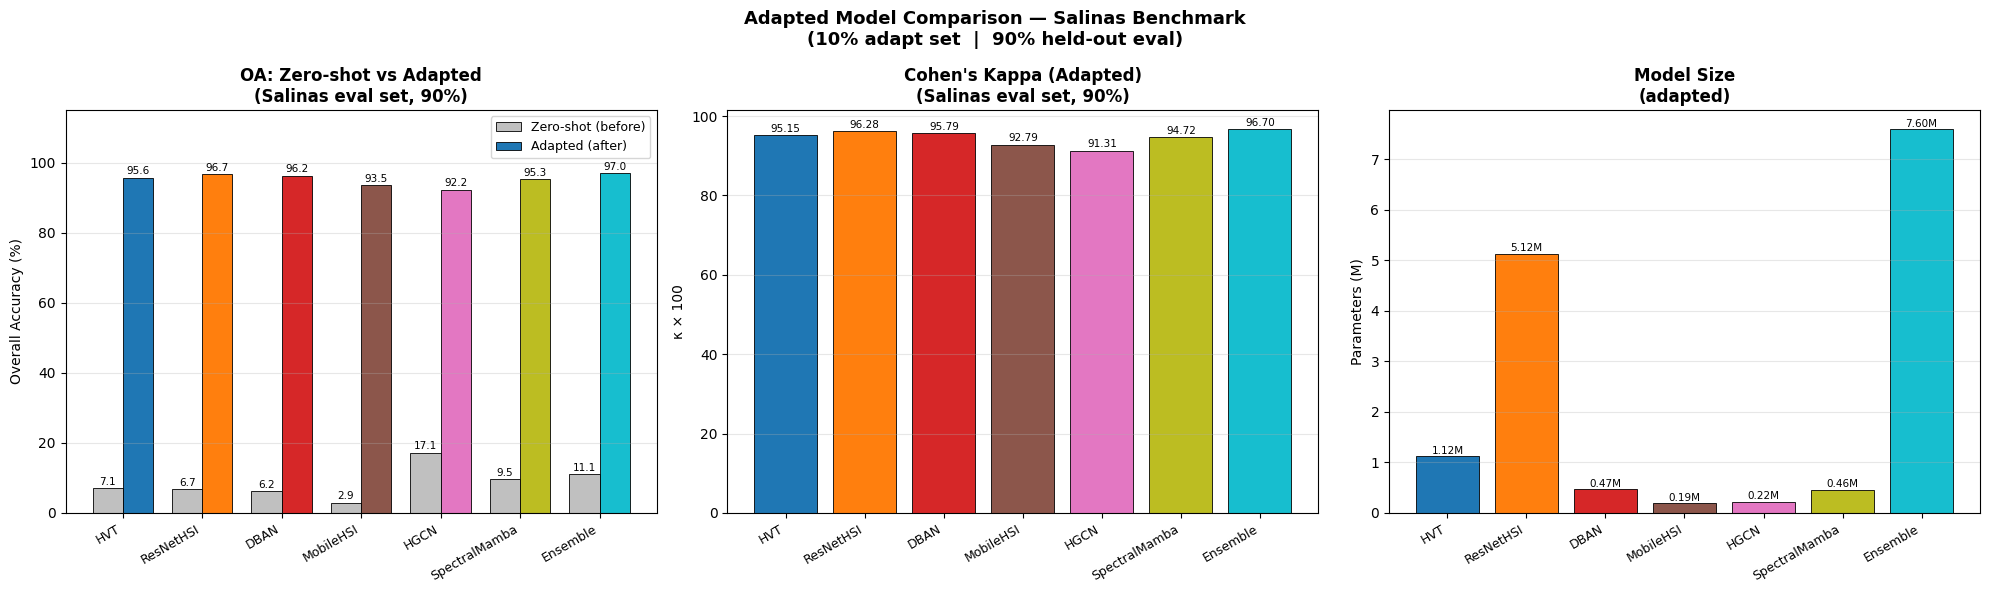

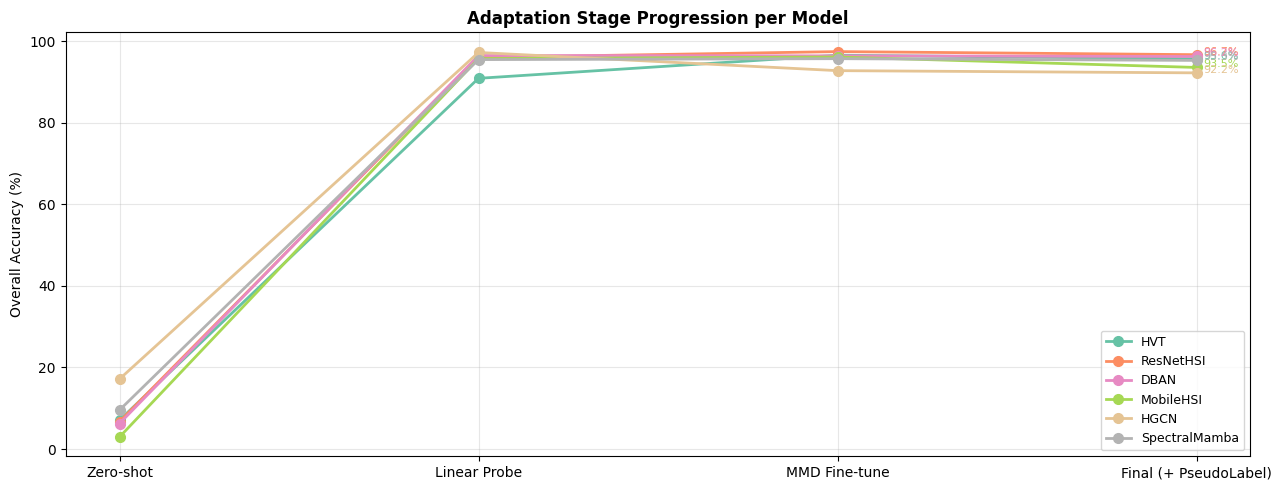

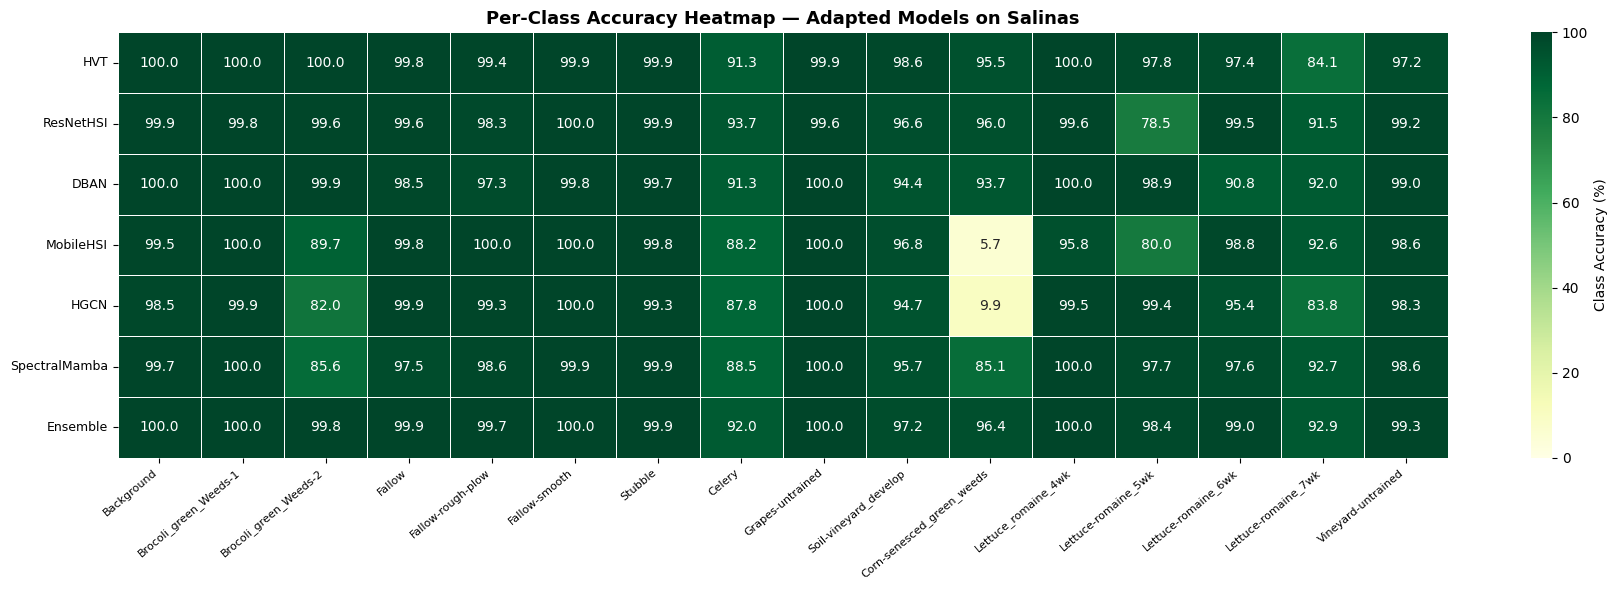

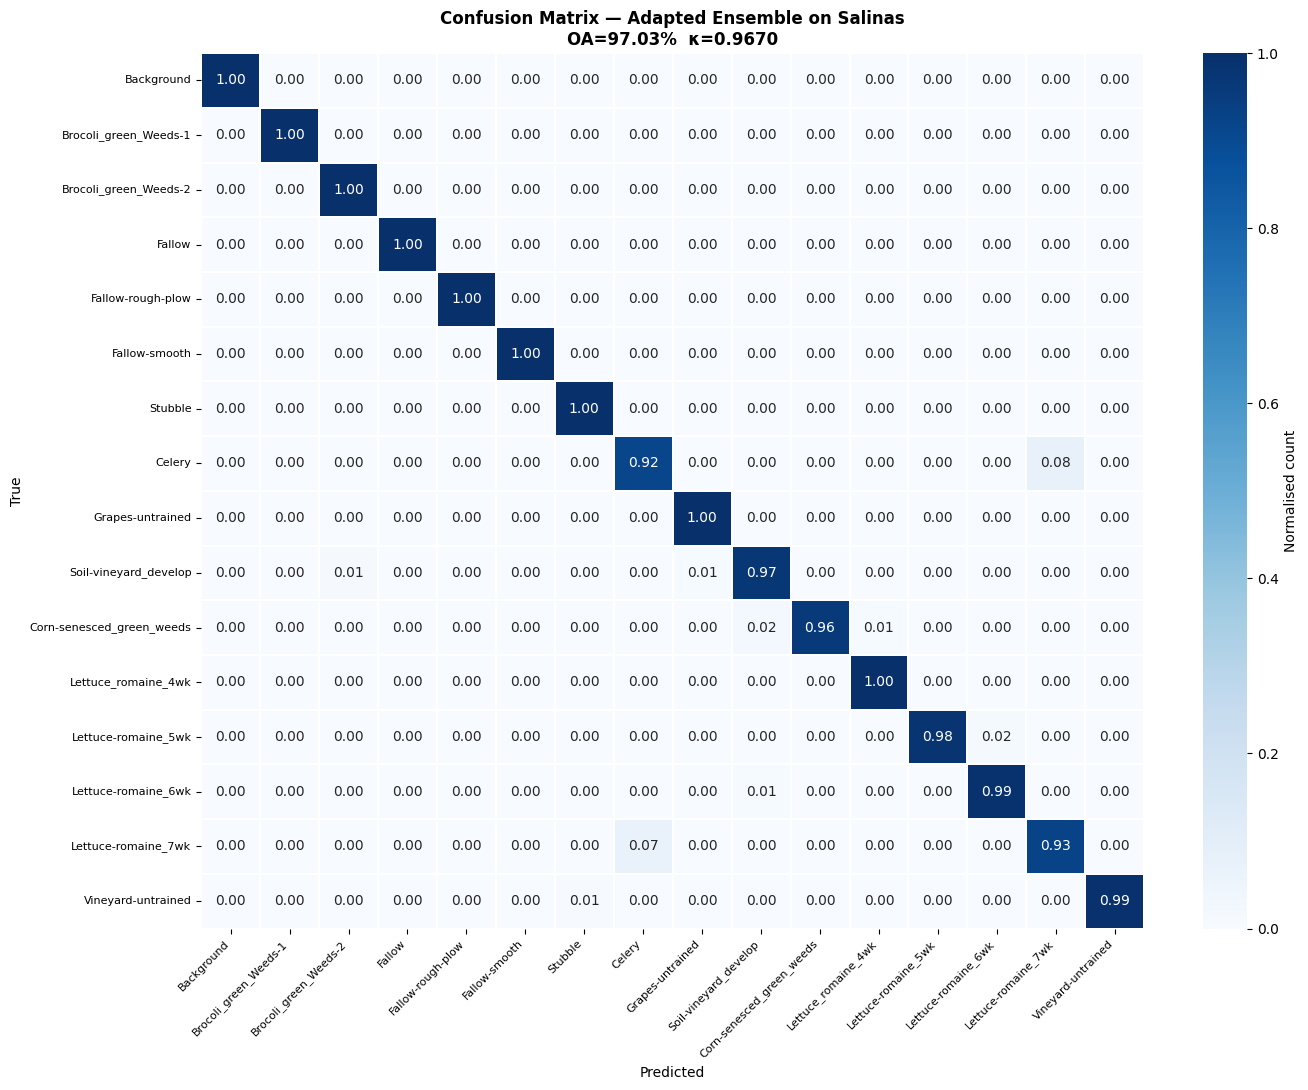

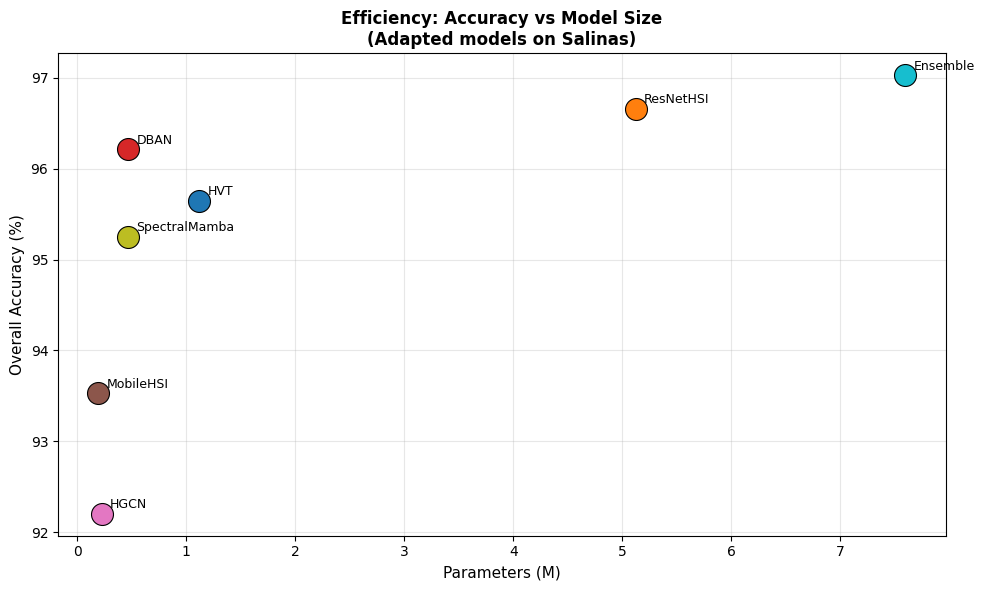


════════════════════════════════════════════════════════════════════════════════
  ADAPTED MODEL COMPARISON — SALINAS (90% held-out eval set)
════════════════════════════════════════════════════════════════════════════════
Model                 Zero-shot       LP      MMD    Final    Kappa     Gain
────────────────────────────────────────────────────────────────────────────────
  HVT                     7.08%   90.86%   96.53%   95.65%   0.9515   +88.6pp ✅
  ResNetHSI               6.73%   95.98%   97.41%   96.66%   0.9628   +89.9pp ✅
  DBAN                    6.25%   96.46%   96.37%   96.21%   0.9579   +90.0pp ✅
  MobileHSI               2.95%   95.70%   96.09%   93.53%   0.9279   +90.6pp ✅
  HGCN                   17.15%   97.20%   92.74%   92.20%   0.9131   +75.1pp ✅
  SpectralMamba           9.55%   95.45%   95.68%   95.25%   0.9472   +85.7pp ✅
────────────────────────────────────────────────────────────────────────────────
  Ensemble               11.06%        —        —   97.03

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 12B – ADAPTED MODEL COMPARISON ON SALINAS (eval set, 90% held-out)
# Mirrors Cells 43–45 but for domain-adapted models on Salinas
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ── CELL A1: Per-model metrics on Salinas eval set ────────────────────────────
print("── Evaluating adapted models on Salinas eval set (90% held-out) ──\n")

adapted_eval_results = {}

for name in MODEL_ZOO:
    mdl = adaptation_results[name]['adapted_model']
    if mdl is None:
        print(f"  {name:20s}  ⚠️  No adapted model — using zero-shot result")
        adapted_eval_results[name] = {
            'preds'  : sal_results[name]['preds'],
            'trues'  : sal_results[name]['trues'],
            'oa'     : sal_results[name]['oa'],
            'kappa'  : sal_results[name]['kappa'],
            'params' : sum(p.numel() for p in MODEL_ZOO[name].parameters()
                           if p.requires_grad),
            'lp_oa'  : adaptation_results[name]['linear_probe_oa'],
            'mmd_oa' : adaptation_results[name]['mmd_oa'],
            'final_oa': adaptation_results[name]['final_oa'],
        }
        continue

    mdl.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in eval_loader:
            out = mdl(xb.to(DEVICE))
            # Handle output size mismatch vs N_SAL
            if out.shape[1] >= N_SAL:
                p = out[:, :N_SAL].argmax(1)
            else:
                reps  = (N_SAL // out.shape[1]) + 1
                p     = out.repeat(1, reps)[:, :N_SAL].argmax(1)
            preds.extend(p.cpu().numpy())
            trues.extend(yb.numpy())

    preds = np.array(preds)
    trues = np.array(trues)
    oa    = accuracy_score(trues, preds)
    kappa = cohen_kappa_score(trues, preds)
    n_params = sum(p.numel() for p in mdl.parameters() if p.requires_grad)

    adapted_eval_results[name] = {
        'preds'   : preds,
        'trues'   : trues,
        'oa'      : oa,
        'kappa'   : kappa,
        'params'  : n_params,
        'lp_oa'   : adaptation_results[name]['linear_probe_oa'],
        'mmd_oa'  : adaptation_results[name]['mmd_oa'],
        'final_oa': adaptation_results[name]['final_oa'],
    }
    print(f"  {name:20s}  OA={oa*100:.2f}%  κ={kappa:.4f}"
          f"  params={n_params:,}")

# Ensemble
adapted_eval_results['Ensemble'] = {
    'preds'   : ada_ens_preds,
    'trues'   : ada_ens_trues,
    'oa'      : ada_ens_oa,
    'kappa'   : ada_ens_kappa,
    'params'  : sum(sum(p.numel() for p in adaptation_results[n]['adapted_model'].parameters()
                        if p.requires_grad)
                    for n in adapted_zoo),
    'lp_oa'   : 0.0,
    'mmd_oa'  : 0.0,
    'final_oa': ada_ens_oa,
}
print(f"  {'Ensemble':20s}  OA={ada_ens_oa*100:.2f}%  κ={ada_ens_kappa:.4f}")


# ── CELL A2: Bar chart comparison (OA / Kappa / Params) ──────────────────────
all_names = list(MODEL_ZOO.keys()) + ['Ensemble']
oas_before = [sal_results[n]['oa'] * 100   for n in MODEL_ZOO] + [sal_ens_oa * 100]
oas_after  = [adapted_eval_results[n]['oa'] * 100 for n in all_names]
kappas     = [adapted_eval_results[n]['kappa'] * 100 for n in all_names]
params_m   = [adapted_eval_results[n]['params'] / 1e6 for n in all_names]

x      = np.arange(len(all_names))
width  = 0.38
colors = plt.cm.tab10(np.linspace(0, 1, len(all_names)))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── OA: Before vs After adaptation ───────────────────────────────────────────
bars_b = axes[0].bar(x - width/2, oas_before, width,
                      label='Zero-shot (before)',
                      color='#c0c0c0', edgecolor='black', linewidth=0.6)
bars_a = axes[0].bar(x + width/2, oas_after, width,
                      label='Adapted (after)',
                      color=colors, edgecolor='black', linewidth=0.6)
for bar, v in zip(list(bars_b) + list(bars_a), oas_before + oas_after):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_names, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Overall Accuracy (%)')
axes[0].set_title('OA: Zero-shot vs Adapted\n(Salinas eval set, 90%)',
                   fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 115)

# ── Kappa ─────────────────────────────────────────────────────────────────────
bars_k = axes[1].bar(all_names, kappas, color=colors,
                      edgecolor='black', linewidth=0.6)
for bar, v in zip(bars_k, kappas):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)
axes[1].set_xticklabels(all_names, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('κ × 100')
axes[1].set_title("Cohen's Kappa (Adapted)\n(Salinas eval set, 90%)",
                   fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# ── Parameters ────────────────────────────────────────────────────────────────
bars_p = axes[2].bar(all_names, params_m, color=colors,
                      edgecolor='black', linewidth=0.6)
for bar, v in zip(bars_p, params_m):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{v:.2f}M', ha='center', va='bottom', fontsize=7.5)
axes[2].set_xticklabels(all_names, rotation=30, ha='right', fontsize=9)
axes[2].set_ylabel('Parameters (M)')
axes[2].set_title('Model Size\n(adapted)',
                   fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Adapted Model Comparison — Salinas Benchmark\n'
             '(10% adapt set  |  90% held-out eval)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('salinas_adapted_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()


# ── CELL A3: Adaptation stage progression (LP → MMD → Final) ─────────────────
fig, ax = plt.subplots(figsize=(13, 5))

stage_names = ['Zero-shot', 'Linear Probe', 'MMD Fine-tune', 'Final (+ PseudoLabel)']
n_models    = len(MODEL_ZOO)
xs          = np.arange(len(stage_names))
colors_prog = plt.cm.Set2(np.linspace(0, 1, n_models))

for i, name in enumerate(MODEL_ZOO):
    r = adaptation_results[name]
    z = sal_results[name]['oa'] * 100
    stages = [z,
              r['linear_probe_oa'] * 100,
              r['mmd_oa'] * 100,
              r['final_oa'] * 100]
    ax.plot(xs, stages, marker='o', linewidth=2,
            label=name, color=colors_prog[i], markersize=7)
    ax.annotate(f"{stages[-1]:.1f}%",
                xy=(xs[-1], stages[-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8, color=colors_prog[i])

ax.set_xticks(xs)
ax.set_xticklabels(stage_names, fontsize=10)
ax.set_ylabel('Overall Accuracy (%)')
ax.set_title('Adaptation Stage Progression per Model',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('salinas_adaptation_progression.png', dpi=150, bbox_inches='tight')
plt.show()


# ── CELL A4: Per-class accuracy heatmap (all adapted models) ─────────────────
per_class_matrix = np.zeros((len(all_names), N_SAL))

for i, name in enumerate(all_names):
    r     = adapted_eval_results[name]
    cm    = confusion_matrix(r['trues'], r['preds'],
                              labels=list(range(N_SAL)))
    pc    = cm.diagonal() / (cm.sum(axis=1) + 1e-8)
    per_class_matrix[i] = pc * 100

sal_class_labels = [SAL_NAMES.get(c, str(c)) for c in range(N_SAL)]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(per_class_matrix,
            xticklabels=sal_class_labels,
            yticklabels=all_names,
            annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.4, linecolor='white',
            vmin=0, vmax=100, ax=ax,
            cbar_kws={'label': 'Class Accuracy (%)'})
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Per-Class Accuracy Heatmap — Adapted Models on Salinas',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('salinas_per_class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


# ── CELL A5: Normalised confusion matrix — Adapted Ensemble ──────────────────
cm_ens = confusion_matrix(ada_ens_trues, ada_ens_preds,
                           labels=list(range(N_SAL)))
cm_ens_n = cm_ens.astype(float) / (cm_ens.sum(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_ens_n, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.3, linecolor='white',
            xticklabels=sal_class_labels,
            yticklabels=sal_class_labels, ax=ax,
            cbar_kws={'label': 'Normalised count'})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.set_xlabel('Predicted', fontsize=10)
ax.set_ylabel('True', fontsize=10)
ax.set_title(f'Confusion Matrix — Adapted Ensemble on Salinas\n'
             f'OA={ada_ens_oa*100:.2f}%  κ={ada_ens_kappa:.4f}',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('salinas_adapted_ensemble_cm.png', dpi=150, bbox_inches='tight')
plt.show()


# ── CELL A6: Efficiency scatter (OA vs Params) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc_colors = plt.cm.tab10(np.linspace(0, 1, len(all_names)))

for i, name in enumerate(all_names):
    oa_val = adapted_eval_results[name]['oa'] * 100
    pm     = adapted_eval_results[name]['params'] / 1e6
    ax.scatter(pm, oa_val, s=250, color=sc_colors[i],
               edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(name, (pm, oa_val),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Parameters (M)', fontsize=11)
ax.set_ylabel('Overall Accuracy (%)', fontsize=11)
ax.set_title('Efficiency: Accuracy vs Model Size\n(Adapted models on Salinas)',
             fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('salinas_efficiency_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


# ── CELL A7: Final summary table ──────────────────────────────────────────────
print("\n" + "═" * 80)
print("  ADAPTED MODEL COMPARISON — SALINAS (90% held-out eval set)")
print("═" * 80)
print(f"{'Model':<20} {'Zero-shot':>10} {'LP':>8} {'MMD':>8}"
      f" {'Final':>8} {'Kappa':>8} {'Gain':>8}")
print("─" * 80)

for name in MODEL_ZOO:
    r      = adaptation_results[name]
    zs     = sal_results[name]['oa'] * 100
    lp     = r['linear_probe_oa'] * 100
    mmd    = r['mmd_oa'] * 100
    final  = adapted_eval_results[name]['oa'] * 100
    kappa  = adapted_eval_results[name]['kappa']
    gain   = final - zs
    flag   = "✅" if gain > 20 else ("⚠️ " if gain > 5 else "❌")
    print(f"  {name:<18} {zs:>9.2f}% {lp:>7.2f}% {mmd:>7.2f}%"
          f" {final:>7.2f}% {kappa:>8.4f} {gain:>+7.1f}pp {flag}")

print("─" * 80)
ens_gain = (ada_ens_oa - sal_ens_oa) * 100
flag_e   = "✅" if ens_gain > 20 else ("⚠️ " if ens_gain > 5 else "❌")
print(f"  {'Ensemble':<18} {sal_ens_oa*100:>9.2f}%"
      f" {'—':>8} {'—':>8}"
      f" {ada_ens_oa*100:>7.2f}% {ada_ens_kappa:>8.4f}"
      f" {ens_gain:>+7.1f}pp {flag_e}")
print("═" * 80)
print(f"\n  Outputs saved:")
print(f"    salinas_adapted_comparison_bars.png")
print(f"    salinas_adaptation_progression.png")
print(f"    salinas_per_class_heatmap.png")
print(f"    salinas_adapted_ensemble_cm.png")
print(f"    salinas_efficiency_scatter.png")
print(f"\n✅  Block 12B — Adapted Salinas Model Comparison complete.")

── Building spatial confidence maps ──

  HVT                   OA=95.72%  mean_conf=0.919  frac>=85%=85.3%
  ResNetHSI             OA=96.71%  mean_conf=0.943  frac>=85%=91.0%
  DBAN                  OA=96.23%  mean_conf=0.924  frac>=85%=86.8%
  MobileHSI             OA=93.52%  mean_conf=0.900  frac>=85%=80.8%
  HGCN                  OA=92.19%  mean_conf=0.854  frac>=85%=64.4%
  SpectralMamba         OA=95.27%  mean_conf=0.904  frac>=85%=81.9%

── Building FULL ensemble confidence map (all labeled pixels) ──

  [Ensemble full] HVT  weight=0.1692
  [Ensemble full] ResNetHSI  weight=0.1728
  [Ensemble full] DBAN  weight=0.1712
  [Ensemble full] MobileHSI  weight=0.1618
  [Ensemble full] HGCN  weight=0.1572
  [Ensemble full] SpectralMamba  weight=0.1678

  Ensemble (full)  OA=97.03%  mean_conf=0.898  frac>=85%=79.1%


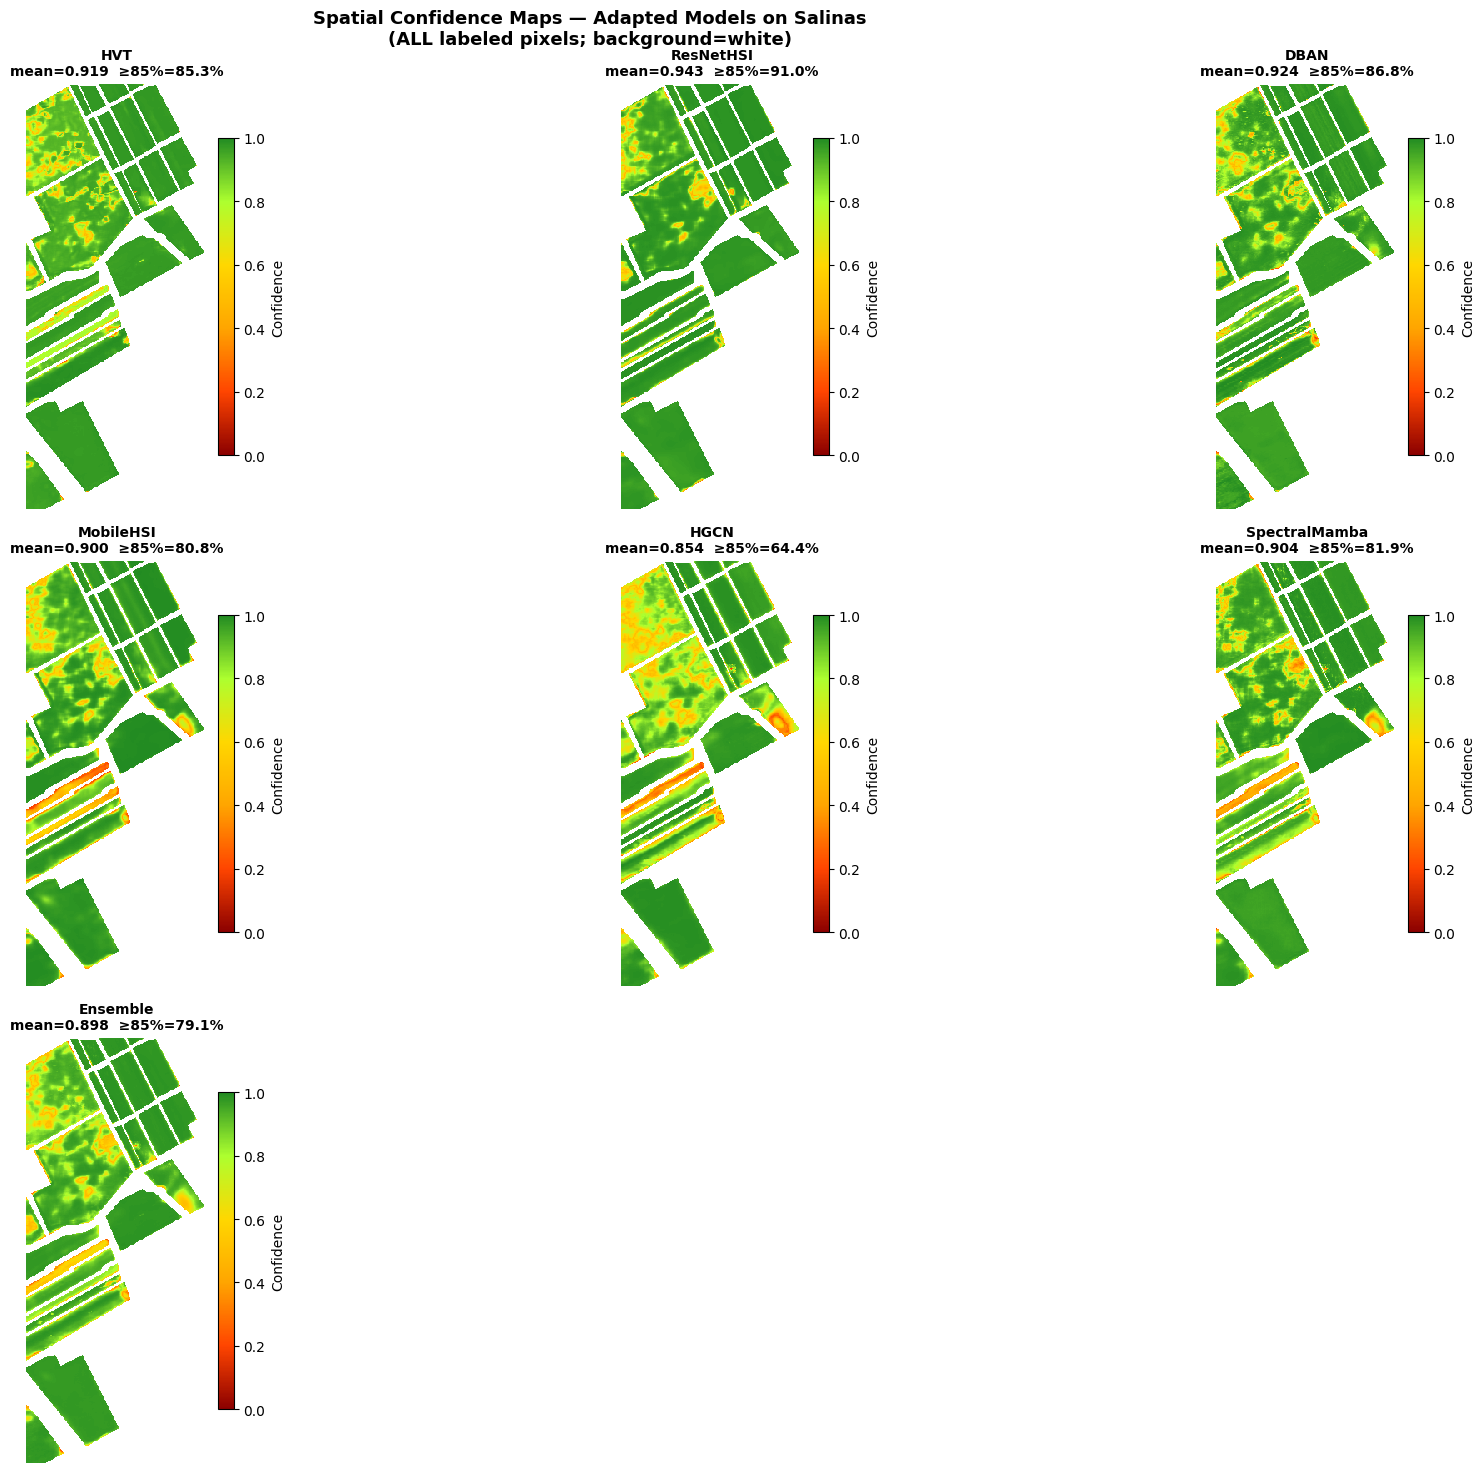

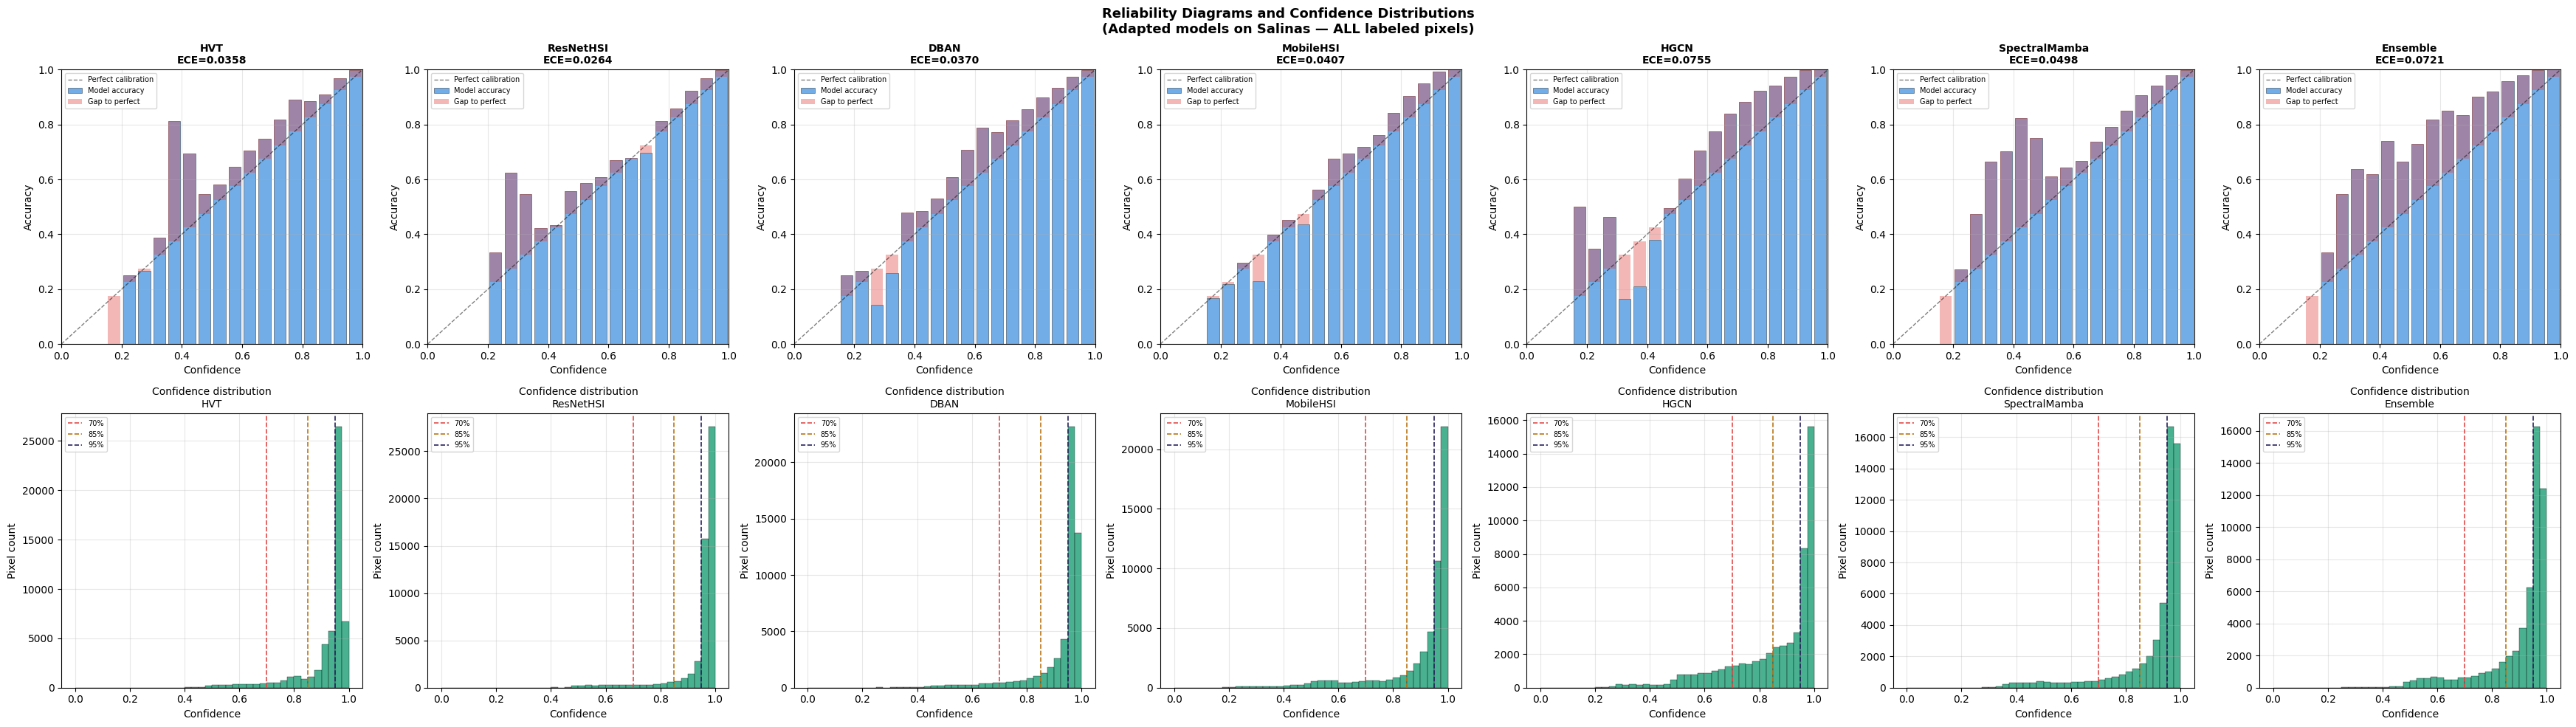

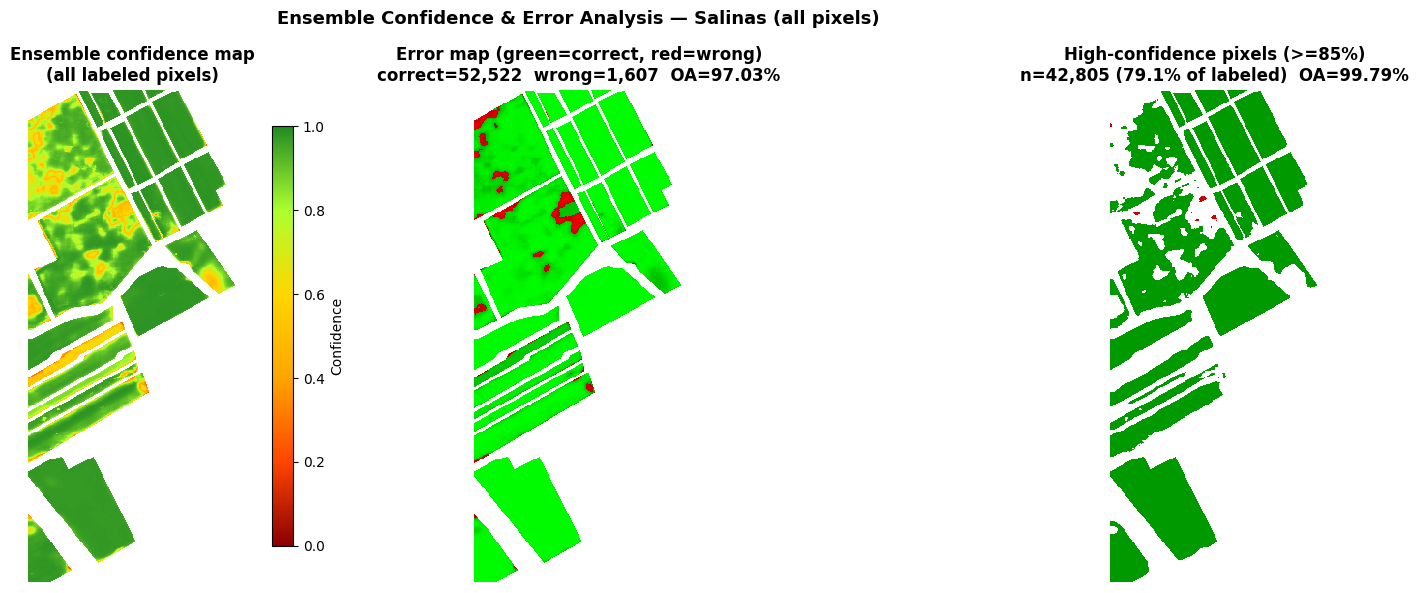

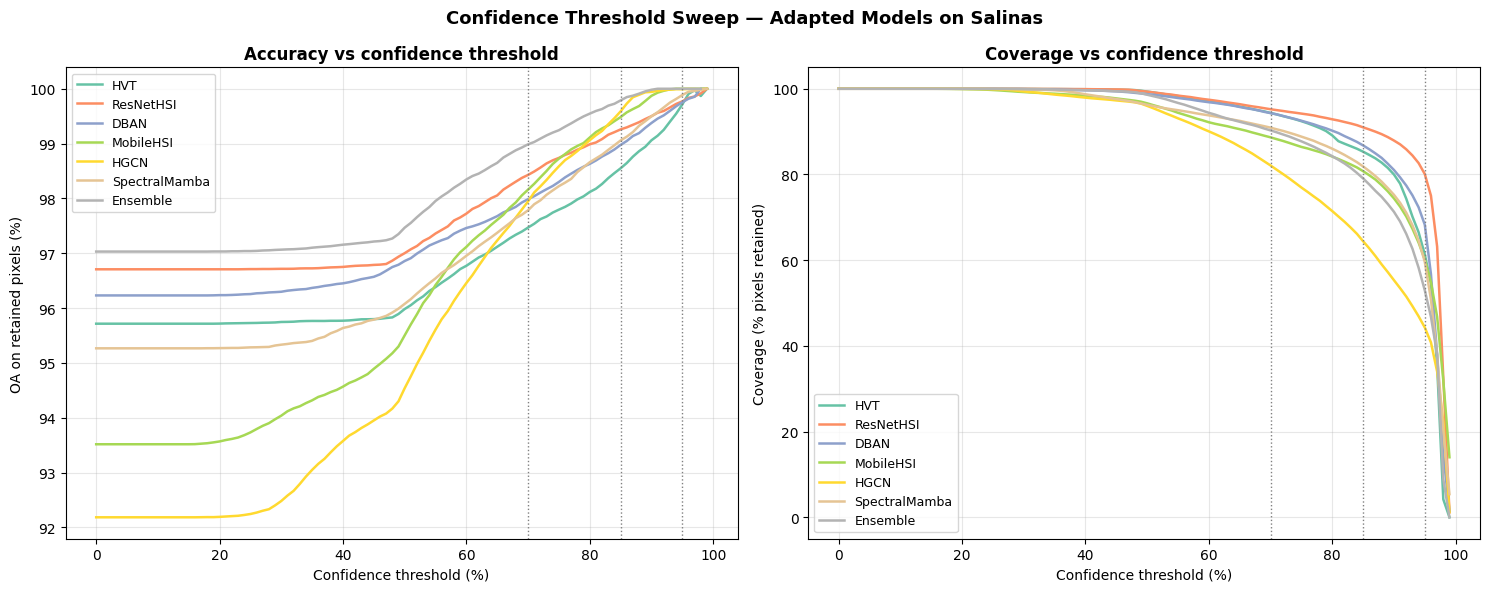

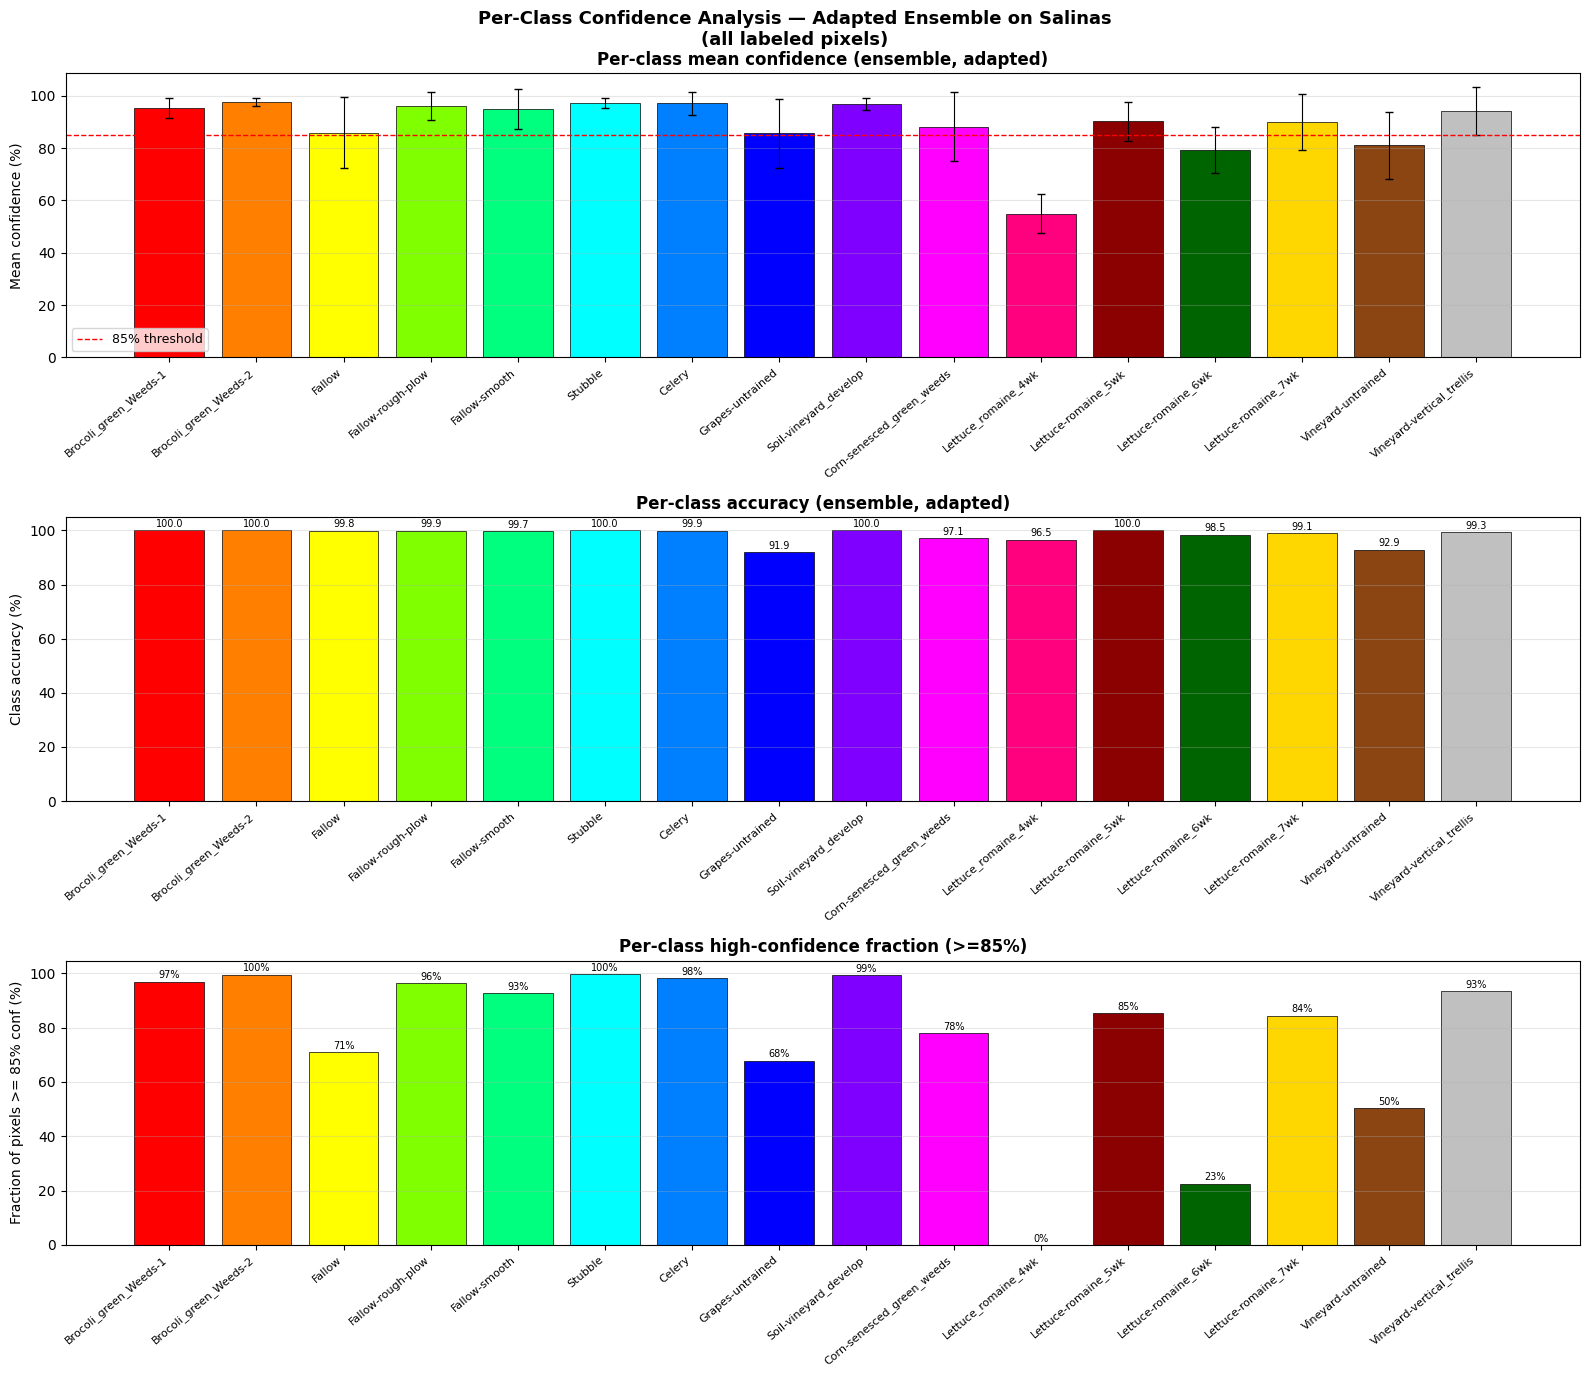

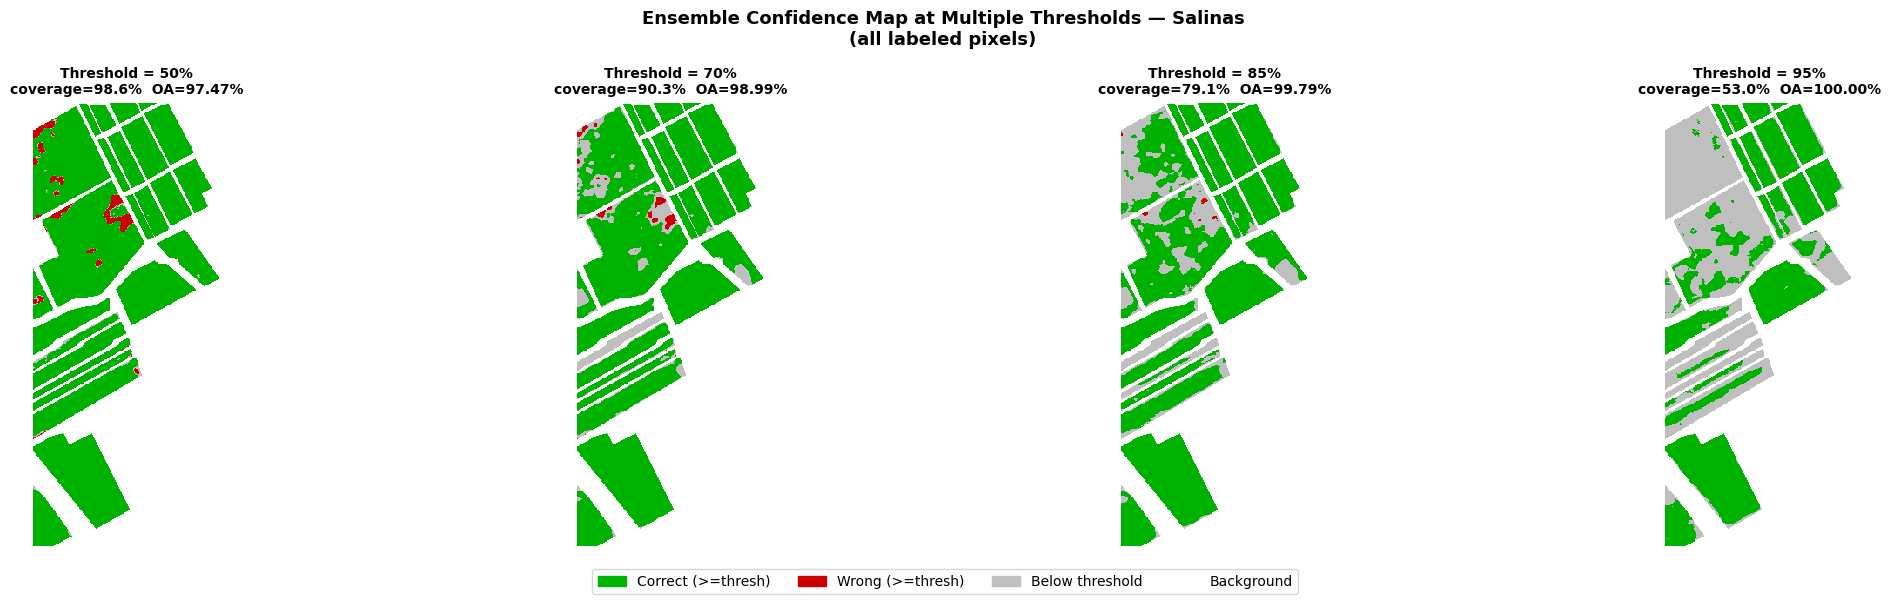


══════════════════════════════════════════════════════════════════════════════════════════
  CONFIDENCE MAP SUMMARY — ADAPTED MODELS ON SALINAS (all labeled pixels)
══════════════════════════════════════════════════════════════════════════════════════════
Model                  OA(all)  OA(>=85%)   MeanConf  Frac>=85%      ECE
──────────────────────────────────────────────────────────────────────────────────────────
  HVT                   95.72%     98.55%      91.9%      85.3%   0.0358
  ResNetHSI             96.71%     99.26%      94.3%      91.0%   0.0264
  DBAN                  96.23%     98.98%      92.4%      86.8%   0.0370
  MobileHSI             93.52%     99.48%      90.0%      80.8%   0.0407
  HGCN                  92.19%     99.59%      85.4%      64.4%   0.0755
  SpectralMamba         95.27%     99.06%      90.4%      81.9%   0.0498
  Ensemble              97.03%     99.79%      89.8%      79.1%   0.0721
════════════════════════════════════════════════════════════════════

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 12C – CONFIDENCE MAP EVALUATION (post-adaptation)
# FIX: Ensemble now re-runs inference over ALL labeled pixels using every
#      adapted model (soft-voted, accuracy-weighted) — not just the 90%
#      eval set subset stored in prob_accum_ada.
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import accuracy_score, cohen_kappa_score

# ── CONFIG ────────────────────────────────────────────────────────────────────
CONF_BINS      = [0.0, 0.50, 0.70, 0.80, 0.85, 0.90, 0.95, 1.01]
CONF_LABELS    = ['<50%', '50-70%', '70-80%', '80-85%',
                  '85-90%', '90-95%', '>=95%']
MAP_THRESHOLDS = [0.50, 0.70, 0.85, 0.95]
SPATIAL_H, SPATIAL_W = sal_labels.shape


# ══════════════════════════════════════════════════════════════════════════════
# UTILITY: per-model spatial maps  (unchanged — correct)
# ══════════════════════════════════════════════════════════════════════════════
def build_spatial_conf_maps(model, sal_data_norm, sal_labels,
                             n_sal, patch_size, device, name=""):
    H, W, B = sal_data_norm.shape
    half    = patch_size // 2
    padded  = np.pad(sal_data_norm, ((half,half),(half,half),(0,0)),
                     mode='reflect')

    conf_map = np.zeros((H, W), dtype=np.float32)
    pred_map = np.zeros((H, W), dtype=np.int32)
    err_map  = np.full((H, W), -1, dtype=np.int8)

    coords = np.argwhere(sal_labels > 0)     # ALL labeled pixels
    batch_patches, batch_rc = [], []

    model.eval()
    with torch.no_grad():
        for i, (r, c) in enumerate(coords):
            patch = padded[r:r+patch_size, c:c+patch_size, :]
            batch_patches.append(patch.transpose(2, 0, 1))
            batch_rc.append((r, c))

            flush = (len(batch_patches) == 256) or (i == len(coords) - 1)
            if not flush:
                continue

            xb    = torch.from_numpy(
                np.array(batch_patches, dtype=np.float32)).to(device)
            out   = model(xb)
            n_out = out.shape[1]
            if n_out >= n_sal:
                logits = out[:, :n_sal]
            else:
                reps   = (n_sal // n_out) + 1
                logits = out.repeat(1, reps)[:, :n_sal]

            probs = torch.softmax(logits, dim=1).cpu().numpy()
            confs = probs.max(axis=1)
            preds = probs.argmax(axis=1) + 1   # 1-based to match sal_labels

            for (rr, cc), conf, pred in zip(batch_rc, confs, preds):
                conf_map[rr, cc] = conf
                pred_map[rr, cc] = int(pred)
                err_map[rr, cc]  = 0 if pred == sal_labels[rr, cc] else 1

            batch_patches, batch_rc = [], []

    if name:
        labeled   = sal_labels > 0
        mean_conf = conf_map[labeled].mean()
        frac_conf = (conf_map[labeled] >= 0.85).mean()
        oa_full   = (pred_map[labeled] == sal_labels[labeled]).mean()
        print(f"  {name:20s}  OA={oa_full*100:.2f}%"
              f"  mean_conf={mean_conf:.3f}"
              f"  frac>=85%={frac_conf:.1%}")

    return conf_map, pred_map, err_map


# ══════════════════════════════════════════════════════════════════════════════
# FIX: Ensemble spatial map — full re-inference over ALL labeled pixels
#      using the latest adapted models with accuracy-squared soft voting.
#      This replaces build_ensemble_spatial_maps which only covered the
#      90% eval-set subset stored in prob_accum_ada.
# ══════════════════════════════════════════════════════════════════════════════
def build_ensemble_spatial_maps_full(adapted_zoo, adaptation_results,
                                      sal_data_norm, sal_labels,
                                      n_sal, patch_size, device):
    """
    Re-runs ALL adapted models over every labeled Salinas pixel and
    accumulates soft-voted probabilities (accuracy² weights) to produce:
      conf_map  (H, W)  – ensemble max-prob confidence
      pred_map  (H, W)  – ensemble argmax prediction (1-based)
      err_map   (H, W)  – 0 correct / 1 wrong / -1 background
    Uses the same per-model spatial inference path as build_spatial_conf_maps
    so conf_map is always consistent with the per-model maps.
    """
    H, W, B = sal_data_norm.shape
    half    = patch_size // 2
    padded  = np.pad(sal_data_norm, ((half,half),(half,half),(0,0)),
                     mode='reflect')
    coords  = np.argwhere(sal_labels > 0)   # ALL labeled pixels
    N_pix   = len(coords)

    # Compute accuracy² weights
    weights = {n: adaptation_results[n]['final_oa'] ** 2
               for n in adapted_zoo}
    total_w = sum(weights.values())

    prob_accum_full = np.zeros((N_pix, n_sal), dtype=np.float64)

    for name, mdl in adapted_zoo.items():
        w = weights[name] / total_w
        print(f"  [Ensemble full] {name}  weight={w:.4f}")

        mdl.eval()
        batch_patches, batch_idx = [], []

        with torch.no_grad():
            for i, (r, c) in enumerate(coords):
                patch = padded[r:r+patch_size, c:c+patch_size, :]
                batch_patches.append(patch.transpose(2, 0, 1))
                batch_idx.append(i)

                flush = (len(batch_patches) == 256) or (i == N_pix - 1)
                if not flush:
                    continue

                xb    = torch.from_numpy(
                    np.array(batch_patches, dtype=np.float32)).to(device)
                out   = mdl(xb)
                n_out = out.shape[1]
                if n_out >= n_sal:
                    logits = out[:, :n_sal]
                else:
                    reps   = (n_sal // n_out) + 1
                    logits = out.repeat(1, reps)[:, :n_sal]

                probs = torch.softmax(logits, dim=1).cpu().numpy()  # (bs, n_sal)
                for bi, pix_idx in enumerate(batch_idx):
                    prob_accum_full[pix_idx] += probs[bi] * w

                batch_patches, batch_idx = [], []

    # Build spatial arrays
    conf_map = np.zeros((H, W), dtype=np.float32)
    pred_map = np.zeros((H, W), dtype=np.int32)
    err_map  = np.full((H, W), -1, dtype=np.int8)

    ens_confs = prob_accum_full.max(axis=1)
    ens_preds = prob_accum_full.argmax(axis=1) + 1   # 1-based

    for i, (r, c) in enumerate(coords):
        conf_map[r, c] = float(ens_confs[i])
        pred_map[r, c] = int(ens_preds[i])
        err_map[r, c]  = 0 if ens_preds[i] == sal_labels[r, c] else 1

    labeled = sal_labels > 0
    oa      = (pred_map[labeled] == sal_labels[labeled]).mean()
    mc      = conf_map[labeled].mean()
    frac    = (conf_map[labeled] >= 0.85).mean()
    print(f"\n  Ensemble (full)  OA={oa*100:.2f}%"
          f"  mean_conf={mc:.3f}  frac>=85%={frac:.1%}")

    return conf_map, pred_map, err_map, prob_accum_full


# ══════════════════════════════════════════════════════════════════════════════
# CELL C1: Build spatial maps for every adapted model + full ensemble
# ══════════════════════════════════════════════════════════════════════════════
print("── Building spatial confidence maps ──\n")

spatial_maps = {}

for name in MODEL_ZOO:
    mdl = adaptation_results[name]['adapted_model']
    if mdl is None:
        print(f"  {name:20s}  skipped (no adapted model)")
        continue
    conf_map, pred_map, err_map = build_spatial_conf_maps(
        mdl, sal_data_norm, sal_labels,
        N_SAL, PATCH_SIZE, DEVICE, name=name)
    spatial_maps[name] = {
        'conf': conf_map, 'pred': pred_map, 'err': err_map}

# ── Full ensemble re-inference ────────────────────────────────────────────────
print("\n── Building FULL ensemble confidence map (all labeled pixels) ──\n")
ens_conf, ens_pred, ens_err, ens_prob_full = build_ensemble_spatial_maps_full(
    adapted_zoo, adaptation_results,
    sal_data_norm, sal_labels,
    N_SAL, PATCH_SIZE, DEVICE)

spatial_maps['Ensemble'] = {
    'conf': ens_conf, 'pred': ens_pred, 'err': ens_err}

labeled_mask = sal_labels > 0


# ══════════════════════════════════════════════════════════════════════════════
# CELL C2: Confidence map grid (one per model)
# ══════════════════════════════════════════════════════════════════════════════
all_map_names = [n for n in list(MODEL_ZOO.keys()) + ['Ensemble']
                 if n in spatial_maps]
n_models = len(all_map_names)
ncols    = min(3, n_models)
nrows    = (n_models + ncols - 1) // ncols

conf_cmap = mcolors.LinearSegmentedColormap.from_list(
    'conf', ['#8B0000', '#FF4500', '#FFA500', '#FFD700', '#ADFF2F', '#228B22'])

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

for i, name in enumerate(all_map_names):
    ax   = axes[i]
    cmap = spatial_maps[name]['conf']
    mask = labeled_mask

    display = np.full(cmap.shape, np.nan)
    display[mask] = cmap[mask]

    im = ax.imshow(display, cmap=conf_cmap, vmin=0, vmax=1,
                   interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Confidence')

    mc   = cmap[mask].mean()
    frac = (cmap[mask] >= 0.85).mean()
    ax.set_title(f'{name}\nmean={mc:.3f}  ≥85%={frac:.1%}',
                 fontsize=10, fontweight='bold')
    ax.axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Spatial Confidence Maps — Adapted Models on Salinas\n'
             '(ALL labeled pixels; background=white)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('salinas_confidence_maps.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL C3: Reliability diagrams + confidence histograms
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 10))
if n_models == 1:
    axes = axes.reshape(2, 1)

for i, name in enumerate(all_map_names):
    cmap  = spatial_maps[name]['conf']
    pmap  = spatial_maps[name]['pred']
    mask  = labeled_mask

    confs   = cmap[mask]
    preds   = pmap[mask]
    trues   = sal_labels[mask]
    correct = (preds == trues).astype(float)

    bin_edges = np.linspace(0, 1, 21)
    bin_mids  = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_acc, bin_cnt = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        sel = (confs >= lo) & (confs < hi)
        bin_acc.append(correct[sel].mean() if sel.sum() > 0 else np.nan)
        bin_cnt.append(int(sel.sum()))

    bin_acc = np.array(bin_acc)
    bin_cnt = np.array(bin_cnt)

    ax_rel = axes[0, i]
    ax_rel.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5,
                label='Perfect calibration')
    valid = ~np.isnan(bin_acc)
    ax_rel.bar(bin_mids[valid], bin_acc[valid], width=0.04,
               color='#378ADD', alpha=0.7, edgecolor='black',
               linewidth=0.4, label='Model accuracy')
    ax_rel.bar(bin_mids[valid],
               bin_mids[valid] - bin_acc[valid],
               bottom=bin_acc[valid], width=0.04,
               color='#E24B4A', alpha=0.4, label='Gap to perfect')

    ece = np.nansum(np.abs(bin_mids - bin_acc) * bin_cnt) / bin_cnt.sum()
    ax_rel.set_title(f'{name}\nECE={ece:.4f}', fontsize=10, fontweight='bold')
    ax_rel.set_xlabel('Confidence'); ax_rel.set_ylabel('Accuracy')
    ax_rel.set_xlim(0, 1); ax_rel.set_ylim(0, 1)
    ax_rel.legend(fontsize=7); ax_rel.grid(alpha=0.3)

    ax_hist = axes[1, i]
    ax_hist.hist(confs, bins=40, range=(0, 1),
                 color='#1D9E75', edgecolor='black', linewidth=0.3, alpha=0.8)
    for thresh, col in zip([0.70, 0.85, 0.95],
                            ['#E24B4A', '#BA7517', '#26215C']):
        ax_hist.axvline(thresh, color=col, linestyle='--',
                        linewidth=1.2, label=f'{thresh:.0%}')
    ax_hist.set_xlabel('Confidence'); ax_hist.set_ylabel('Pixel count')
    ax_hist.set_title(f'Confidence distribution\n{name}', fontsize=10)
    ax_hist.legend(fontsize=7); ax_hist.grid(alpha=0.3)

plt.suptitle('Reliability Diagrams and Confidence Distributions\n'
             '(Adapted models on Salinas — ALL labeled pixels)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('salinas_reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL C4: Error map overlaid on confidence map (ensemble)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

display_conf = np.full(sal_labels.shape, np.nan)
display_conf[labeled_mask] = ens_conf[labeled_mask]
im0 = axes[0].imshow(display_conf, cmap=conf_cmap, vmin=0, vmax=1,
                      interpolation='nearest')
plt.colorbar(im0, ax=axes[0], fraction=0.03, label='Confidence')
axes[0].set_title('Ensemble confidence map\n(all labeled pixels)',
                   fontweight='bold')
axes[0].axis('off')

# Build error display using vectorised indexing (avoids slow pixel loop)
err_display = np.ones((*sal_labels.shape, 3), dtype=np.float32)
correct_m   = (ens_err == 0)
wrong_m     = (ens_err == 1)

conf_norm = ens_conf.clip(0, 1)
# Green channel: correct pixels, intensity ∝ confidence
err_display[correct_m, 0] = 0.0
err_display[correct_m, 1] = 0.5 + 0.5 * conf_norm[correct_m]
err_display[correct_m, 2] = 0.0
# Red channel: wrong pixels, intensity ∝ confidence
err_display[wrong_m,   0] = 0.5 + 0.5 * conf_norm[wrong_m]
err_display[wrong_m,   1] = 0.0
err_display[wrong_m,   2] = 0.0

axes[1].imshow(err_display.clip(0, 1), interpolation='nearest')
n_correct = int(correct_m.sum()); n_wrong = int(wrong_m.sum())
axes[1].set_title(
    f'Error map (green=correct, red=wrong)\n'
    f'correct={n_correct:,}  wrong={n_wrong:,}'
    f'  OA={n_correct/(n_correct+n_wrong)*100:.2f}%',
    fontweight='bold')
axes[1].axis('off')

hc_mask    = (ens_conf >= 0.85) & labeled_mask
hc_correct = correct_m & hc_mask
hc_wrong   = wrong_m   & hc_mask

hc_display = np.ones((*sal_labels.shape, 3), dtype=np.float32)
hc_display[hc_correct] = [0.0, 0.6, 0.0]
hc_display[hc_wrong]   = [0.8, 0.0, 0.0]

n_hc = int(hc_mask.sum()); n_hc_c = int(hc_correct.sum())
oa_hc = n_hc_c / n_hc if n_hc > 0 else 0

axes[2].imshow(hc_display, interpolation='nearest')
axes[2].set_title(
    f'High-confidence pixels (>=85%)\n'
    f'n={n_hc:,} ({n_hc/labeled_mask.sum():.1%} of labeled)'
    f'  OA={oa_hc*100:.2f}%',
    fontweight='bold')
axes[2].axis('off')

plt.suptitle('Ensemble Confidence & Error Analysis — Salinas (all pixels)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('salinas_ensemble_error_conf_map.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL C5: Threshold sweep
# ══════════════════════════════════════════════════════════════════════════════
thresholds  = np.linspace(0.0, 0.99, 100)
colors_prog = plt.cm.Set2(np.linspace(0, 1, len(all_map_names)))

fig, (ax_oa, ax_cov) = plt.subplots(1, 2, figsize=(15, 6))

for i, name in enumerate(all_map_names):
    confs   = spatial_maps[name]['conf'][labeled_mask]
    preds   = spatial_maps[name]['pred'][labeled_mask]
    trues   = sal_labels[labeled_mask]
    correct = (preds == trues).astype(float)

    oas, covs = [], []
    for t in thresholds:
        sel = confs >= t
        cov = sel.mean()
        oa  = correct[sel].mean() if sel.sum() > 0 else np.nan
        oas.append(oa * 100 if not np.isnan(oa) else np.nan)
        covs.append(cov * 100)

    ax_oa.plot(thresholds * 100, oas,
               label=name, color=colors_prog[i], linewidth=1.8)
    ax_cov.plot(thresholds * 100, covs,
                label=name, color=colors_prog[i], linewidth=1.8)

for thresh in [70, 85, 95]:
    ax_oa.axvline(thresh, color='gray', linestyle=':', linewidth=1)
    ax_cov.axvline(thresh, color='gray', linestyle=':', linewidth=1)

ax_oa.set_xlabel('Confidence threshold (%)')
ax_oa.set_ylabel('OA on retained pixels (%)')
ax_oa.set_title('Accuracy vs confidence threshold', fontweight='bold')
ax_oa.legend(fontsize=9); ax_oa.grid(alpha=0.3)

ax_cov.set_xlabel('Confidence threshold (%)')
ax_cov.set_ylabel('Coverage (% pixels retained)')
ax_cov.set_title('Coverage vs confidence threshold', fontweight='bold')
ax_cov.legend(fontsize=9); ax_cov.grid(alpha=0.3)

plt.suptitle('Confidence Threshold Sweep — Adapted Models on Salinas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('salinas_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL C6: Per-class confidence analysis (ensemble)
# ══════════════════════════════════════════════════════════════════════════════
class_conf_means = np.zeros(N_SAL)
class_conf_stds  = np.zeros(N_SAL)
class_acc        = np.zeros(N_SAL)
class_frac_hc    = np.zeros(N_SAL)

for cls in range(N_SAL):
    cls_mask = (sal_labels == cls + 1) & labeled_mask
    if cls_mask.sum() == 0:
        continue
    c = ens_conf[cls_mask]
    p = ens_pred[cls_mask]
    t = sal_labels[cls_mask]
    class_conf_means[cls] = c.mean()
    class_conf_stds[cls]  = c.std()
    class_acc[cls]        = (p == t).mean()
    class_frac_hc[cls]    = (c >= 0.85).mean()

sal_class_labels = [SAL_NAMES.get(c, str(c)) for c in range(1, N_SAL + 1)]
x = np.arange(N_SAL)

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
colors_cls = [SAL_COLORS[i + 1] if i + 1 < len(SAL_COLORS) else '#AAA'
              for i in range(N_SAL)]

axes[0].bar(x, class_conf_means * 100, color=colors_cls,
            edgecolor='black', linewidth=0.5)
axes[0].errorbar(x, class_conf_means * 100, yerr=class_conf_stds * 100,
                  fmt='none', ecolor='black', capsize=3, linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(sal_class_labels, rotation=40, ha='right', fontsize=8)
axes[0].set_ylabel('Mean confidence (%)')
axes[0].set_title('Per-class mean confidence (ensemble, adapted)',
                   fontweight='bold')
axes[0].axhline(85, color='red', linestyle='--', linewidth=1,
                label='85% threshold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

bars1 = axes[1].bar(x, class_acc * 100, color=colors_cls,
                     edgecolor='black', linewidth=0.5)
for bar, v in zip(bars1, class_acc * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(sal_class_labels, rotation=40, ha='right', fontsize=8)
axes[1].set_ylabel('Class accuracy (%)')
axes[1].set_title('Per-class accuracy (ensemble, adapted)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

bars2 = axes[2].bar(x, class_frac_hc * 100, color=colors_cls,
                     edgecolor='black', linewidth=0.5)
for bar, v in zip(bars2, class_frac_hc * 100):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{v:.0f}%', ha='center', va='bottom', fontsize=7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(sal_class_labels, rotation=40, ha='right', fontsize=8)
axes[2].set_ylabel('Fraction of pixels >= 85% conf (%)')
axes[2].set_title('Per-class high-confidence fraction (>=85%)',
                   fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Per-Class Confidence Analysis — Adapted Ensemble on Salinas\n'
             '(all labeled pixels)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('salinas_per_class_confidence.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL C7: Spatial maps at multiple thresholds (ensemble)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(MAP_THRESHOLDS),
                          figsize=(6 * len(MAP_THRESHOLDS), 6))

for i, thresh in enumerate(MAP_THRESHOLDS):
    ax    = axes[i]
    above = ens_conf >= thresh
    below = (~above) & labeled_mask

    rgb = np.ones((*sal_labels.shape, 3), dtype=np.float32)
    rgb[above & (ens_err == 0)] = [0.0, 0.7, 0.0]
    rgb[above & (ens_err == 1)] = [0.8, 0.0, 0.0]
    rgb[below]                  = [0.75, 0.75, 0.75]

    n_above   = int((above & labeled_mask).sum())
    n_correct = int((above & (ens_err == 0)).sum())
    oa_t      = n_correct / n_above if n_above > 0 else 0
    cov_t     = n_above / labeled_mask.sum()

    ax.imshow(rgb, interpolation='nearest')
    ax.set_title(f'Threshold = {thresh:.0%}\n'
                 f'coverage={cov_t:.1%}  OA={oa_t*100:.2f}%',
                 fontweight='bold', fontsize=10)
    ax.axis('off')

legend_patches = [
    mpatches.Patch(color=[0.0, 0.7, 0.0], label='Correct (>=thresh)'),
    mpatches.Patch(color=[0.8, 0.0, 0.0], label='Wrong (>=thresh)'),
    mpatches.Patch(color=[0.75, 0.75, 0.75], label='Below threshold'),
    mpatches.Patch(color=[1.0, 1.0, 1.0], label='Background'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=10, framealpha=0.8)
plt.suptitle('Ensemble Confidence Map at Multiple Thresholds — Salinas\n'
             '(all labeled pixels)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('salinas_threshold_conf_maps.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL C8: ECE + summary table
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 90)
print("  CONFIDENCE MAP SUMMARY — ADAPTED MODELS ON SALINAS (all labeled pixels)")
print("═" * 90)
print(f"{'Model':<20} {'OA(all)':>9} {'OA(>=85%)':>10} {'MeanConf':>10}"
      f" {'Frac>=85%':>10} {'ECE':>8}")
print("─" * 90)

for name in all_map_names:
    confs   = spatial_maps[name]['conf'][labeled_mask]
    preds   = spatial_maps[name]['pred'][labeled_mask]
    trues   = sal_labels[labeled_mask]
    correct = (preds == trues)

    oa_all = correct.mean() * 100
    hc_sel = confs >= 0.85
    oa_hc  = correct[hc_sel].mean() * 100 if hc_sel.sum() > 0 else 0
    mc     = confs.mean() * 100
    frac   = hc_sel.mean() * 100

    bin_edges = np.linspace(0, 1, 21)
    bin_mids  = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    ece = 0.0
    for lo, hi, mid in zip(bin_edges[:-1], bin_edges[1:], bin_mids):
        sel = (confs >= lo) & (confs < hi)
        if sel.sum() > 0:
            ece += np.abs(mid - correct[sel].mean()) * sel.sum()
    ece /= len(confs)

    print(f"  {name:<18} {oa_all:>8.2f}% {oa_hc:>9.2f}% {mc:>9.1f}%"
          f" {frac:>9.1f}% {ece:>8.4f}")

print("═" * 90)
print(f"\n  Outputs saved:")
for f in ['salinas_confidence_maps.png',
          'salinas_reliability_diagrams.png',
          'salinas_ensemble_error_conf_map.png',
          'salinas_threshold_sweep.png',
          'salinas_per_class_confidence.png',
          'salinas_threshold_conf_maps.png']:
    print(f"    {f}")
print("\n✅  Block 12C — Confidence Map Evaluation complete.")